In [1]:
import os
import platform
import subprocess
import sys
from pathlib import Path

# Ensure this notebook can be selected as a Jupyter kernel.
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "ipykernel"])

PROJECT_DIR = Path("/home/naba/projects")
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def run_command(command: str) -> str:
    """Run a basic Linux shell command and return its output."""
    completed = subprocess.run(
        command,
        shell=True,
        check=True,
        cwd=PROJECT_DIR,
        capture_output=True,
        text=True,
    )
    return completed.stdout.strip()


print(f"Python: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")
print(f"Working directory: {os.getcwd()}")
print(run_command("pwd"))
print(run_command("ls -la"))

Python: 3.10.12
Platform: Linux-6.18.33.2-microsoft-standard-WSL2-x86_64-with-glibc2.35
Working directory: /home/naba/projects
/home/naba/projects
total 20
drwxr-xr-x  4 naba naba 4096 Aug 23 23:25 .
drwxr-x--- 23 naba naba 4096 Aug 23 23:23 ..
drwxr-xr-x  6 naba naba 4096 Aug 23 23:22 .venv
-rw-r--r--  1 naba naba 1544 Aug 23 23:17 MD-analysis.ipynb
drwxr-xr-x  2 naba naba 4096 Aug 23 23:25 results


In [2]:
!pip install openrouter 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 925.7/925.7 kB 7.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 3.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12/12 [openrouter]2 [openrouter]


In [1]:
!pip -q install openrouter pydantic requests pandas transformers torch

In [3]:
!pip install pandas numpy matplotlib scipy openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 5.5 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 3.3 MB/s  0:00:11m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 3.4 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 4.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 3.9 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [matplotlib]0 [matplotlib]


In [2]:
pip install streamlit pandas numpy openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 4.7 MB/s  0:00:02m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.6/797.6 kB 4.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 3.2 MB/s  0:00:15m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 3.9 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20/20 [streamlit]20 [streamlit]]
Note: you may need to restart the kernel to use updated packages.


In [9]:
pwd

'/home/naba/projects'

This is a trial for RMSD block average analysis from four 300 ns simulations:
1. XRCC1WT-LigIIIα
2. XRCC1WT-Polβ
3. XRCC1R194W-LigIIIα
4. XRCC1R194W-Polβ

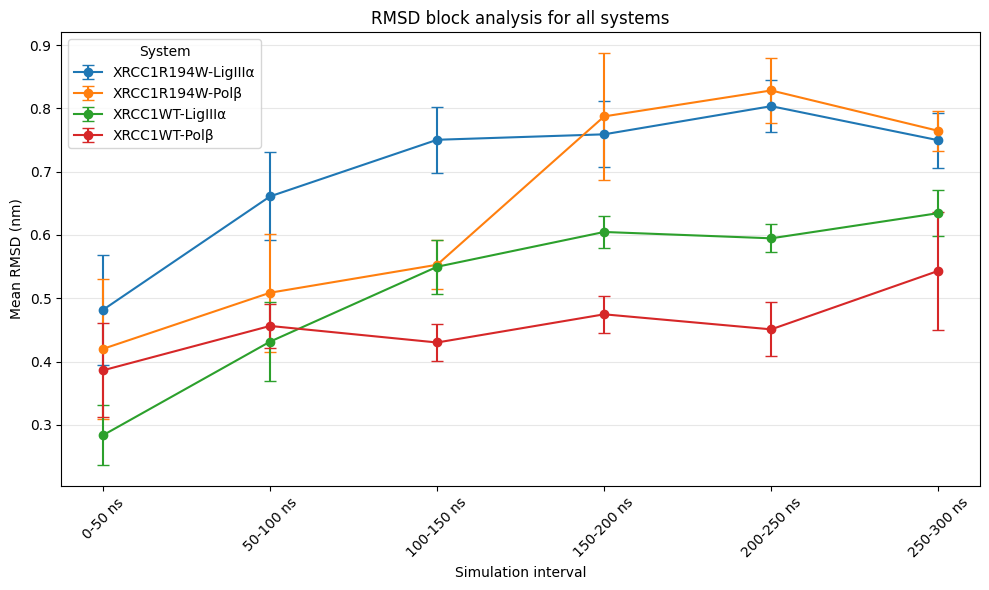

Saved: /home/naba/projects/results/all_systems_RMSD_block_analysis.png


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

PROJECT_DIR = Path("/home/naba/projects")
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Load the block statistics if the analysis cell has not already created results_df.
if "results_df" not in globals():
    result_files = sorted(PROJECT_DIR.glob("RMSD*_block_statistics.xlsx"))
    if not result_files:
        raise FileNotFoundError(
            "No block-statistics Excel file found. Run block_analysis.py first."
        )
    results_df = pd.read_excel(result_files[0])

block_order = [
    "0-50 ns",
    "50-100 ns",
    "100-150 ns",
    "150-200 ns",
    "200-250 ns",
    "250-300 ns",
]

results_df = results_df.copy()
results_df["Block"] = pd.Categorical(
    results_df["Block"],
    categories=block_order,
    ordered=True,
)

systems = results_df["System"].dropna().unique()
block_positions = range(len(block_order))

plt.figure(figsize=(10, 6))

for system in systems:
    temp = results_df[results_df["System"] == system].sort_values("Block")
    plt.errorbar(
        block_positions,
        temp["Mean"],
        yerr=temp["SD"],
        marker="o",
        capsize=4,
        linewidth=1.5,
        label=str(system),
    )

plt.xlabel("Simulation interval")
plt.ylabel("Mean RMSD (nm)")
plt.title("RMSD block analysis for all systems")
plt.xticks(list(block_positions), block_order, rotation=45)
plt.legend(title="System")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

output_path = RESULTS_DIR / "all_systems_RMSD_block_analysis.png"
plt.savefig(output_path, dpi=600, bbox_inches="tight")
plt.show()
plt.close()

print(f"Saved: {output_path}")

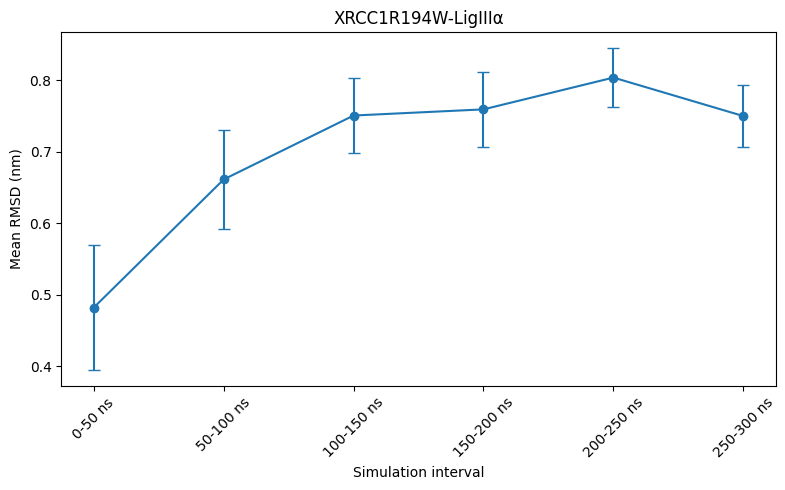

Saved: /home/naba/projects/results/XRCC1R194W-LigIII_RMSD_block_analysis.png


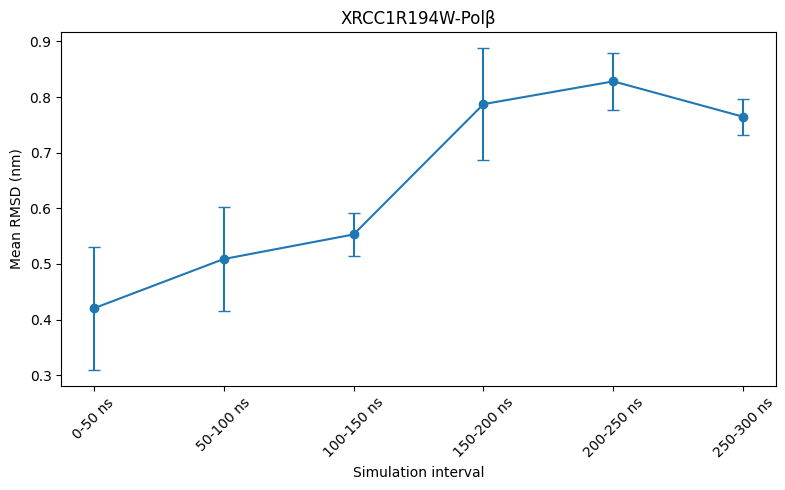

Saved: /home/naba/projects/results/XRCC1R194W-Pol_RMSD_block_analysis.png


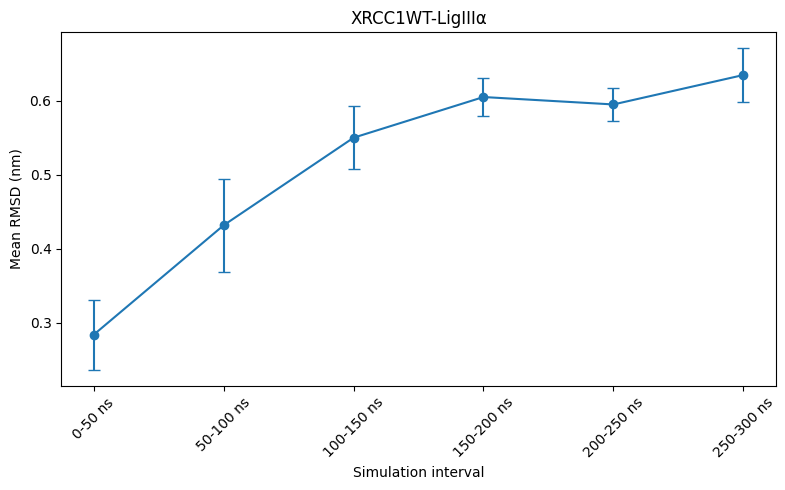

Saved: /home/naba/projects/results/XRCC1WT-LigIII_RMSD_block_analysis.png


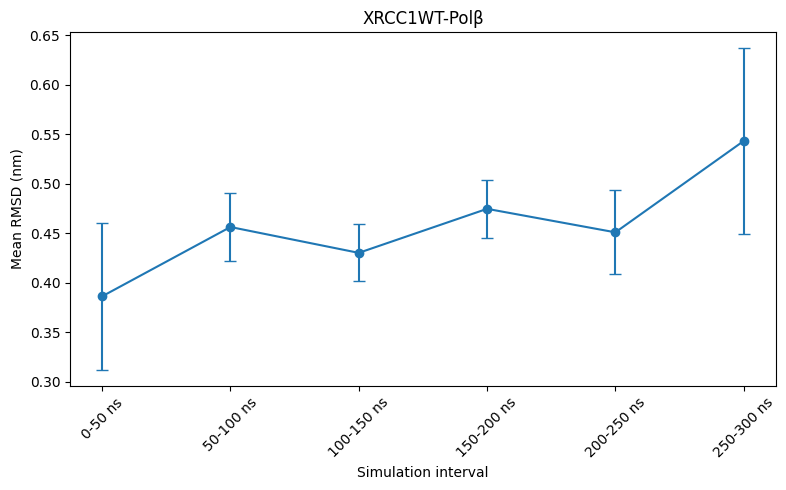

Saved: /home/naba/projects/results/XRCC1WT-Pol_RMSD_block_analysis.png


In [10]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_DIR = Path("/home/naba/projects")
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Use results_df if the analysis was run in this notebook; otherwise load its Excel output.
if "results_df" not in globals():
    result_files = sorted(PROJECT_DIR.glob("*_block_statistics.xlsx"))
    if not result_files:
        raise FileNotFoundError(
            "No block-statistics Excel file found. Run block_analysis.py first."
        )
    results_df = pd.read_excel(result_files[0])

block_order = [
    "0-50 ns",
    "50-100 ns",
    "100-150 ns",
    "150-200 ns",
    "200-250 ns",
    "250-300 ns",
]

systems = results_df["System"].dropna().unique()

for system in systems:
    temp = results_df[results_df["System"] == system].copy()
    temp["Block"] = pd.Categorical(
        temp["Block"],
        categories=block_order,
        ordered=True,
    )
    temp = temp.sort_values("Block")

    plt.figure(figsize=(8, 5))
    plt.errorbar(
        temp["Block"],
        temp["Mean"],
        yerr=temp["SD"],
        marker="o",
        capsize=4,
    )
    plt.xlabel("Simulation interval")
    plt.ylabel("Mean RMSD (nm)")
    plt.title(system)
    plt.xticks(rotation=45)
    plt.tight_layout()

    filename = re.sub(r"[^A-Za-z0-9_.-]+", "_", str(system)).strip("_")
    output_path = RESULTS_DIR / f"{filename}_RMSD_block_analysis.png"
    plt.savefig(output_path, dpi=600, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved: {output_path}")

Here is the Complete block analysis for Radius of gyration.

In [8]:
!python block_analysis-RG.py


Selected input file:
/home/naba/projects/Rg-WT-replicate-and-R194W.xlsx

Time column: Time

Systems detected:
 - XRCC1WT-LigIIIα
 - XRCC1WT-Polβ
 - XRCC1R194W-LigIIIα
 - XRCC1R194W-Polβ

Block analysis completed successfully.
Output saved to:
/home/naba/projects/Rg-WT-replicate-and-R194W_block_statistics.xlsx

Results:

            System      Block    N     Mean       SD     Min     Max
XRCC1R194W-LigIIIα    0-50 ns 5000 3.164703 0.025804 3.08481 3.25286
XRCC1R194W-LigIIIα  50-100 ns 5000 3.110389 0.035290 3.00879 3.21719
XRCC1R194W-LigIIIα 100-150 ns 5000 3.078273 0.022871 3.00322 3.14864
XRCC1R194W-LigIIIα 150-200 ns 5000 3.115199 0.026157 3.03386 3.21687
XRCC1R194W-LigIIIα 200-250 ns 5000 3.089432 0.026600 3.00006 3.17109
XRCC1R194W-LigIIIα 250-300 ns 5001 3.077375 0.019545 3.00700 3.14396
   XRCC1R194W-Polβ    0-50 ns 5000 3.290144 0.033486 3.17051 3.37766
   XRCC1R194W-Polβ  50-100 ns 5000 3.285496 0.045628 3.14531 3.40091
   XRCC1R194W-Polβ 100-150 ns 5000 3.241305 0.022331 3.1

In [13]:
!ls

 DGbind-WT-replicate-and-R194W.xlsx
 Hbonds-WT-replicate-and-R194W.xlsx
 MD-analysis.ipynb
 MM-WT-replicate-and-R194W.xlsx
 PB-WT-replicate-and-R194W.xlsx
 RMSD-WT-replicate-and-R194W_block_statistics.xlsx
 Rg-WT-replicate-and-R194W.xlsx
 Rg-WT-replicate-and-R194W_block_statistics.xlsx
 SA-WT-replicate-and-R194W.xlsx
 SASA-WT-replicate-and-R194W.xlsx
 __pycache__
 block_analysis-RG.py
 block_analysis.py
 hbonds-contacts.xlsx
 projects.code-workspace
 results
'~$Rg-WT-replicate-and-R194W.xlsx'
'~$SASA-WT-replicate-and-R194W.xlsx'


Generating plots

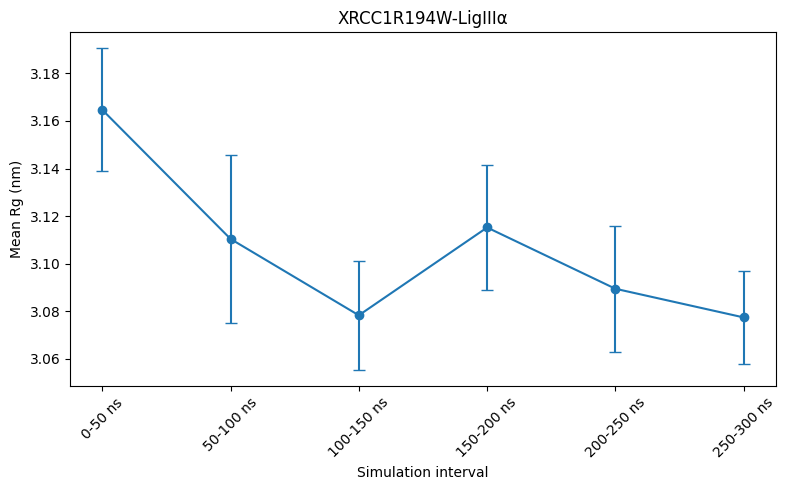

Saved: /home/naba/projects/results/XRCC1R194W-LigIII_Rg_block_analysis.png


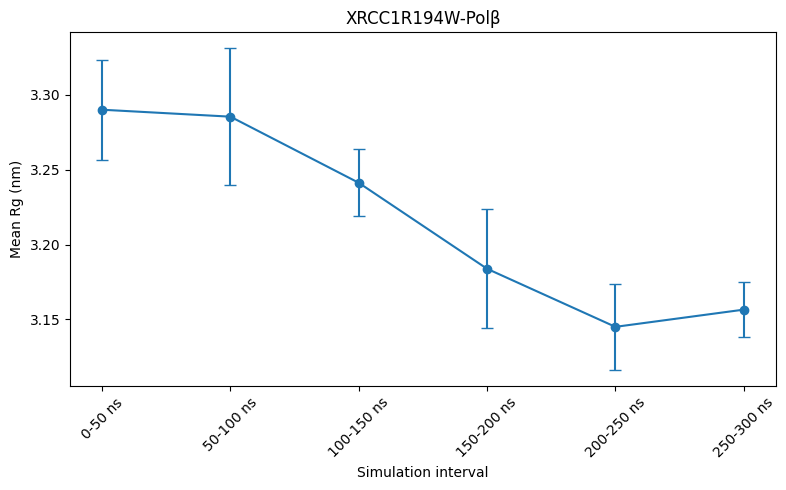

Saved: /home/naba/projects/results/XRCC1R194W-Pol_Rg_block_analysis.png


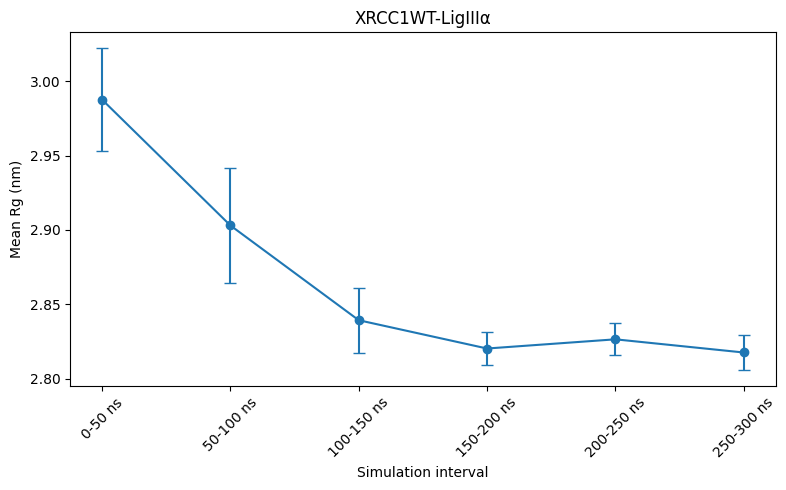

Saved: /home/naba/projects/results/XRCC1WT-LigIII_Rg_block_analysis.png


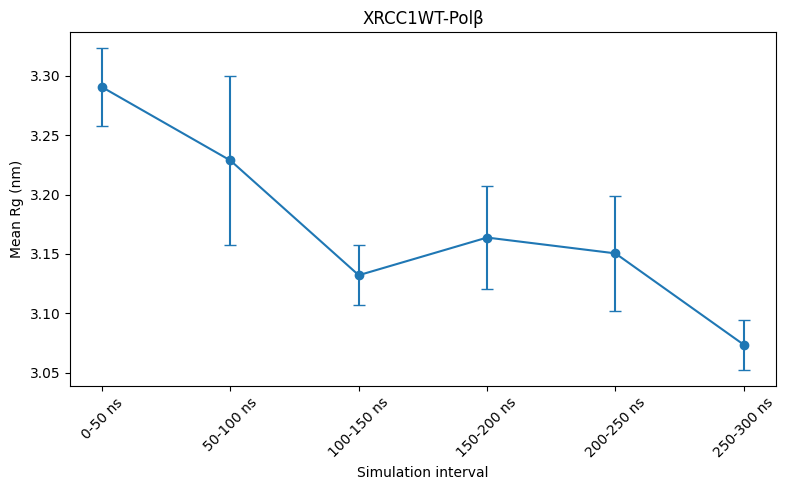

Saved: /home/naba/projects/results/XRCC1WT-Pol_Rg_block_analysis.png


In [14]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_DIR = Path("/home/naba/projects")
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Use results_df if the analysis was run in this notebook; otherwise load its Excel output.
if "results_df" not in globals():
    result_files = sorted(PROJECT_DIR.glob("Rg*_block_statistics.xlsx"))
    if not result_files:
        raise FileNotFoundError(
            "No block-statistics Excel file found. Run block_analysis.py first."
        )
    results_df = pd.read_excel(result_files[0])

block_order = [
    "0-50 ns",
    "50-100 ns",
    "100-150 ns",
    "150-200 ns",
    "200-250 ns",
    "250-300 ns",
]

systems = results_df["System"].dropna().unique()

for system in systems:
    temp = results_df[results_df["System"] == system].copy()
    temp["Block"] = pd.Categorical(
        temp["Block"],
        categories=block_order,
        ordered=True,
    )
    temp = temp.sort_values("Block")

    plt.figure(figsize=(8, 5))
    plt.errorbar(
        temp["Block"],
        temp["Mean"],
        yerr=temp["SD"],
        marker="o",
        capsize=4,
    )
    plt.xlabel("Simulation interval")
    plt.ylabel("Mean Rg (nm)")
    plt.title(system)
    plt.xticks(rotation=45)
    plt.tight_layout()

    filename = re.sub(r"[^A-Za-z0-9_.-]+", "_", str(system)).strip("_")
    output_path = RESULTS_DIR / f"{filename}_Rg_block_analysis.png"
    plt.savefig(output_path, dpi=600, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved: {output_path}")

Generating the comparison plot for all 4

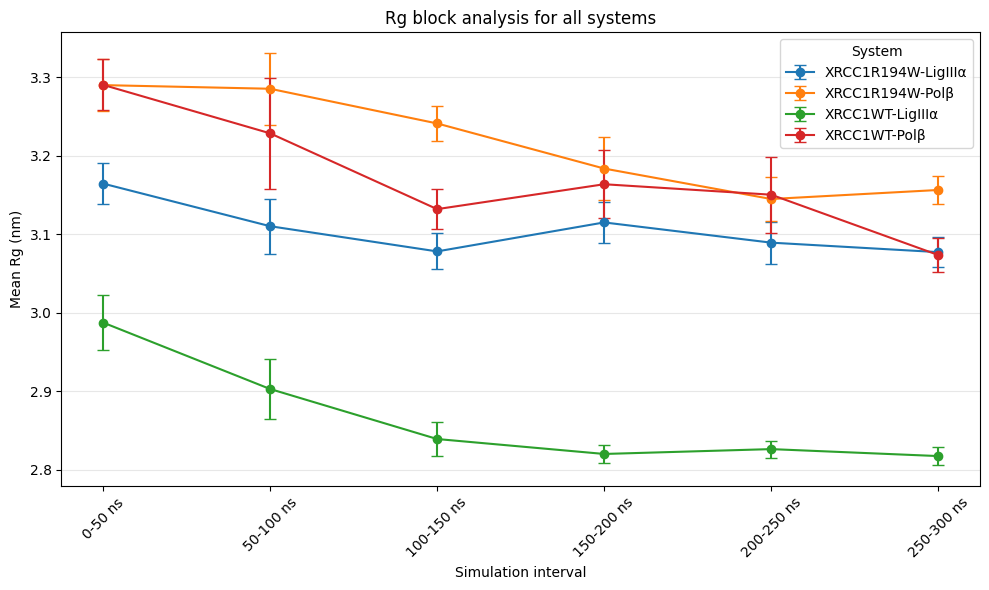

Saved: /home/naba/projects/results/all_systems_Rg_block_analysis.png


In [15]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

PROJECT_DIR = Path("/home/naba/projects")
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Load the block statistics if the analysis cell has not already created results_df.
if "results_df" not in globals():
    result_files = sorted(PROJECT_DIR.glob("Rg*_block_statistics.xlsx"))
    if not result_files:
        raise FileNotFoundError(
            "No block-statistics Excel file found. Run block_analysis.py first."
        )
    results_df = pd.read_excel(result_files[0])

block_order = [
    "0-50 ns",
    "50-100 ns",
    "100-150 ns",
    "150-200 ns",
    "200-250 ns",
    "250-300 ns",
]

results_df = results_df.copy()
results_df["Block"] = pd.Categorical(
    results_df["Block"],
    categories=block_order,
    ordered=True,
)

systems = results_df["System"].dropna().unique()
block_positions = range(len(block_order))

plt.figure(figsize=(10, 6))

for system in systems:
    temp = results_df[results_df["System"] == system].sort_values("Block")
    plt.errorbar(
        block_positions,
        temp["Mean"],
        yerr=temp["SD"],
        marker="o",
        capsize=4,
        linewidth=1.5,
        label=str(system),
    )

plt.xlabel("Simulation interval")
plt.ylabel("Mean Rg (nm)")
plt.title("Rg block analysis for all systems")
plt.xticks(list(block_positions), block_order, rotation=45)
plt.legend(title="System")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

output_path = RESULTS_DIR / "all_systems_Rg_block_analysis.png"
plt.savefig(output_path, dpi=600, bbox_inches="tight")
plt.show()
plt.close()

print(f"Saved: {output_path}")

Like wise, follow the following prompts:
Create a block_analysis-SASA.py for SASA without changing the methodology.
Do not change or run anything in other files.


In [16]:
!python block_analysis-SASA.py


Selected input file:
/home/naba/projects/SASA-WT-replicate-and-R194W.xlsx

Time column: Time

Systems detected:
 - XRCC1WT-LigIIIα
 - XRCC1WT-Polβ
 - XRCC1R194W-LigIIIα
 - XRCC1R194W-Polβ

Block analysis completed successfully.
Output saved to:
/home/naba/projects/SASA-WT-replicate-and-R194W_block_statistics.xlsx

Results:

            System      Block    N       Mean       SD     Min     Max
XRCC1R194W-LigIIIα    0-50 ns 5000 364.362729 4.676215 348.106 379.194
XRCC1R194W-LigIIIα  50-100 ns 5000 355.357877 5.043421 339.897 374.974
XRCC1R194W-LigIIIα 100-150 ns 5000 351.518882 3.934089 337.194 365.999
XRCC1R194W-LigIIIα 150-200 ns 5000 355.697170 4.116182 341.772 370.238
XRCC1R194W-LigIIIα 200-250 ns 5000 353.439998 5.264172 337.834 369.459
XRCC1R194W-LigIIIα 250-300 ns 5001 347.416293 3.292127 335.538 359.763
   XRCC1R194W-Polβ    0-50 ns 5000 363.853153 3.814664 351.318 380.134
   XRCC1R194W-Polβ  50-100 ns 5000 364.419374 4.164545 350.260 377.769
   XRCC1R194W-Polβ 100-150 ns 5000

Plots

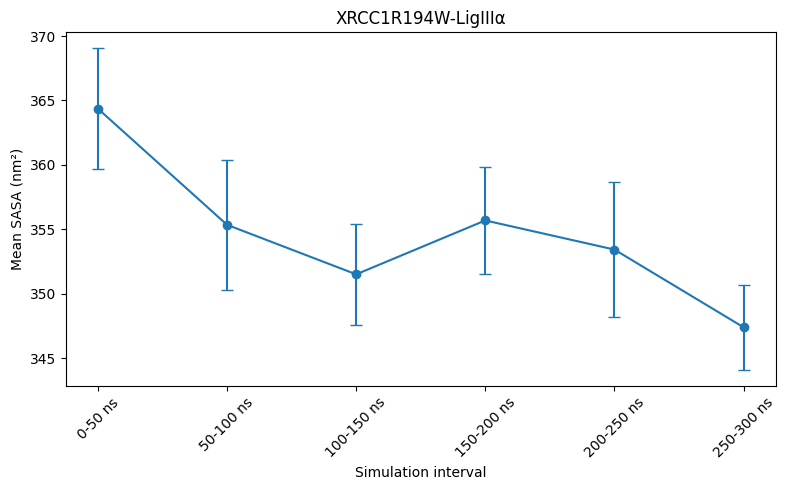

Saved: /home/naba/projects/results/XRCC1R194W-LigIII_SASA_block_analysis.png


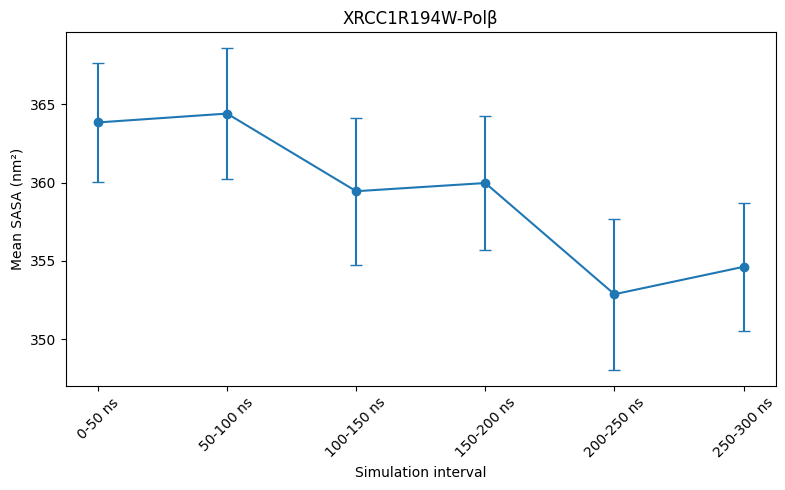

Saved: /home/naba/projects/results/XRCC1R194W-Pol_SASA_block_analysis.png


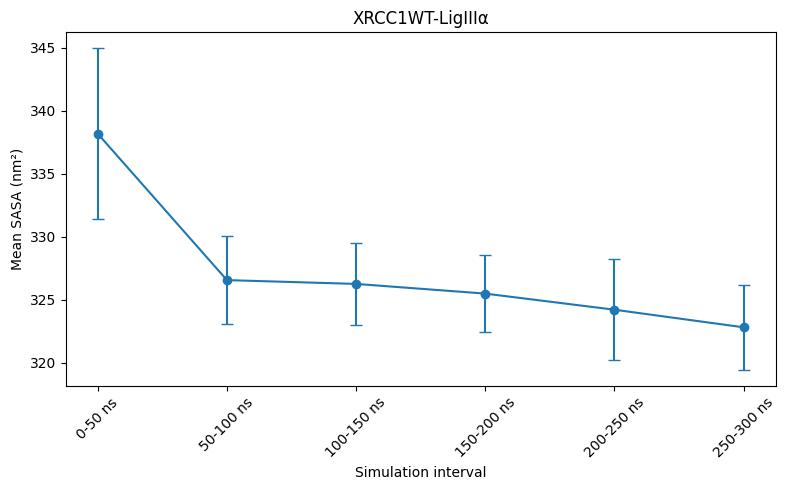

Saved: /home/naba/projects/results/XRCC1WT-LigIII_SASA_block_analysis.png


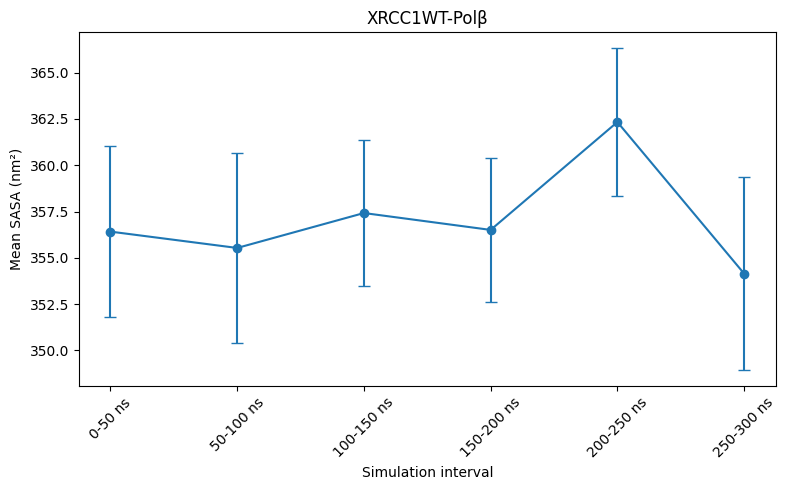

Saved: /home/naba/projects/results/XRCC1WT-Pol_SASA_block_analysis.png


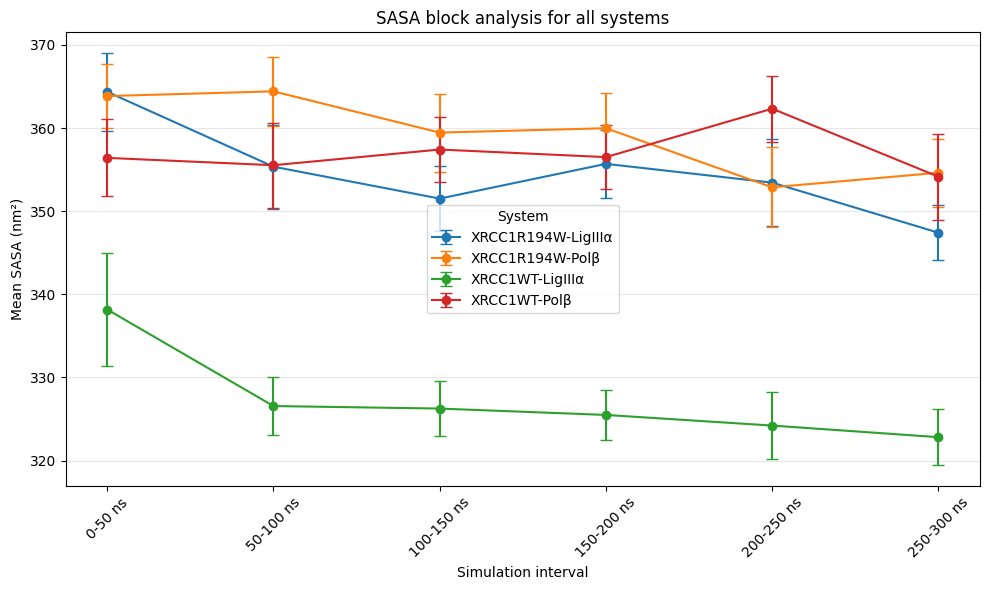

Saved: /home/naba/projects/results/all_systems_SASA_block_analysis-SD.png


In [70]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_DIR = Path("/home/naba/projects")
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

result_files = sorted(PROJECT_DIR.glob("SASA*_block_statistics.xlsx"))
if not result_files:
    raise FileNotFoundError(
        "No SASA block-statistics Excel file found. Run block_analysis-SASA.py first."
    )

results_df = pd.read_excel(result_files[0])
block_order = [
    "0-50 ns",
    "50-100 ns",
    "100-150 ns",
    "150-200 ns",
    "200-250 ns",
    "250-300 ns",
]

results_df["Block"] = pd.Categorical(
    results_df["Block"],
    categories=block_order,
    ordered=True,
)
systems = results_df["System"].dropna().unique()

for system in systems:
    temp = results_df[results_df["System"] == system].sort_values("Block")

    plt.figure(figsize=(8, 5))
    plt.errorbar(
        temp["Block"],
        temp["Mean"],
        yerr=temp["SD"],
        marker="o",
        capsize=4,
    )
    plt.xlabel("Simulation interval")
    plt.ylabel("Mean SASA (nm²)")
    plt.title(system)
    plt.xticks(rotation=45)
    plt.tight_layout()

    filename = re.sub(r"[^A-Za-z0-9_.-]+", "_", str(system)).strip("_")
    output_path = RESULTS_DIR / f"{filename}_SASA_block_analysis.png"
    plt.savefig(output_path, dpi=600, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"Saved: {output_path}")

block_positions = range(len(block_order))
legend_position = (0.8, 0.3)
plt.figure(figsize=(10, 6))

for system in systems:
    temp = results_df[results_df["System"] == system].sort_values("Block")
    plt.errorbar(
        block_positions,
        temp["Mean"],
        yerr=temp["SD"],
        marker="o",
        capsize=4,
        linewidth=1.5,
        label=str(system),
    )

plt.xlabel("Simulation interval")
plt.ylabel("Mean SASA (nm²)")
plt.title("SASA block analysis for all systems")
plt.xticks(list(block_positions), block_order, rotation=45)
plt.legend(title="System")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

output_path = RESULTS_DIR / "all_systems_SASA_block_analysis-SD.png"
plt.savefig(output_path, dpi=600, bbox_inches="tight")
plt.show()
plt.close()
print(f"Saved: {output_path}")

Comparison plot

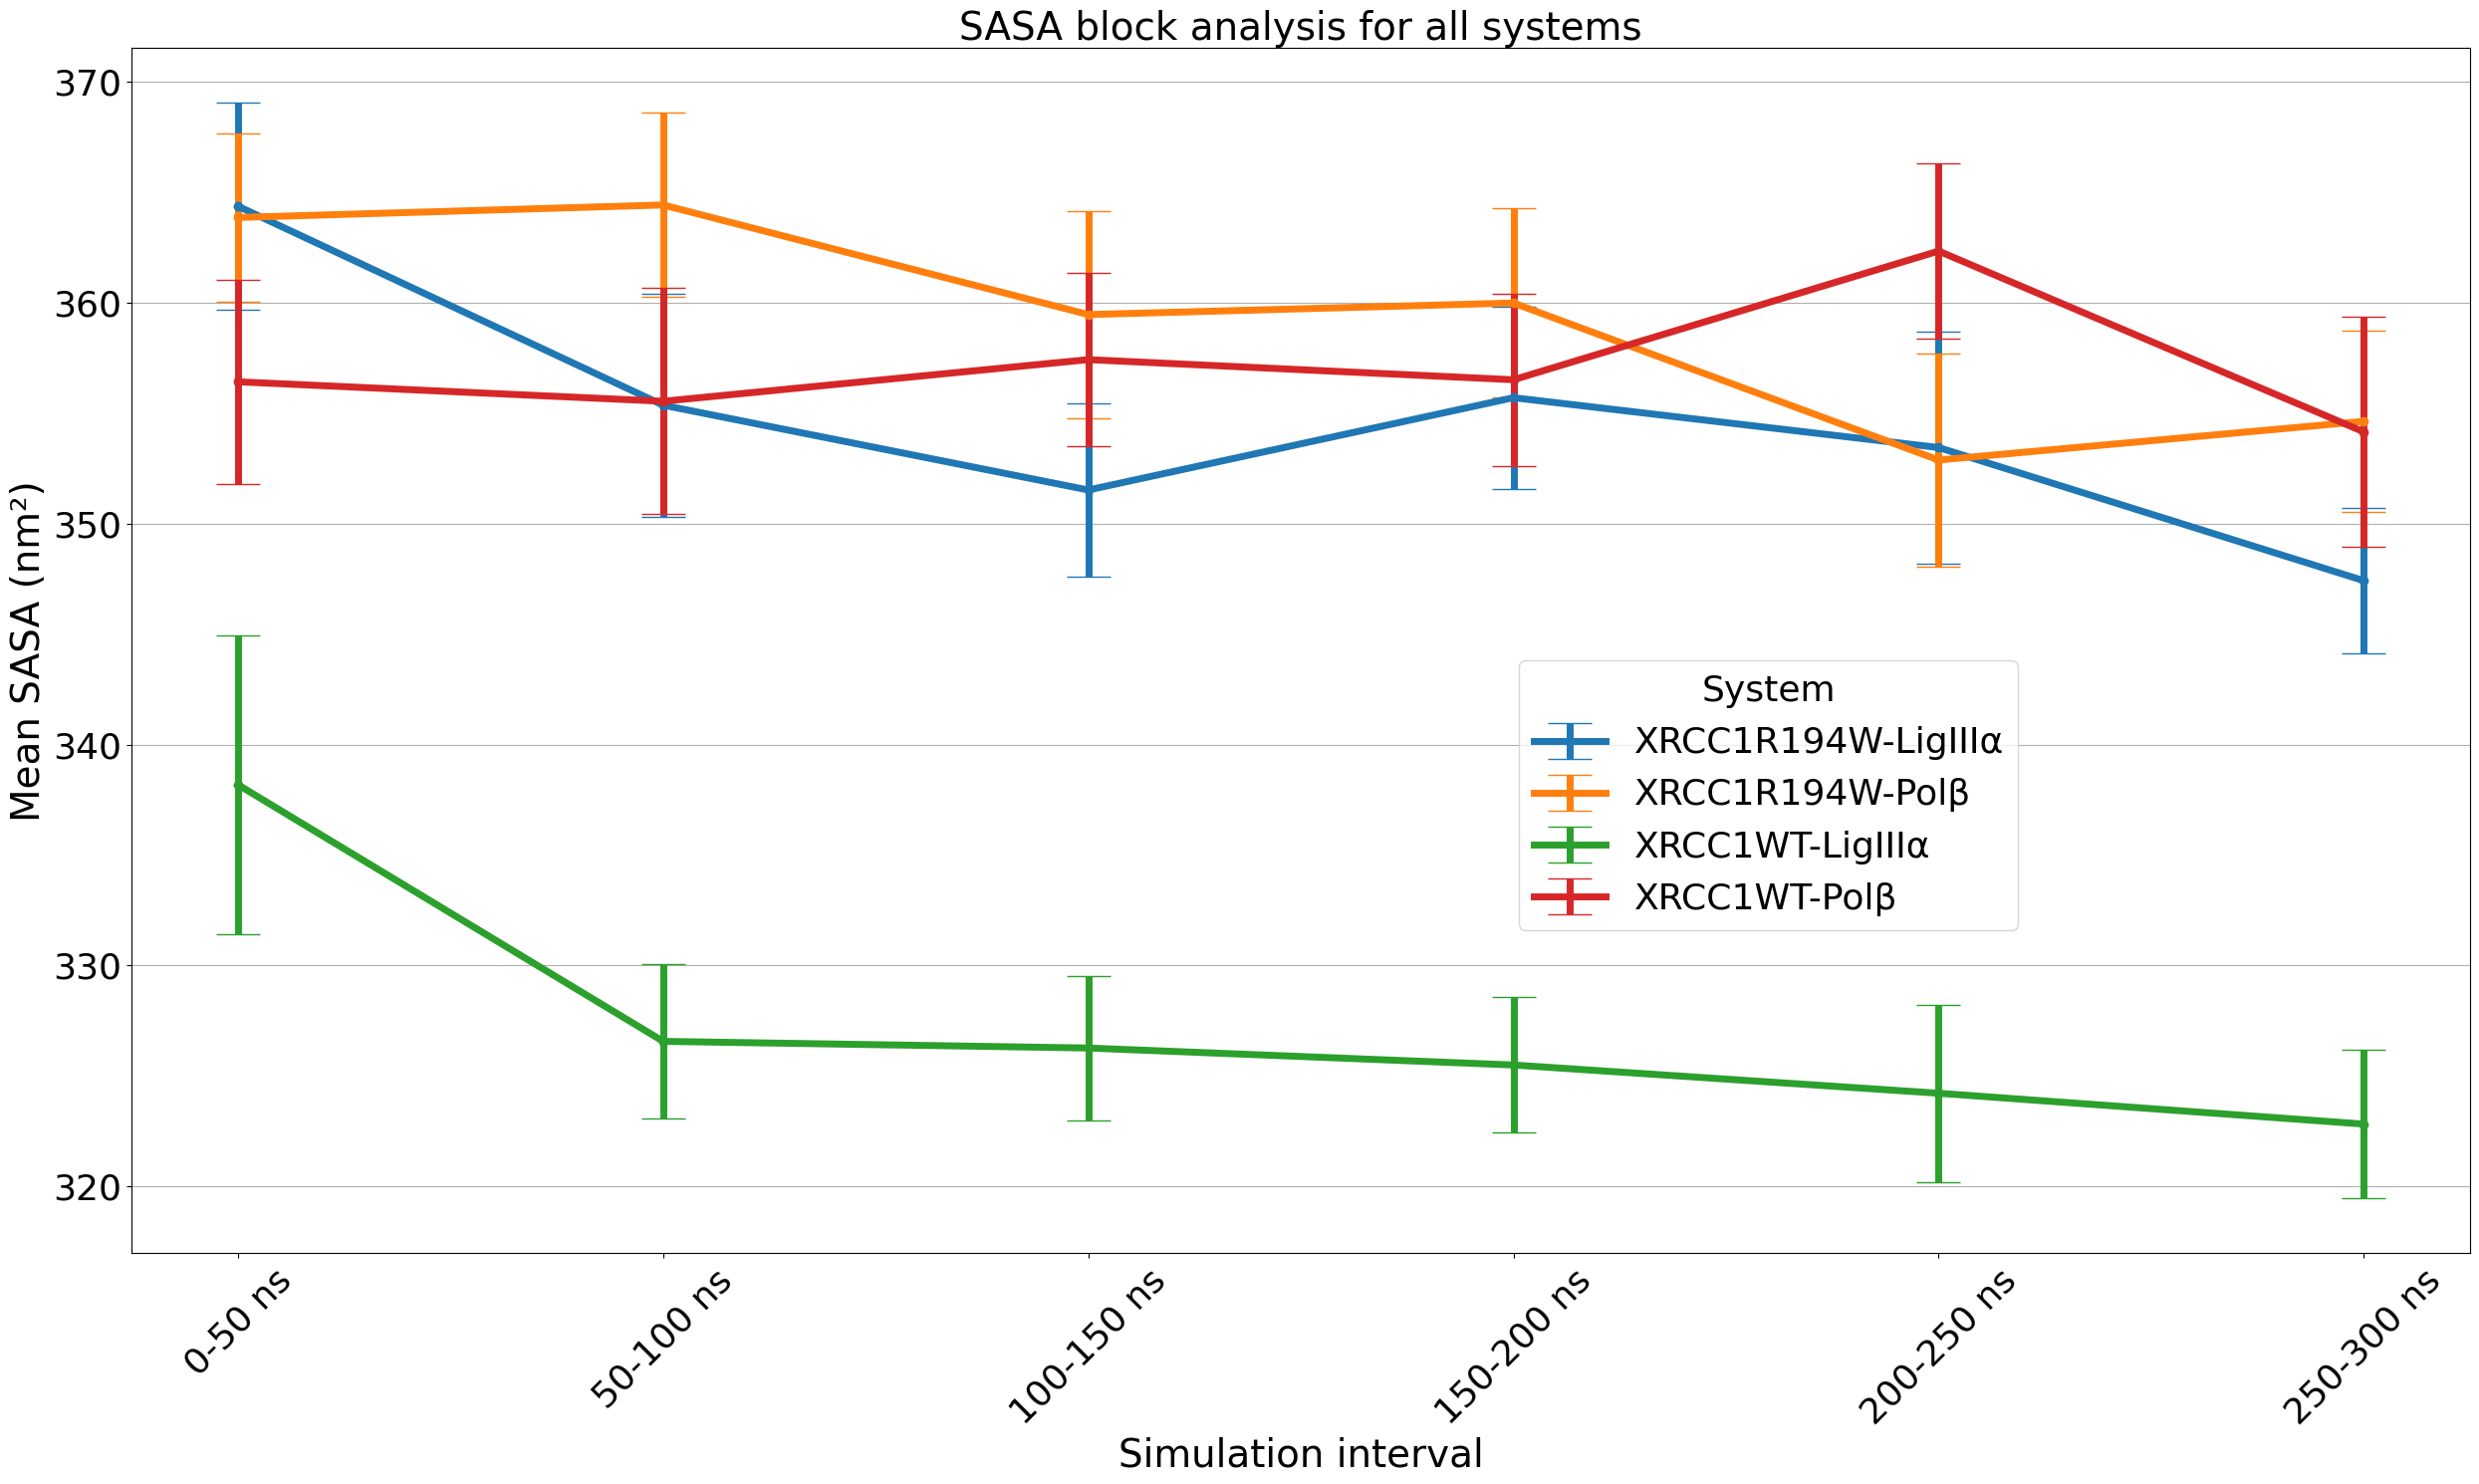

Saved: /home/naba/projects/results/all_systems_SASA_block_analysis.png


In [67]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

PROJECT_DIR = Path("/home/naba/projects")
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

result_files = sorted(PROJECT_DIR.glob("SASA*_block_statistics.xlsx"))
if not result_files:
    raise FileNotFoundError(
        "No SASA block-statistics Excel file found. Run block_analysis-SASA.py first."
    )

results_df = pd.read_excel(result_files[0])
block_order = [
    "0-50 ns",
    "50-100 ns",
    "100-150 ns",
    "150-200 ns",
    "200-250 ns",
    "250-300 ns",
]

results_df = results_df.copy()
results_df["Block"] = pd.Categorical(
    results_df["Block"],
    categories=block_order,
    ordered=True,
)

systems = results_df["System"].dropna().unique()
block_positions = range(len(block_order))

# Change these two values to move the legend box.
# x: 0 = left, 1 = right; y: 0 = bottom, 1 = top.
legend_position = (0.7, 0.38)

plt.figure(figsize=(25, 15))

for system in systems:
    temp = results_df[results_df["System"] == system].sort_values("Block")
    plt.errorbar(
        block_positions,
        temp["Mean"],
        yerr=temp["SD"],
        marker="o",
        capsize=16,
        linewidth=5,
        label=str(system),
    )

plt.xlabel("Simulation interval", fontsize=28)
plt.ylabel("Mean SASA (nm²)", fontsize=28)
plt.title("SASA block analysis for all systems", fontsize=28)
plt.xticks(list(block_positions), block_order, rotation=45, fontsize=26)
plt.yticks(fontsize=26)
plt.legend(
    title="System",
    title_fontsize=26,
    fontsize=26,
    loc="center",
    bbox_to_anchor=legend_position,
)
plt.grid(axis="y", alpha=1)
plt.tight_layout()

output_path = RESULTS_DIR / "all_systems_SASA_block_analysis.png"
plt.savefig(output_path, dpi=1200, bbox_inches="tight")
plt.show()
plt.close()

print(f"Saved: {output_path}")

MMPBSA Block Analysis

For MM

In [1]:
!python block_analysis-MM.py


Selected input file:
/home/naba/projects/MM-WT-replicate-and-R194W.xlsx

Time column: Time
Time values are interpreted directly in ns (0.5 ns intervals).

Systems detected:
 - XRCC1WT-LigIIIα
 - XRCC1WT-Polβ
 - XRCC1R194W-LigIIIα
 - XRCC1R194W-Polβ

Block analysis completed successfully.
Output saved to:
/home/naba/projects/MM-WT-replicate-and-R194W_block_statistics.xlsx

Results:

            System      Block   N        Mean        SD      Min      Max
XRCC1R194W-LigIIIα    0-50 ns 100 -298.407650 38.932371 -365.183 -203.638
XRCC1R194W-LigIIIα  50-100 ns 100 -319.716510 23.247157 -369.468 -251.301
XRCC1R194W-LigIIIα 100-150 ns 100 -257.910010 25.006266 -334.530 -184.449
XRCC1R194W-LigIIIα 150-200 ns 100 -249.165770 21.743714 -298.218 -205.211
XRCC1R194W-LigIIIα 200-250 ns 100 -251.512430 22.301734 -292.722 -179.407
XRCC1R194W-LigIIIα 250-300 ns 101 -255.896099 21.439953 -307.731 -201.431
   XRCC1R194W-Polβ    0-50 ns 100 -246.621320 33.981418 -340.846 -155.569
   XRCC1R194W-Polβ  50

MM-Plots

4 Plots

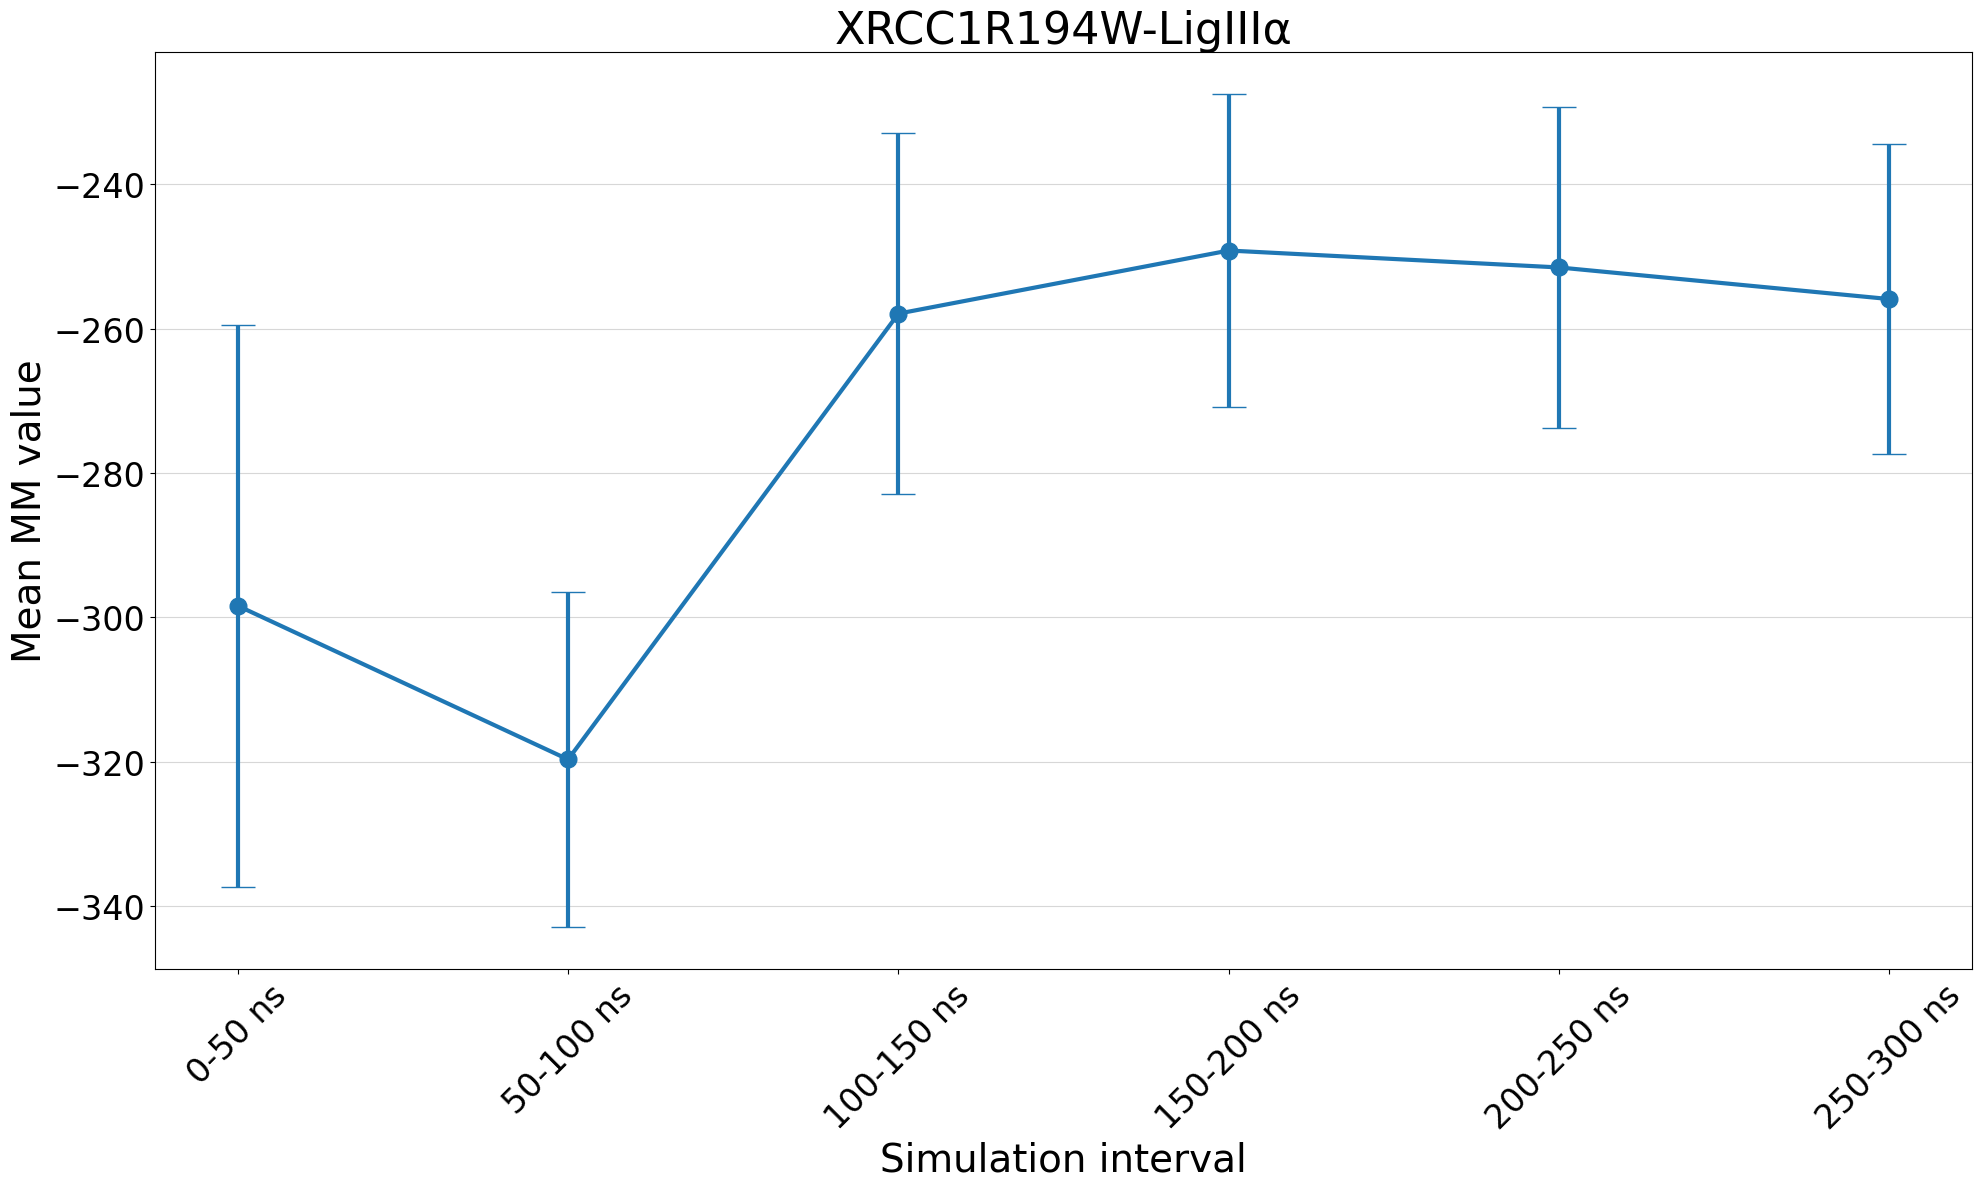

Saved: /home/naba/projects/results/XRCC1R194W-LigIII_MM_block_analysis.png


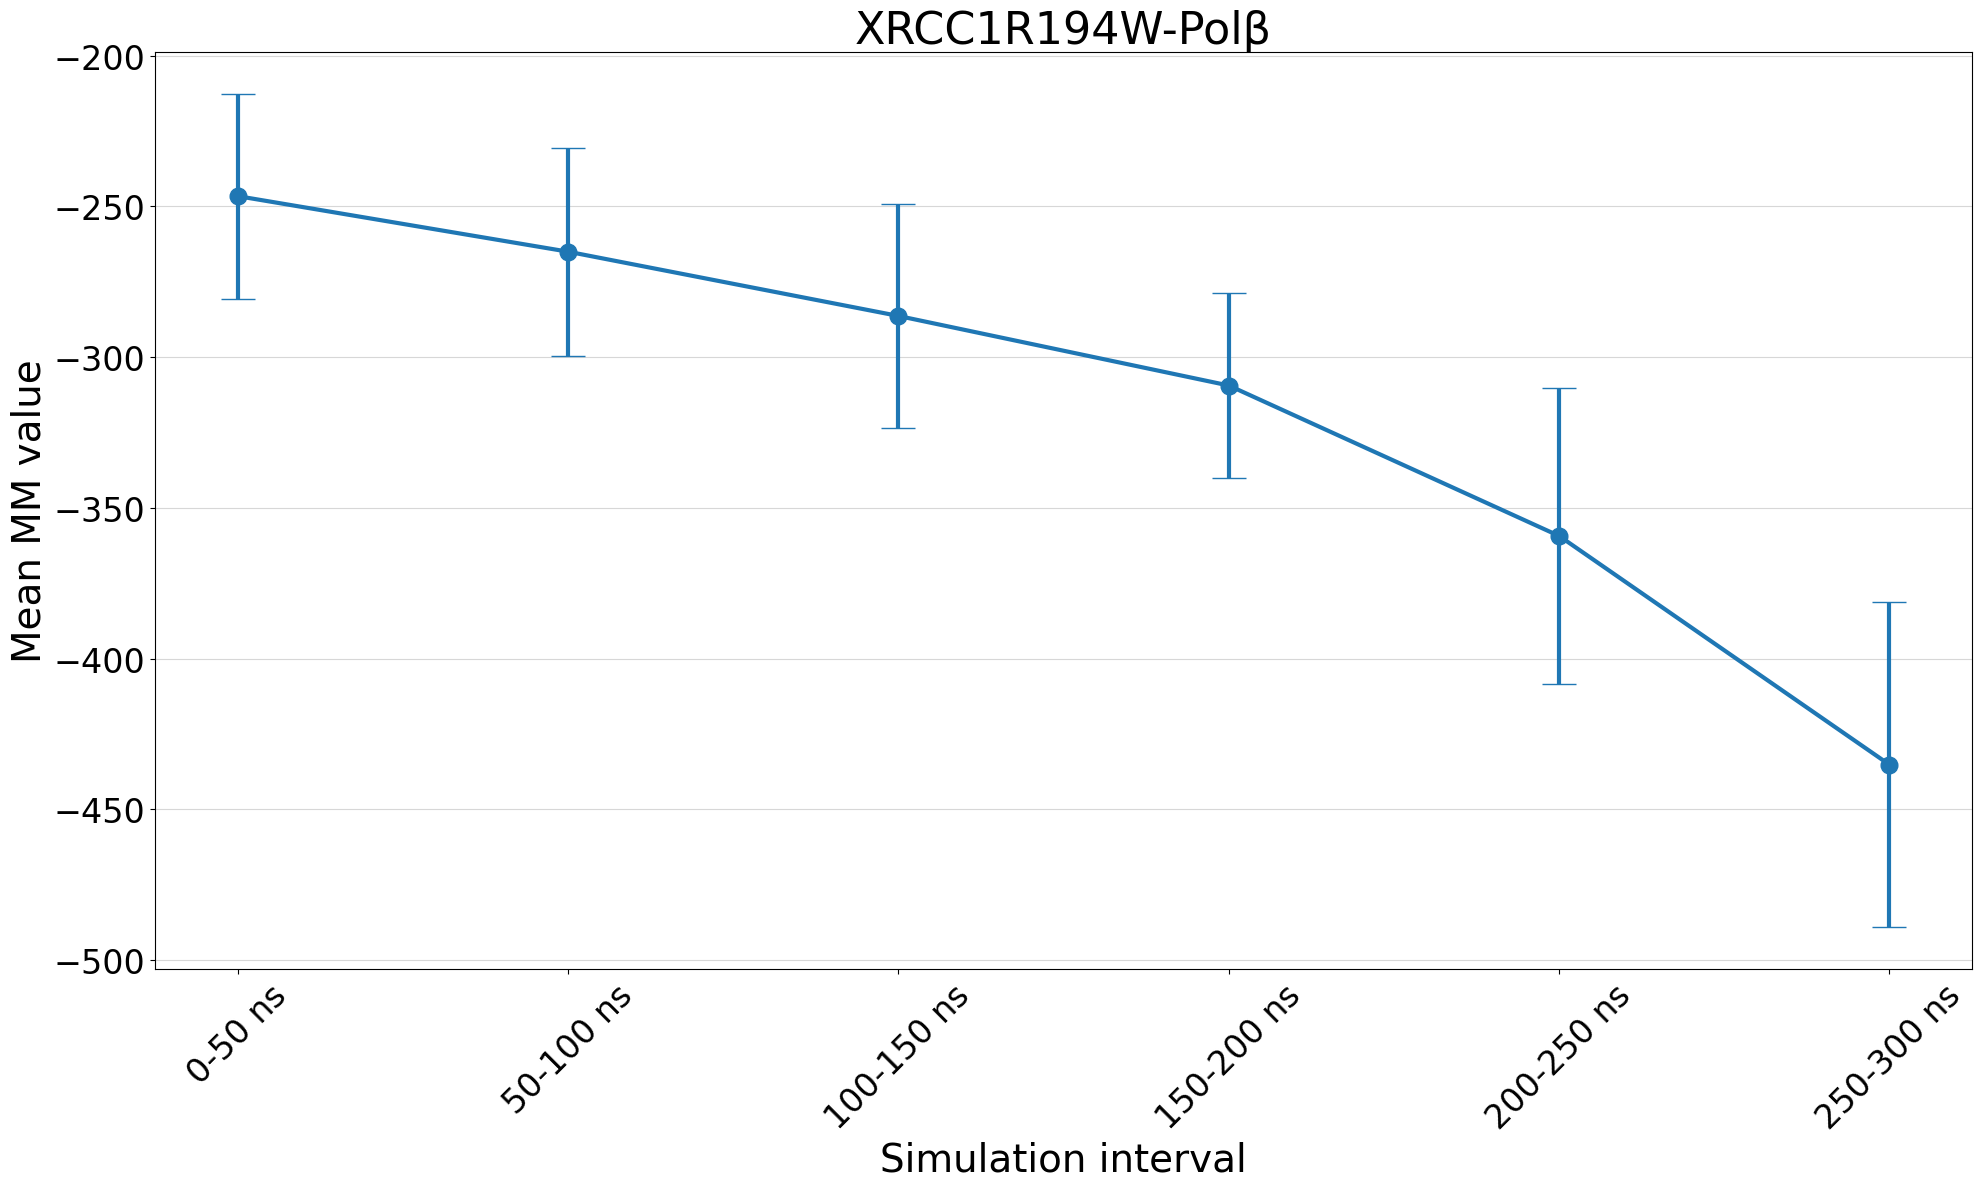

Saved: /home/naba/projects/results/XRCC1R194W-Pol_MM_block_analysis.png


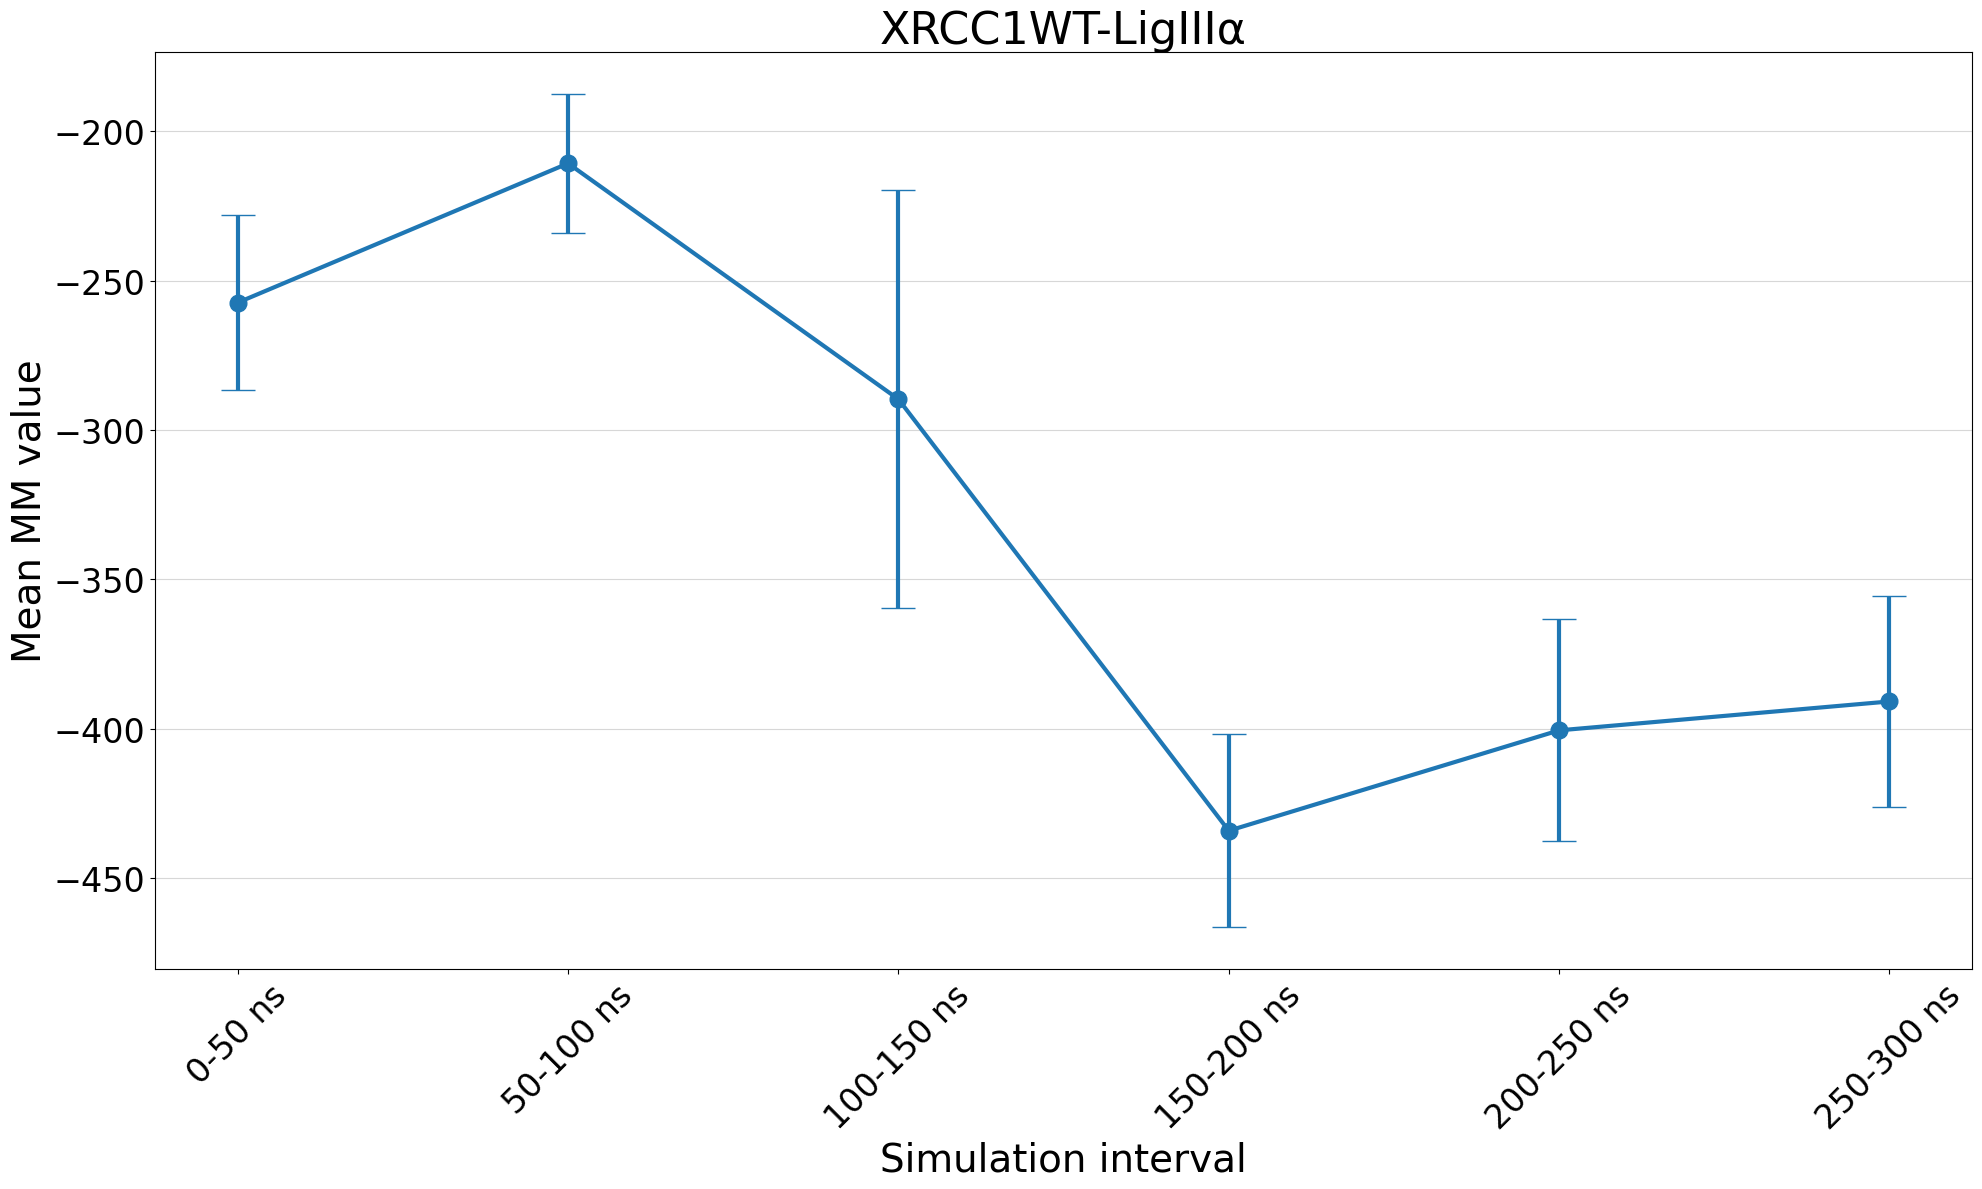

Saved: /home/naba/projects/results/XRCC1WT-LigIII_MM_block_analysis.png


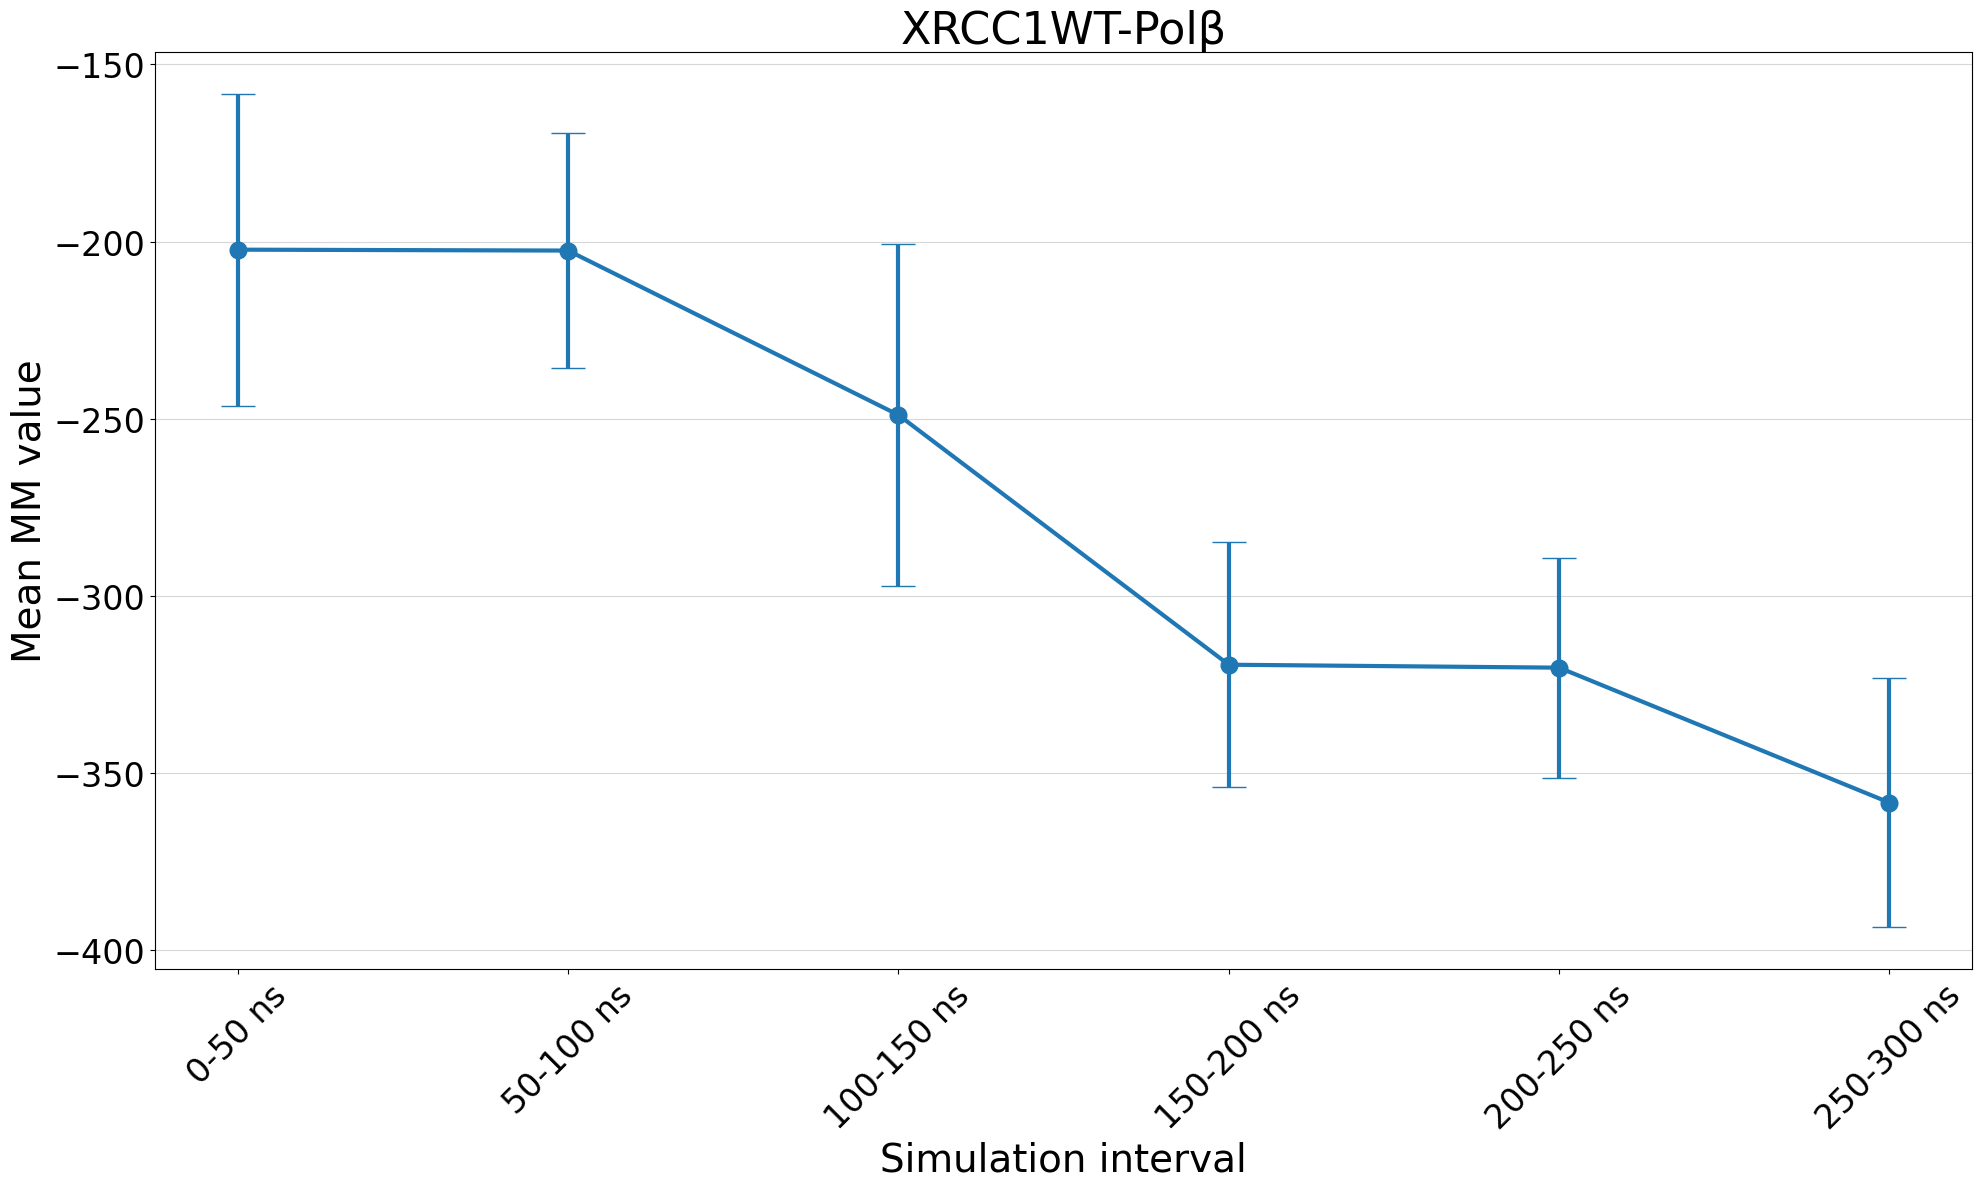

Saved: /home/naba/projects/results/XRCC1WT-Pol_MM_block_analysis.png


In [4]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_DIR = Path("/home/naba/projects")
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

result_files = sorted(PROJECT_DIR.glob("MM*_block_statistics.xlsx"))
if not result_files:
    raise FileNotFoundError(
        "No MM block-statistics Excel file found. Run block_analysis-MM.py first."
    )

results_df = pd.read_excel(result_files[0])
block_order = [
    "0-50 ns",
    "50-100 ns",
    "100-150 ns",
    "150-200 ns",
    "200-250 ns",
    "250-300 ns",
]

results_df = results_df.copy()
results_df["Block"] = pd.Categorical(
    results_df["Block"],
    categories=block_order,
    ordered=True,
)
systems = results_df["System"].dropna().unique()

for system in systems:
    temp = results_df[results_df["System"] == system].sort_values("Block")

    plt.figure(figsize=(20, 12))
    plt.errorbar(
        temp["Block"],
        temp["Mean"],
        yerr=temp["SD"],
        marker="o",
        markersize=12,
        capsize=12,
        linewidth=3,
    )
    plt.xlabel("Simulation interval", fontsize=28)
    plt.ylabel("Mean MM value", fontsize=28)
    plt.title(str(system), fontsize=32)
    plt.xticks(rotation=45, fontsize=24)
    plt.yticks(fontsize=24)
    plt.grid(axis="y", alpha=0.5)
    plt.tight_layout()

    filename = re.sub(r"[^A-Za-z0-9_.-]+", "_", str(system)).strip("_")
    output_path = RESULTS_DIR / f"{filename}_MM_block_analysis.png"
    plt.savefig(output_path, dpi=1200, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"Saved: {output_path}")

Comparison plot

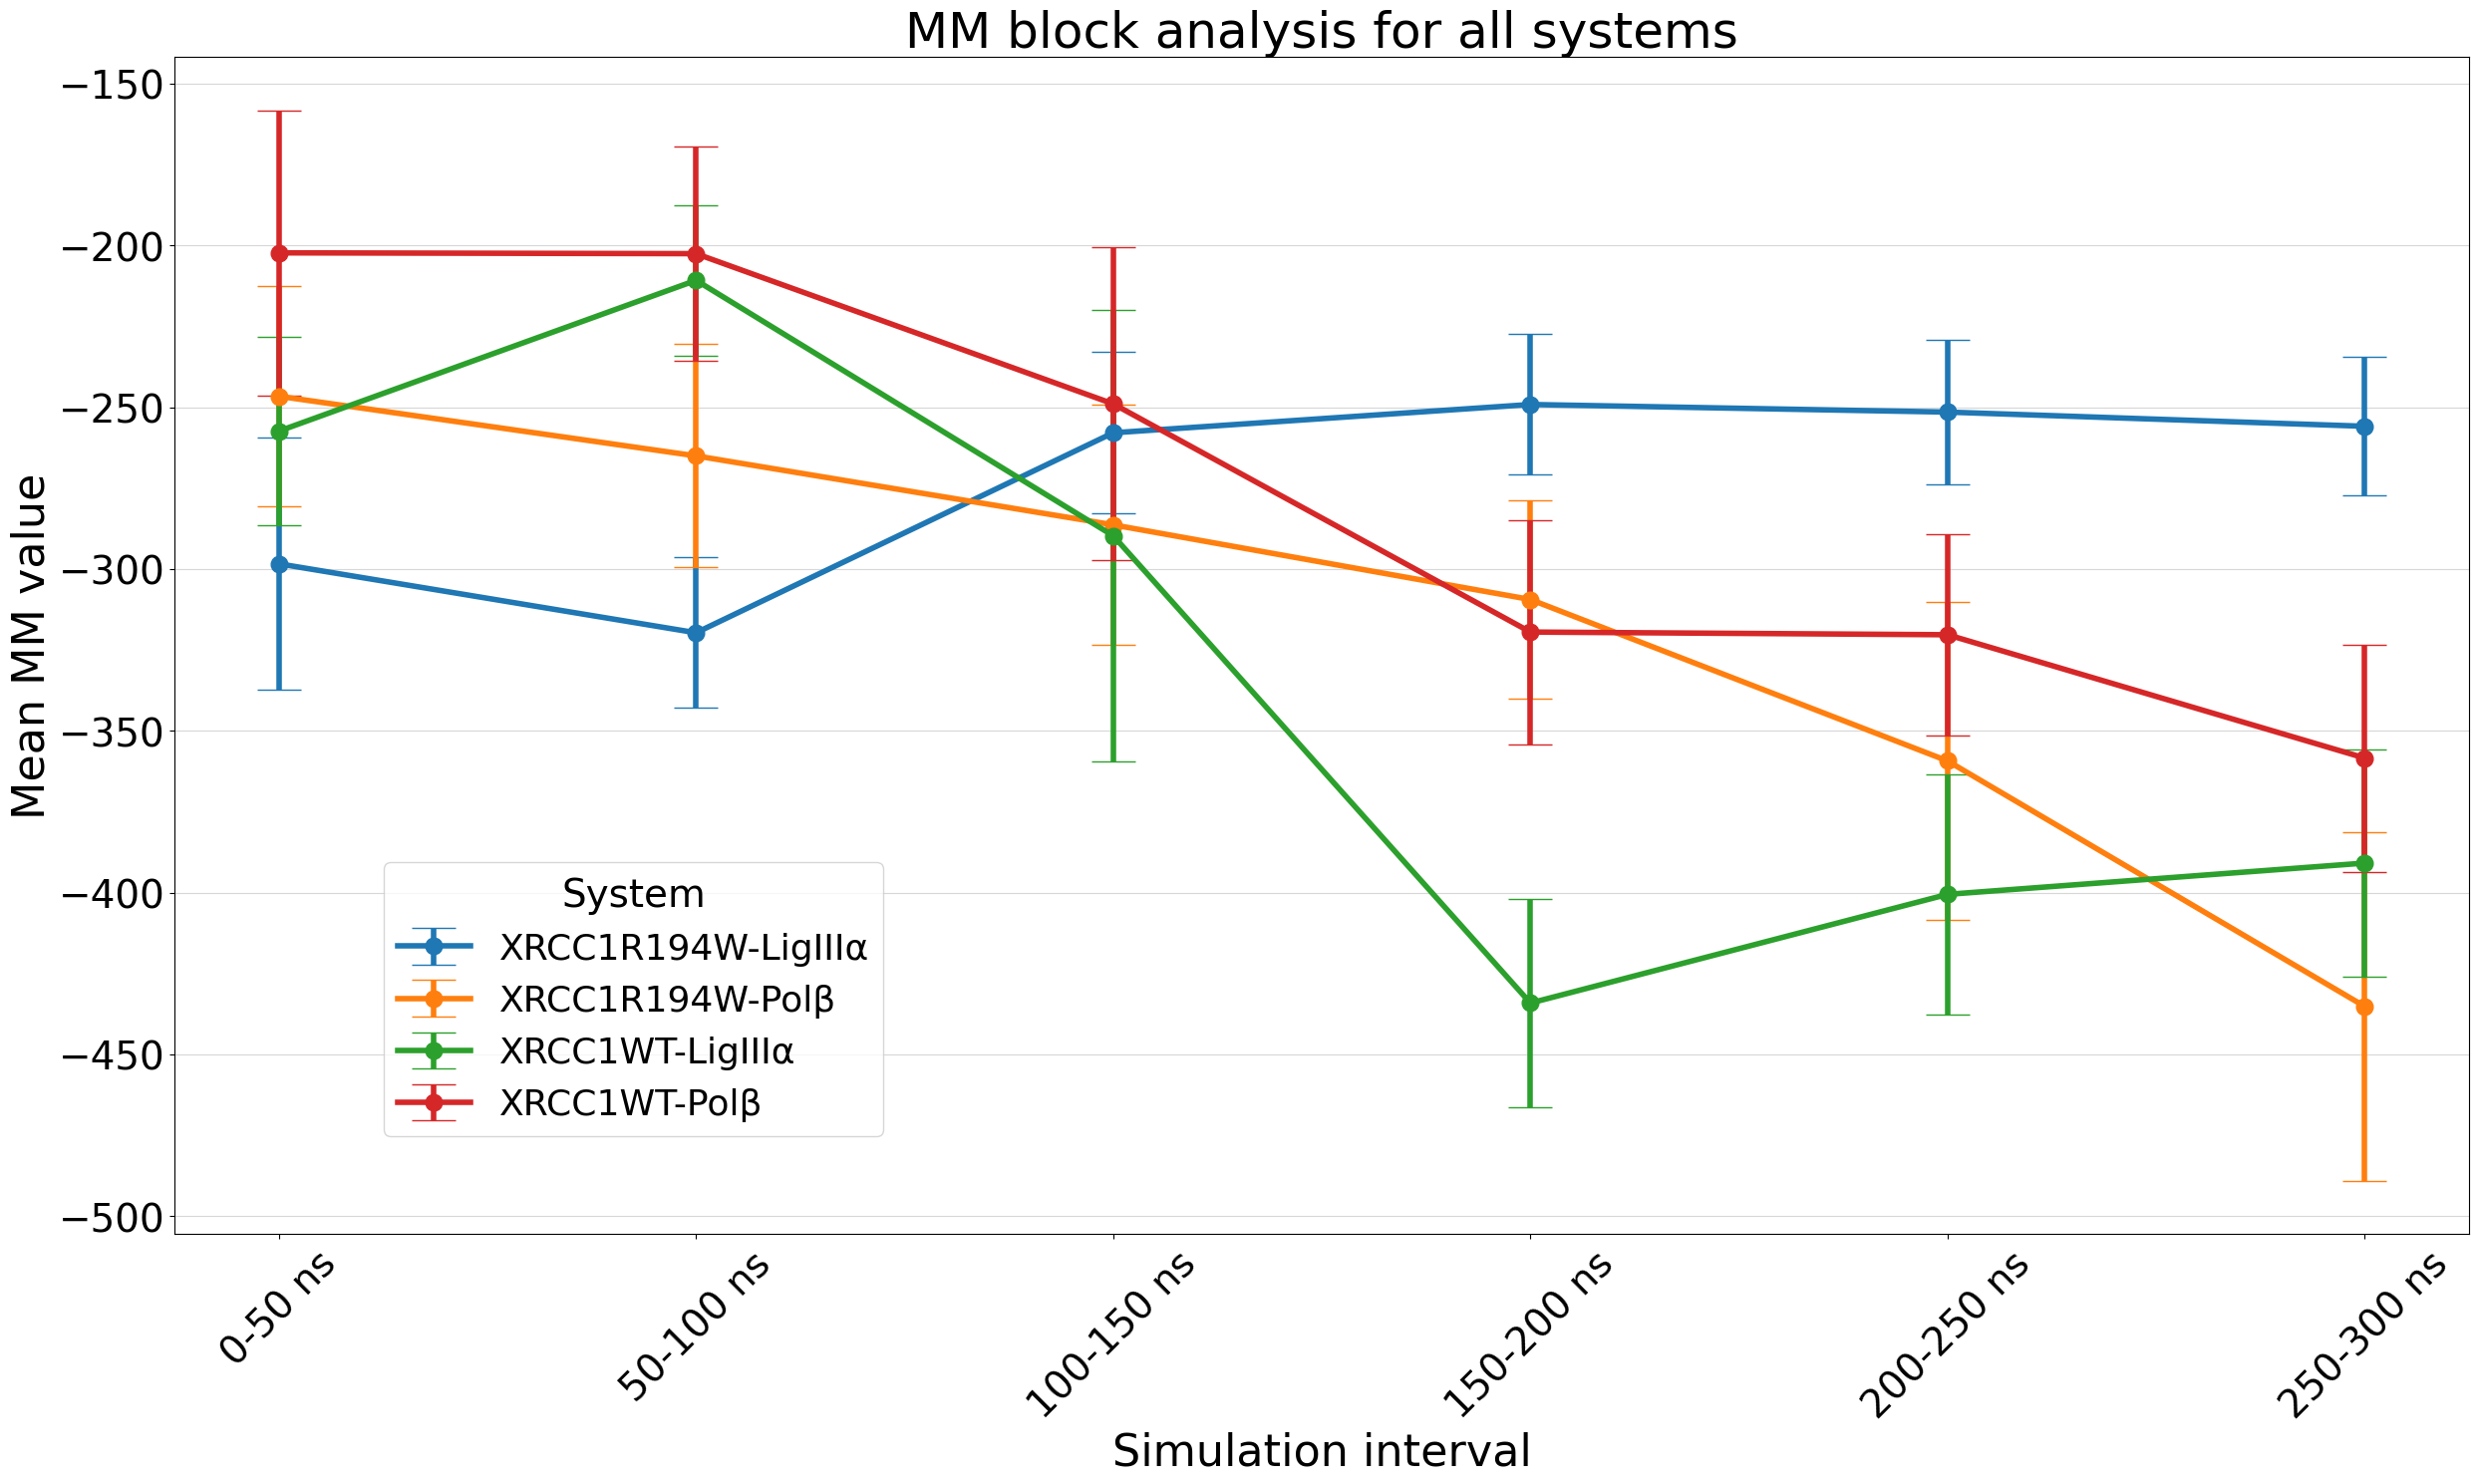

Saved: /home/naba/projects/results/all_systems_MM_block_analysis.png


In [7]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

PROJECT_DIR = Path("/home/naba/projects")
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

result_files = sorted(PROJECT_DIR.glob("MM*_block_statistics.xlsx"))
if not result_files:
    raise FileNotFoundError(
        "No MM block-statistics Excel file found. Run block_analysis-MM.py first."
    )

results_df = pd.read_excel(result_files[0])
block_order = [
    "0-50 ns",
    "50-100 ns",
    "100-150 ns",
    "150-200 ns",
    "200-250 ns",
    "250-300 ns",
]

results_df = results_df.copy()
results_df["Block"] = pd.Categorical(
    results_df["Block"],
    categories=block_order,
    ordered=True,
)
systems = results_df["System"].dropna().unique()
block_positions = range(len(block_order))

# Change these two values to move the legend box.
# x: 0 = left, 1 = right; y: 0 = bottom, 1 = top.
legend_position = (0.2, 0.2)

plt.figure(figsize=(25, 15))

for system in systems:
    temp = results_df[results_df["System"] == system].sort_values("Block")
    plt.errorbar(
        block_positions,
        temp["Mean"],
        yerr=temp["SD"],
        marker="o",
        markersize=12,
        capsize=16,
        linewidth=4,
        label=str(system),
    )

plt.xlabel("Simulation interval", fontsize=32)
plt.ylabel("Mean MM value", fontsize=32)
plt.title("MM block analysis for all systems", fontsize=36)
plt.xticks(list(block_positions), block_order, rotation=45, fontsize=28)
plt.yticks(fontsize=28)
plt.legend(
    title="System",
    title_fontsize=28,
    fontsize=26,
    loc="center",
    bbox_to_anchor=legend_position,
)
plt.grid(axis="y", alpha=0.5)
plt.tight_layout()

output_path = RESULTS_DIR / "all_systems_MM_block_analysis.png"
plt.savefig(output_path, dpi=1200, bbox_inches="tight")
plt.show()
plt.close()

print(f"Saved: {output_path}")

PB Block analysis

In [8]:
!python block_analysis-PB.py


Selected input file:
/home/naba/projects/PB-WT-replicate-and-R194W.xlsx

Time column: Time
Time values are interpreted directly in ns (0.5 ns intervals).

Systems detected:
 - XRCC1WT-LigIIIα
 - XRCC1WT-Polβ
 - XRCC1R194W-LigIIIα
 - XRCC1R194W-Polβ

Block analysis completed successfully.
Output saved to:
/home/naba/projects/PB-WT-replicate-and-R194W_block_statistics.xlsx

Results:

            System      Block   N       Mean        SD     Min     Max
XRCC1R194W-LigIIIα    0-50 ns 100 227.810010 41.837316 131.587 323.392
XRCC1R194W-LigIIIα  50-100 ns 100 232.591560 39.992282 172.803 361.438
XRCC1R194W-LigIIIα 100-150 ns 100 210.271220 40.390384 116.028 303.992
XRCC1R194W-LigIIIα 150-200 ns 100 224.022370 26.320080 157.728 282.432
XRCC1R194W-LigIIIα 200-250 ns 100 210.657310 45.000733 115.359 290.150
XRCC1R194W-LigIIIα 250-300 ns 101 220.212881 26.963444 144.651 301.704
   XRCC1R194W-Polβ    0-50 ns 100 216.999650 67.582660  69.336 362.103
   XRCC1R194W-Polβ  50-100 ns 100 228.689610 4

PB-Plots

4 Plots

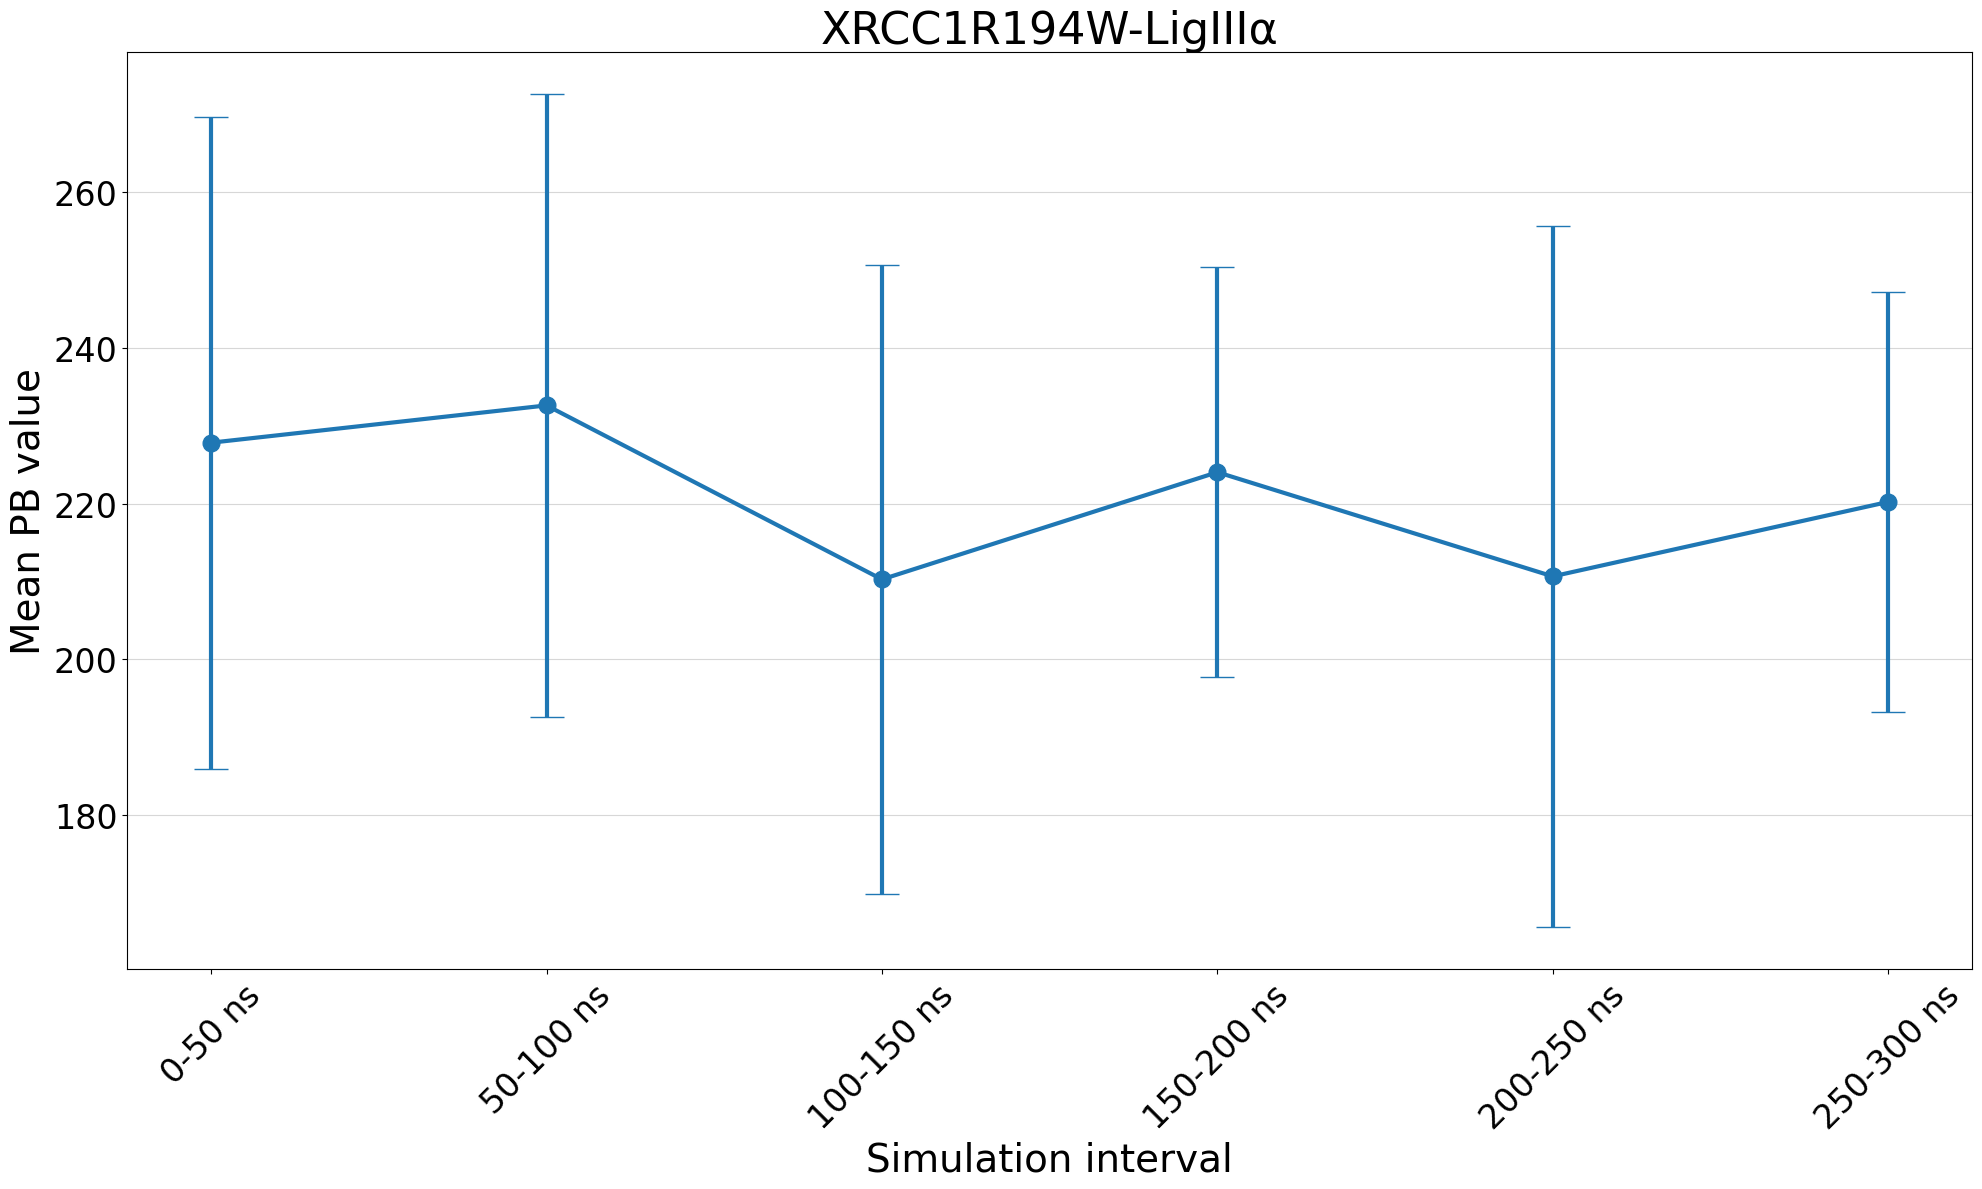

Saved: /home/naba/projects/results/XRCC1R194W-LigIII_PB_block_analysis.png


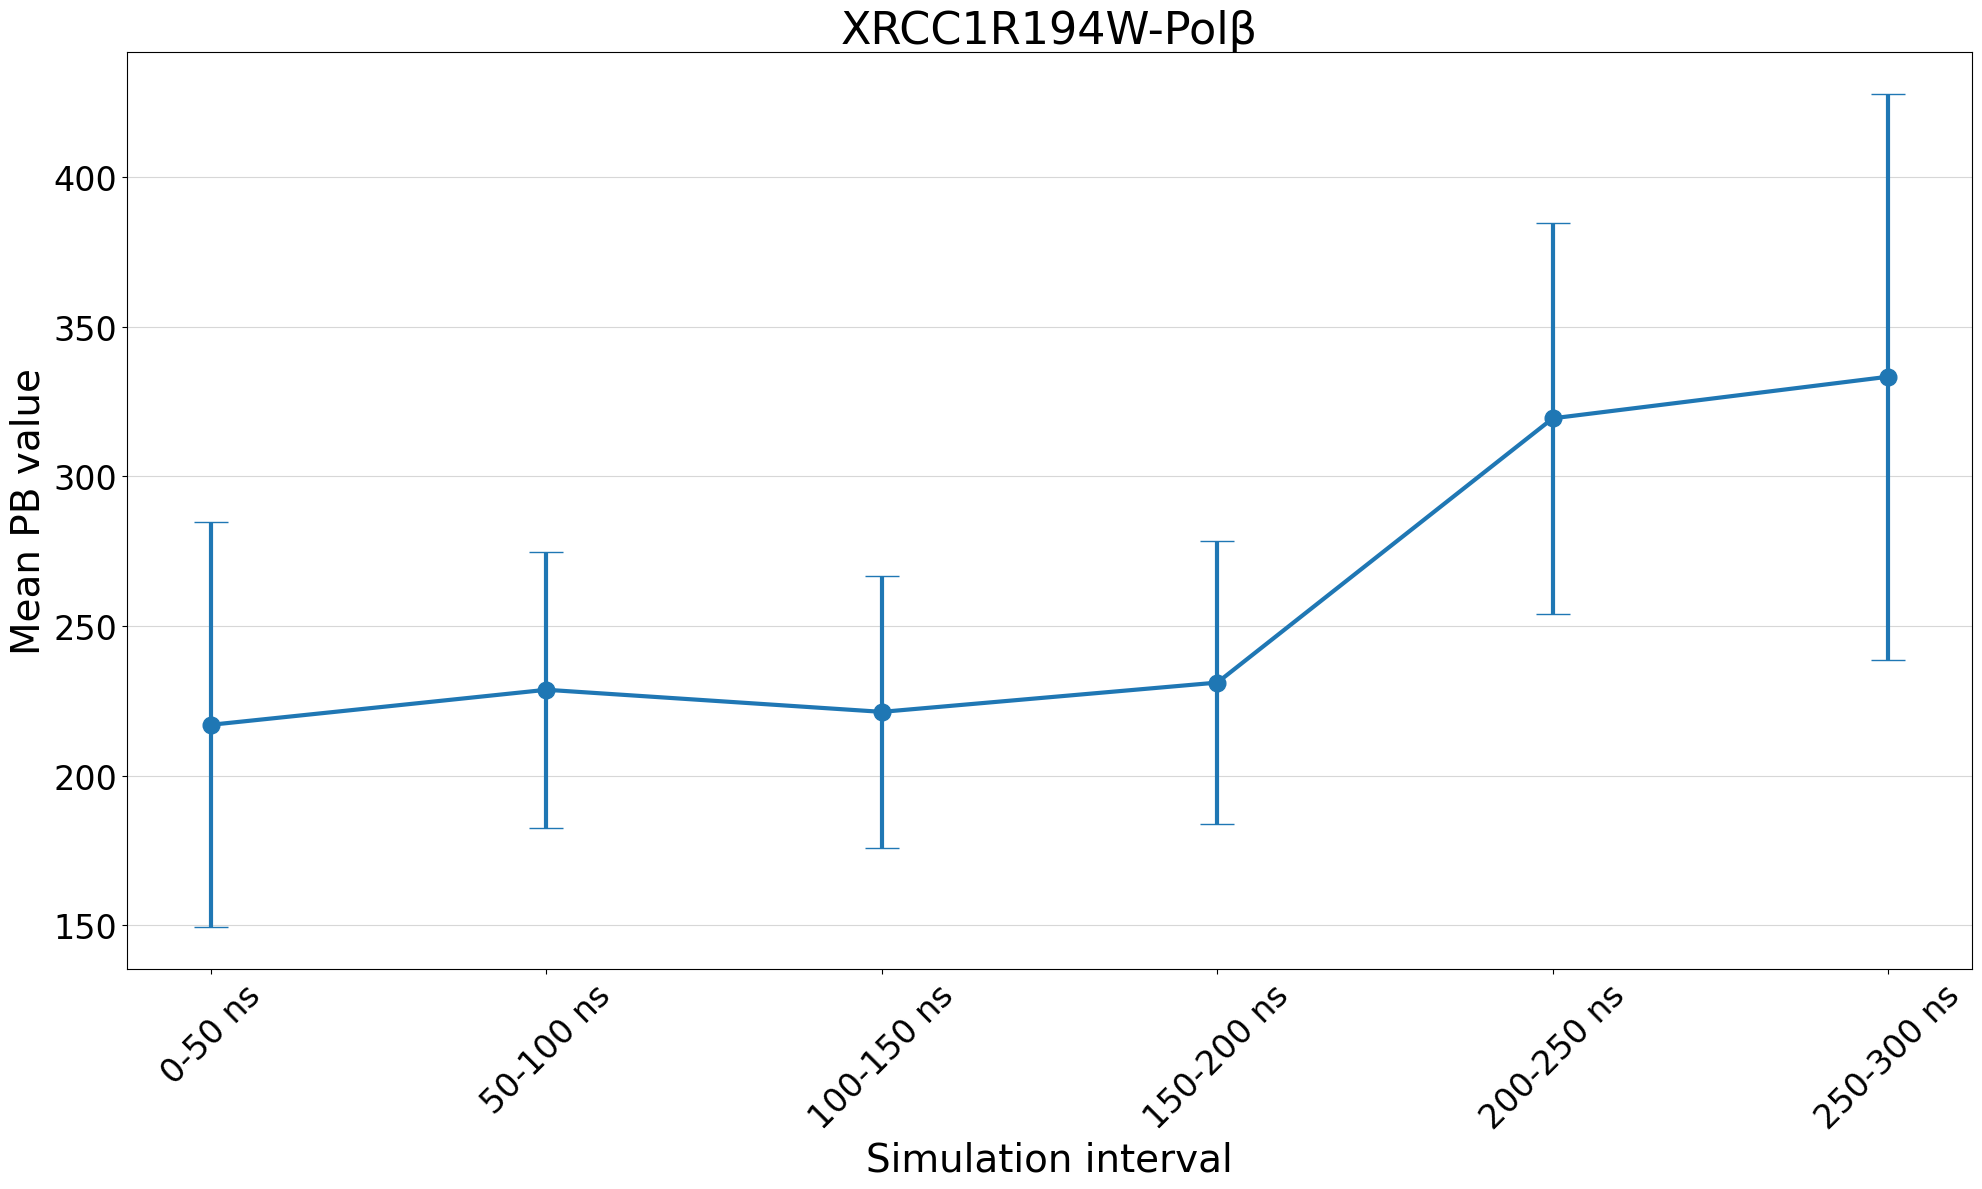

Saved: /home/naba/projects/results/XRCC1R194W-Pol_PB_block_analysis.png


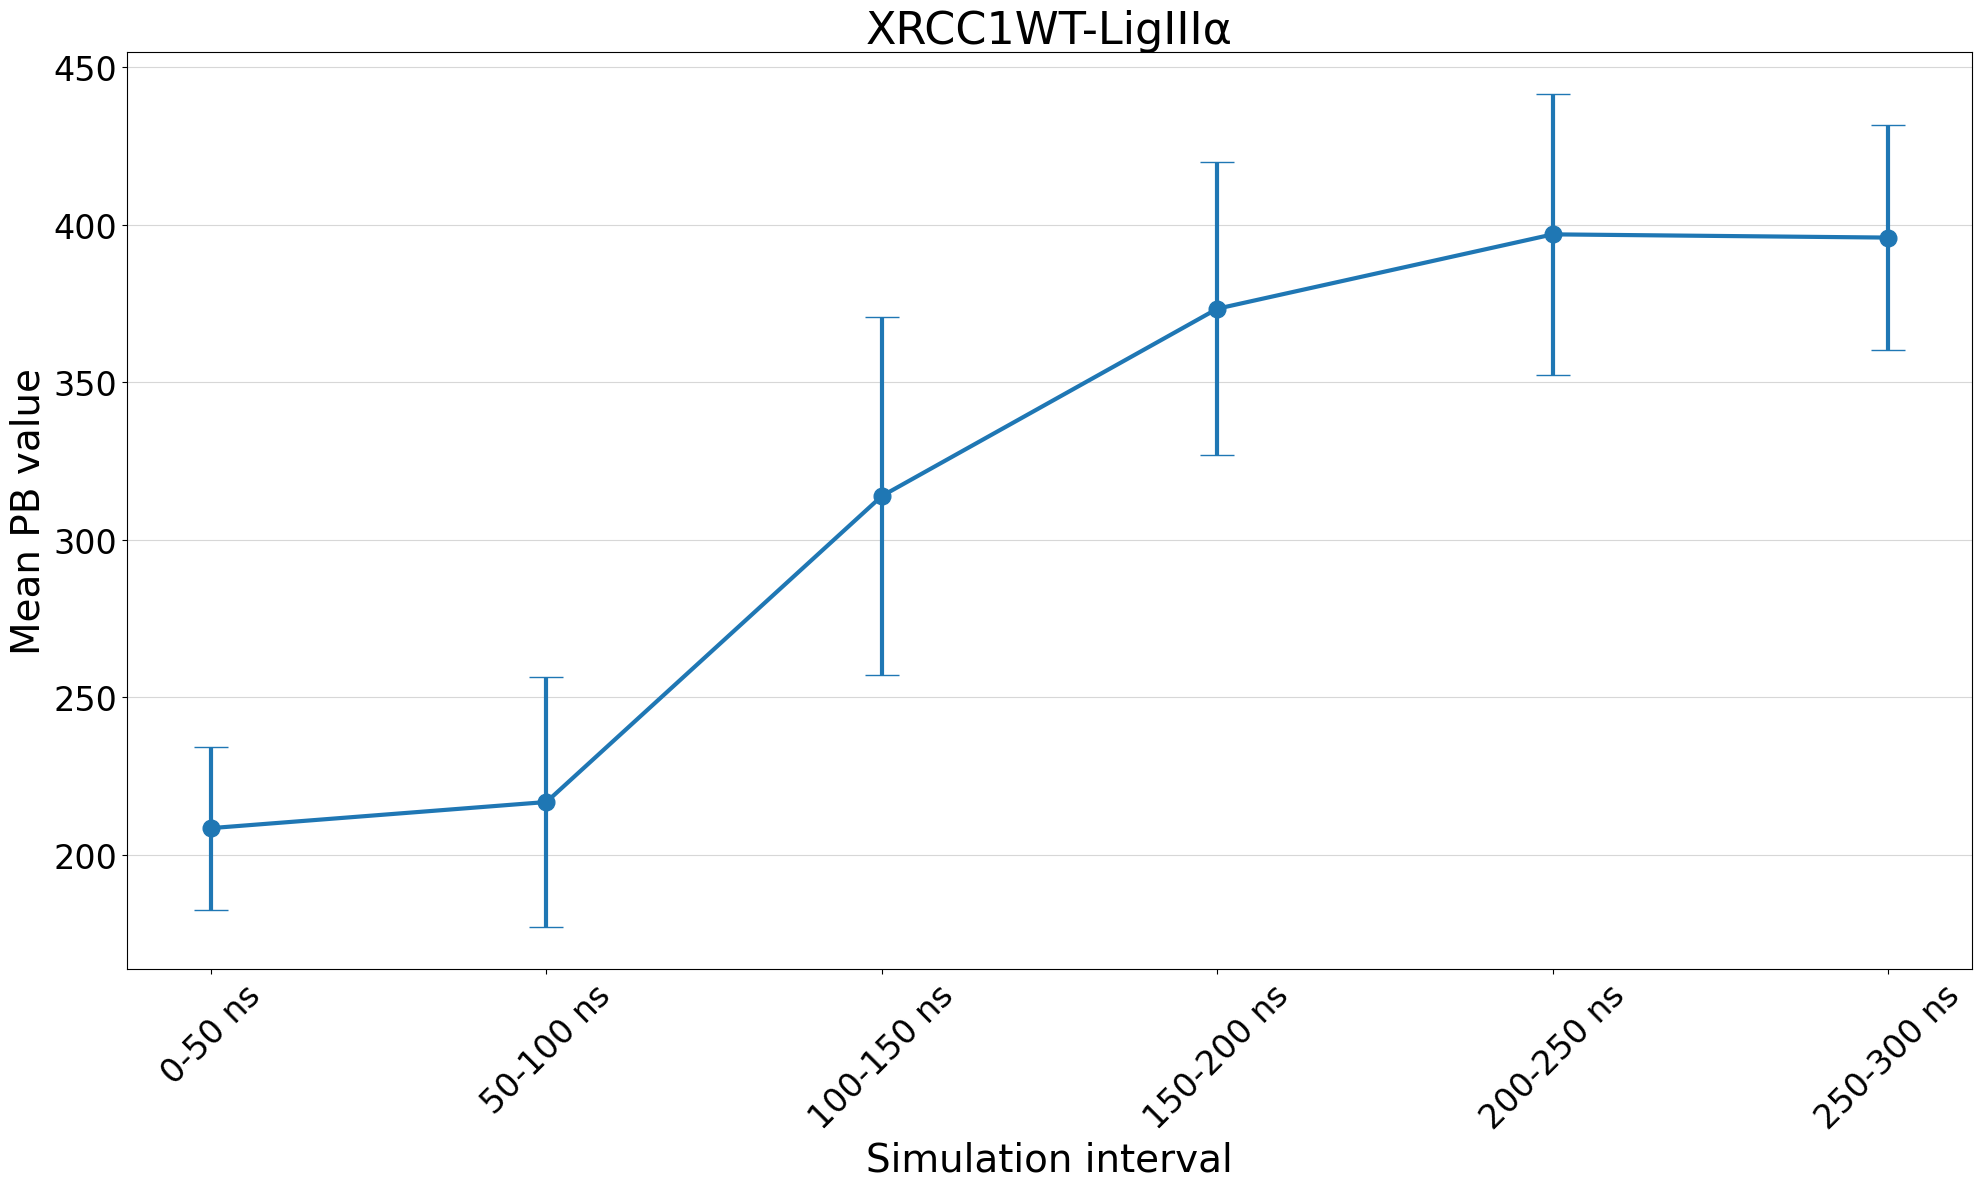

Saved: /home/naba/projects/results/XRCC1WT-LigIII_PB_block_analysis.png


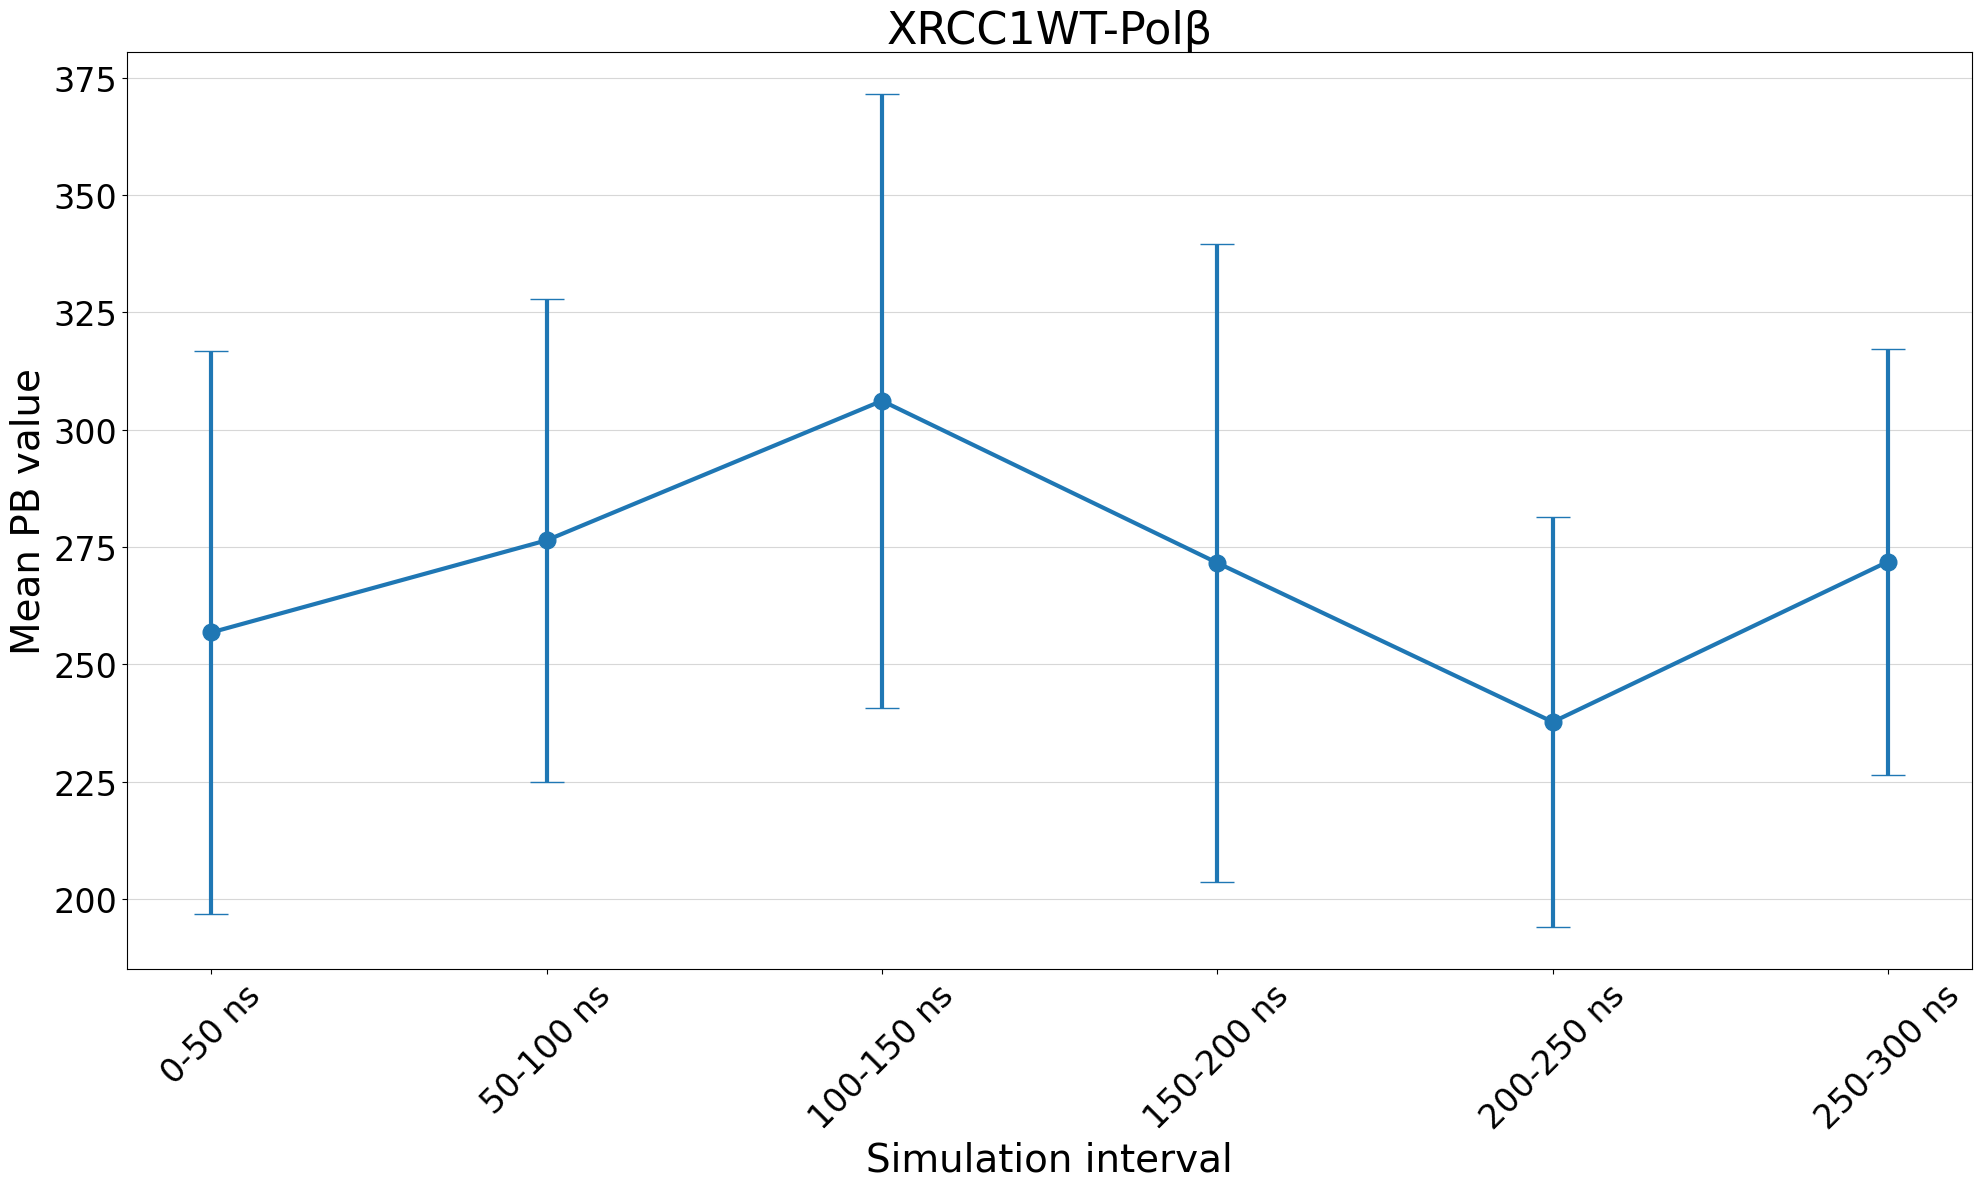

Saved: /home/naba/projects/results/XRCC1WT-Pol_PB_block_analysis.png


In [9]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_DIR = Path("/home/naba/projects")
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

result_files = sorted(PROJECT_DIR.glob("PB*_block_statistics.xlsx"))
if not result_files:
    raise FileNotFoundError(
        "No PB block-statistics Excel file found. Run block_analysis-PB.py first."
    )

results_df = pd.read_excel(result_files[0])
block_order = [
    "0-50 ns",
    "50-100 ns",
    "100-150 ns",
    "150-200 ns",
    "200-250 ns",
    "250-300 ns",
]

results_df = results_df.copy()
results_df["Block"] = pd.Categorical(
    results_df["Block"],
    categories=block_order,
    ordered=True,
)
systems = results_df["System"].dropna().unique()

for system in systems:
    temp = results_df[results_df["System"] == system].sort_values("Block")

    plt.figure(figsize=(20, 12))
    plt.errorbar(
        temp["Block"],
        temp["Mean"],
        yerr=temp["SD"],
        marker="o",
        markersize=12,
        capsize=12,
        linewidth=3,
    )
    plt.xlabel("Simulation interval", fontsize=28)
    plt.ylabel("Mean PB value", fontsize=28)
    plt.title(str(system), fontsize=32)
    plt.xticks(rotation=45, fontsize=24)
    plt.yticks(fontsize=24)
    plt.grid(axis="y", alpha=0.5)
    plt.tight_layout()

    filename = re.sub(r"[^A-Za-z0-9_.-]+", "_", str(system)).strip("_")
    output_path = RESULTS_DIR / f"{filename}_PB_block_analysis.png"
    plt.savefig(output_path, dpi=1200, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"Saved: {output_path}")

Comparison plot

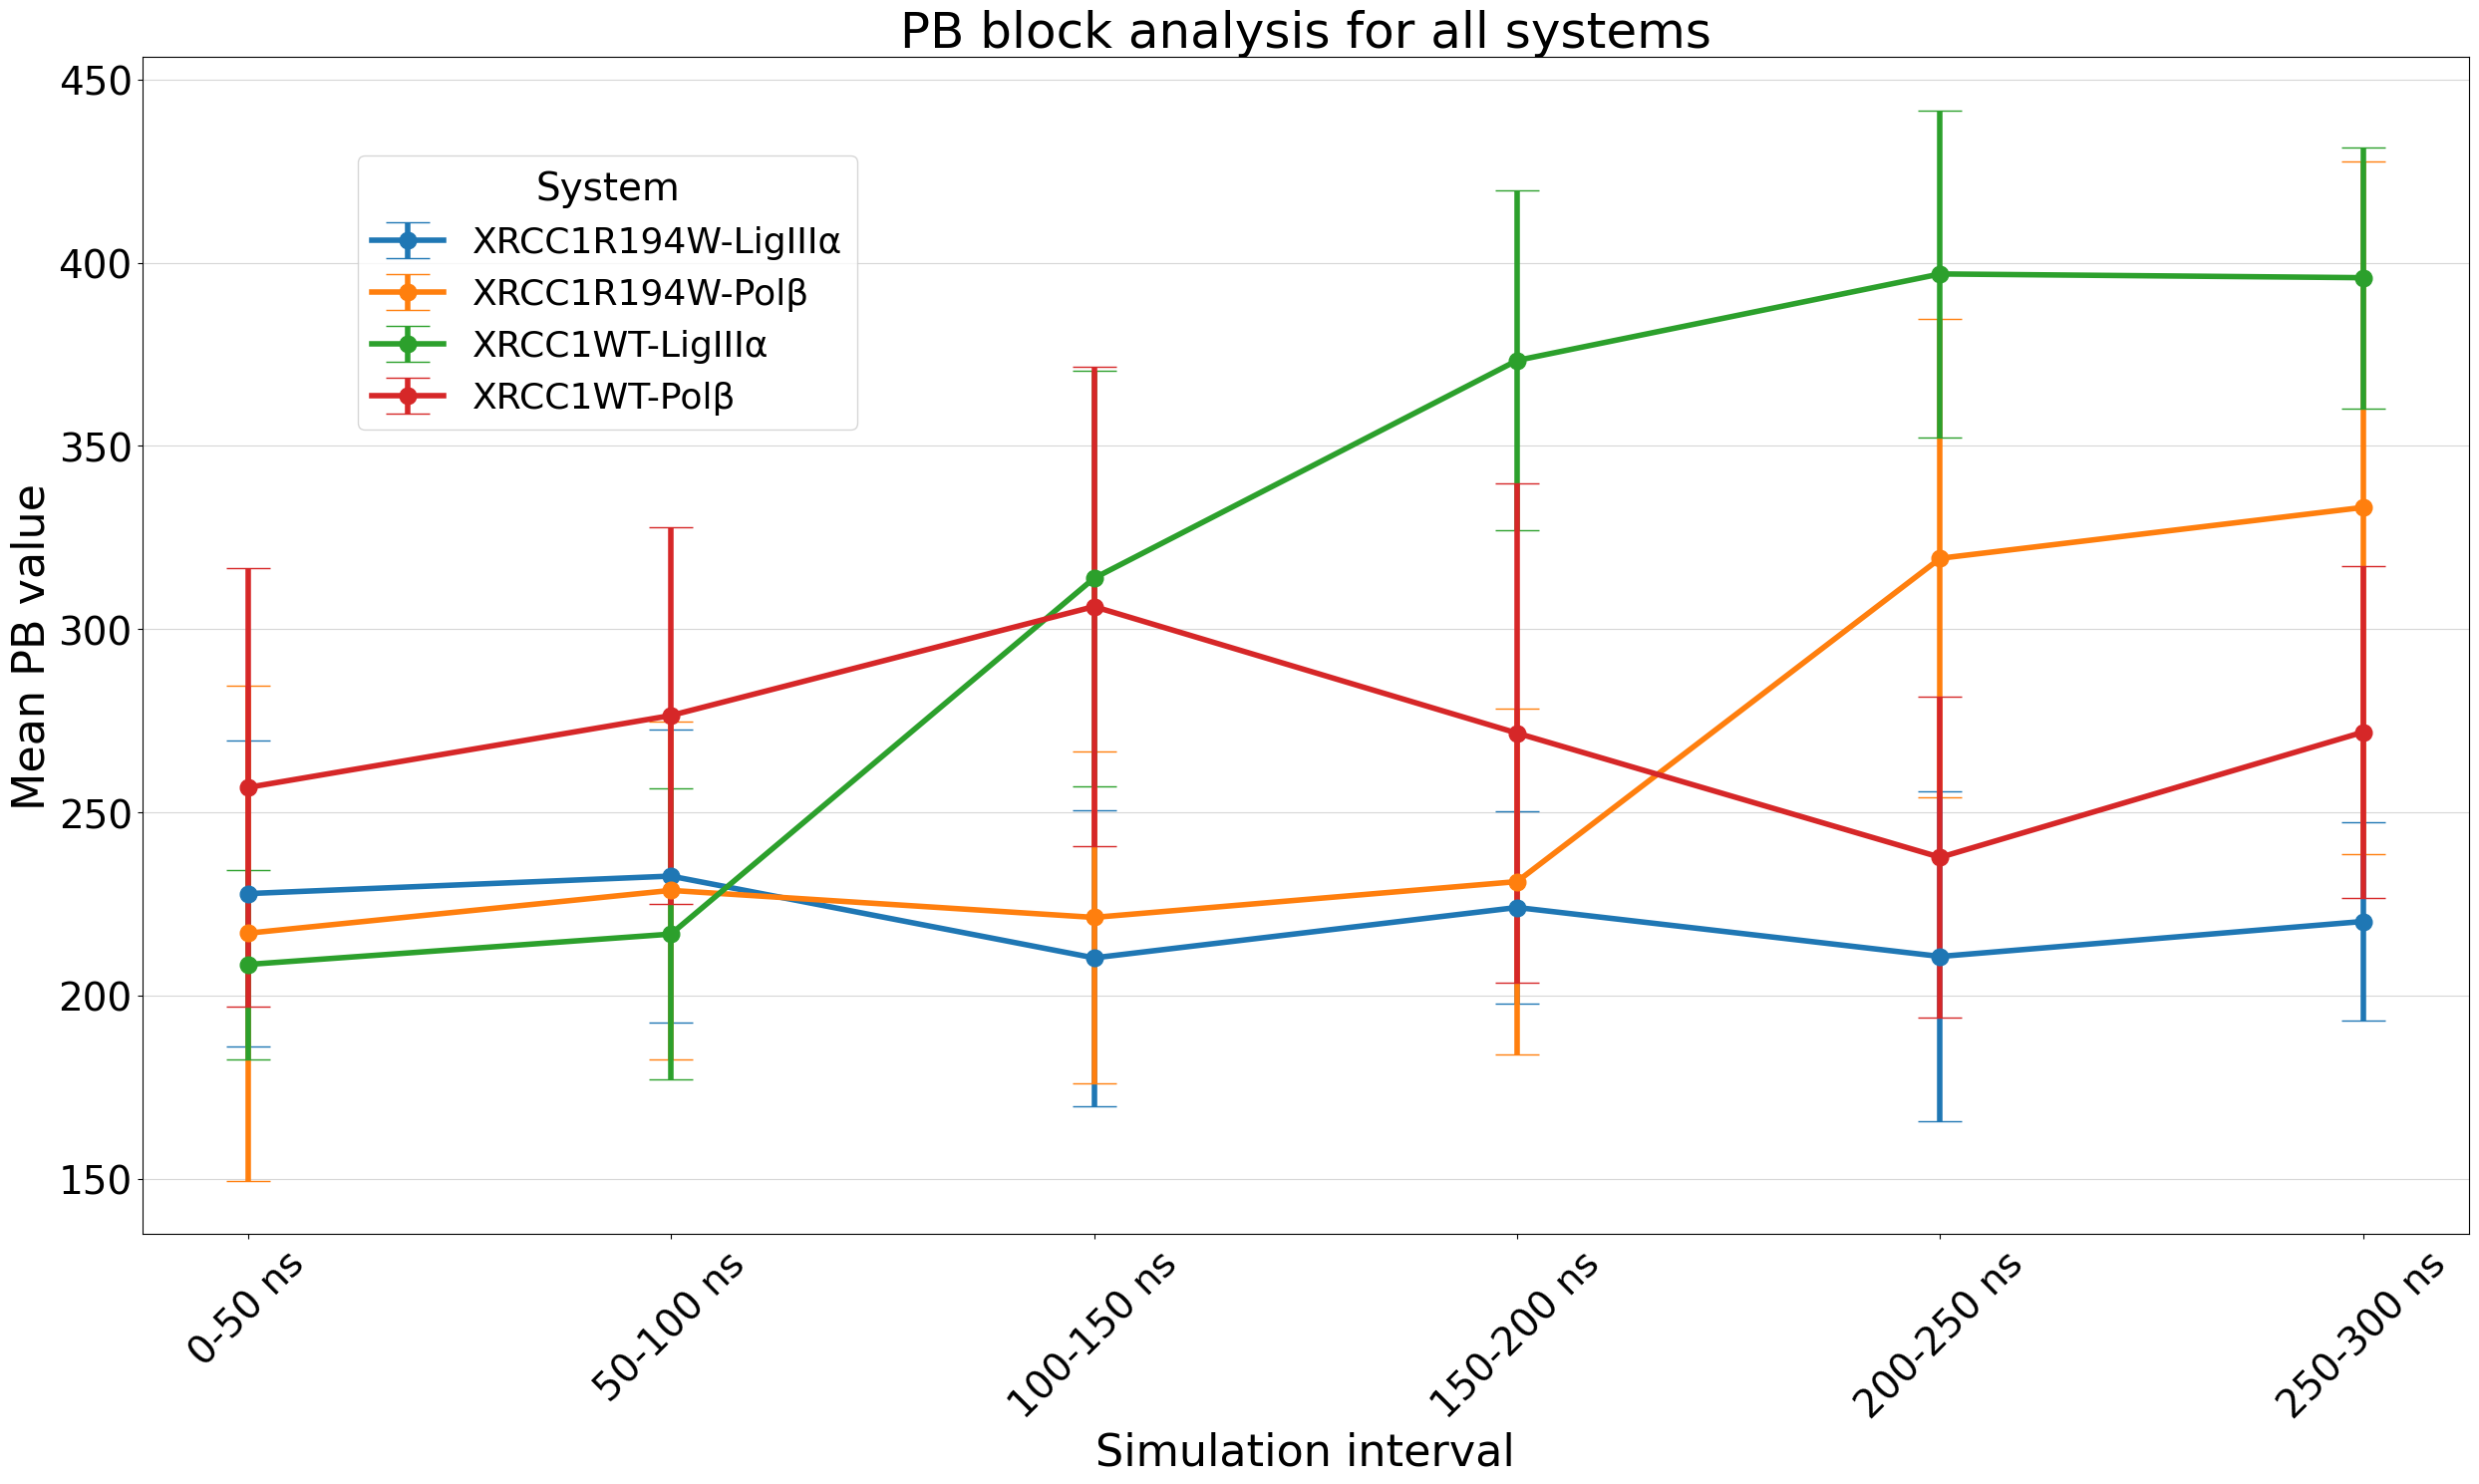

Saved: /home/naba/projects/results/all_systems_PB_block_analysis.png


In [11]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

PROJECT_DIR = Path("/home/naba/projects")
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

result_files = sorted(PROJECT_DIR.glob("PB*_block_statistics.xlsx"))
if not result_files:
    raise FileNotFoundError(
        "No PB block-statistics Excel file found. Run block_analysis-PB.py first."
    )

results_df = pd.read_excel(result_files[0])
block_order = [
    "0-50 ns",
    "50-100 ns",
    "100-150 ns",
    "150-200 ns",
    "200-250 ns",
    "250-300 ns",
]

results_df = results_df.copy()
results_df["Block"] = pd.Categorical(
    results_df["Block"],
    categories=block_order,
    ordered=True,
)
systems = results_df["System"].dropna().unique()
block_positions = range(len(block_order))

# Change these two values to move the legend box.
# x: 0 = left, 1 = right; y: 0 = bottom, 1 = top.
legend_position = (0.2, 0.8)

plt.figure(figsize=(25, 15))

for system in systems:
    temp = results_df[results_df["System"] == system].sort_values("Block")
    plt.errorbar(
        block_positions,
        temp["Mean"],
        yerr=temp["SD"],
        marker="o",
        markersize=12,
        capsize=16,
        linewidth=4,
        label=str(system),
    )

plt.xlabel("Simulation interval", fontsize=32)
plt.ylabel("Mean PB value", fontsize=32)
plt.title("PB block analysis for all systems", fontsize=36)
plt.xticks(list(block_positions), block_order, rotation=45, fontsize=28)
plt.yticks(fontsize=28)
plt.legend(
    title="System",
    title_fontsize=28,
    fontsize=26,
    loc="center",
    bbox_to_anchor=legend_position,
)
plt.grid(axis="y", alpha=0.5)
plt.tight_layout()

output_path = RESULTS_DIR / "all_systems_PB_block_analysis.png"
plt.savefig(output_path, dpi=1200, bbox_inches="tight")
plt.show()
plt.close()

print(f"Saved: {output_path}")

SA Block Analysis

In [12]:
!python block_analysis-SA.py


Selected input file:
/home/naba/projects/SA-WT-replicate-and-R194W.xlsx

Time column: Time
Time values are interpreted directly in ns.

Systems detected:
 - XRCC1WT-LigIIIα
 - XRCC1WT-Polβ
 - XRCC1R194W-LigIIIα
 - XRCC1R194W-Polβ

Block analysis completed successfully.
Output saved to:
/home/naba/projects/SA-WT-replicate-and-R194W_block_statistics.xlsx

Results:

            System      Block   N       Mean        SD     Min     Max
XRCC1R194W-LigIIIα    0-50 ns 100 -42.135970  4.970973 -50.193 -26.273
XRCC1R194W-LigIIIα  50-100 ns 100 -42.663010  3.668295 -50.951 -33.030
XRCC1R194W-LigIIIα 100-150 ns 100 -31.456020  3.489285 -42.294 -24.677
XRCC1R194W-LigIIIα 150-200 ns 100 -31.875210  3.376510 -39.256 -21.945
XRCC1R194W-LigIIIα 200-250 ns 100 -31.193190  2.921736 -38.953 -23.083
XRCC1R194W-LigIIIα 250-300 ns 101 -31.524327  2.801798 -39.334 -24.905
   XRCC1R194W-Polβ    0-50 ns 100 -39.103050  5.418691 -51.559 -20.883
   XRCC1R194W-Polβ  50-100 ns 100 -42.069510  5.370321 -57.025 -2

SA-Plots

4 Plots

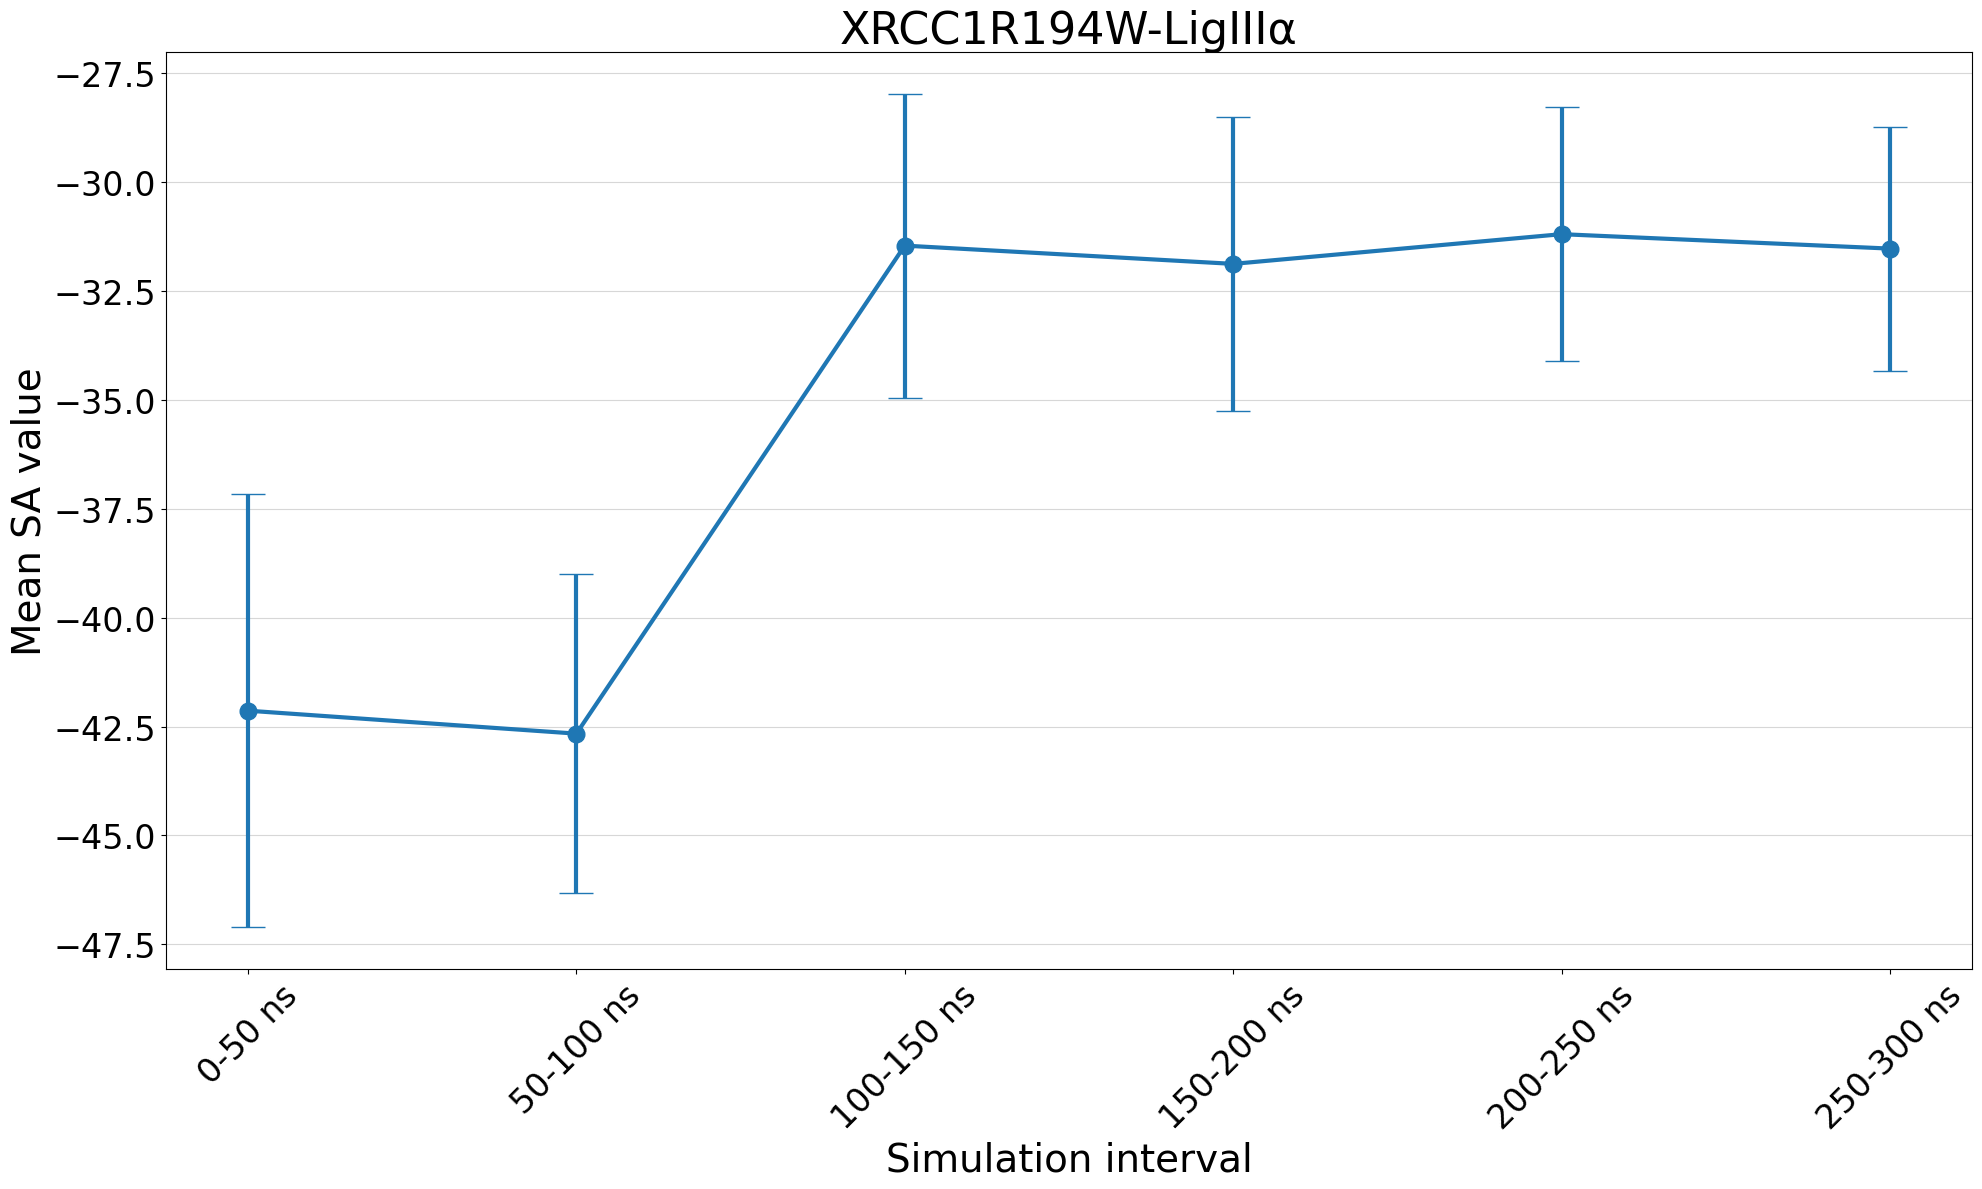

Saved: /home/naba/projects/results/XRCC1R194W-LigIII_SA_block_analysis.png


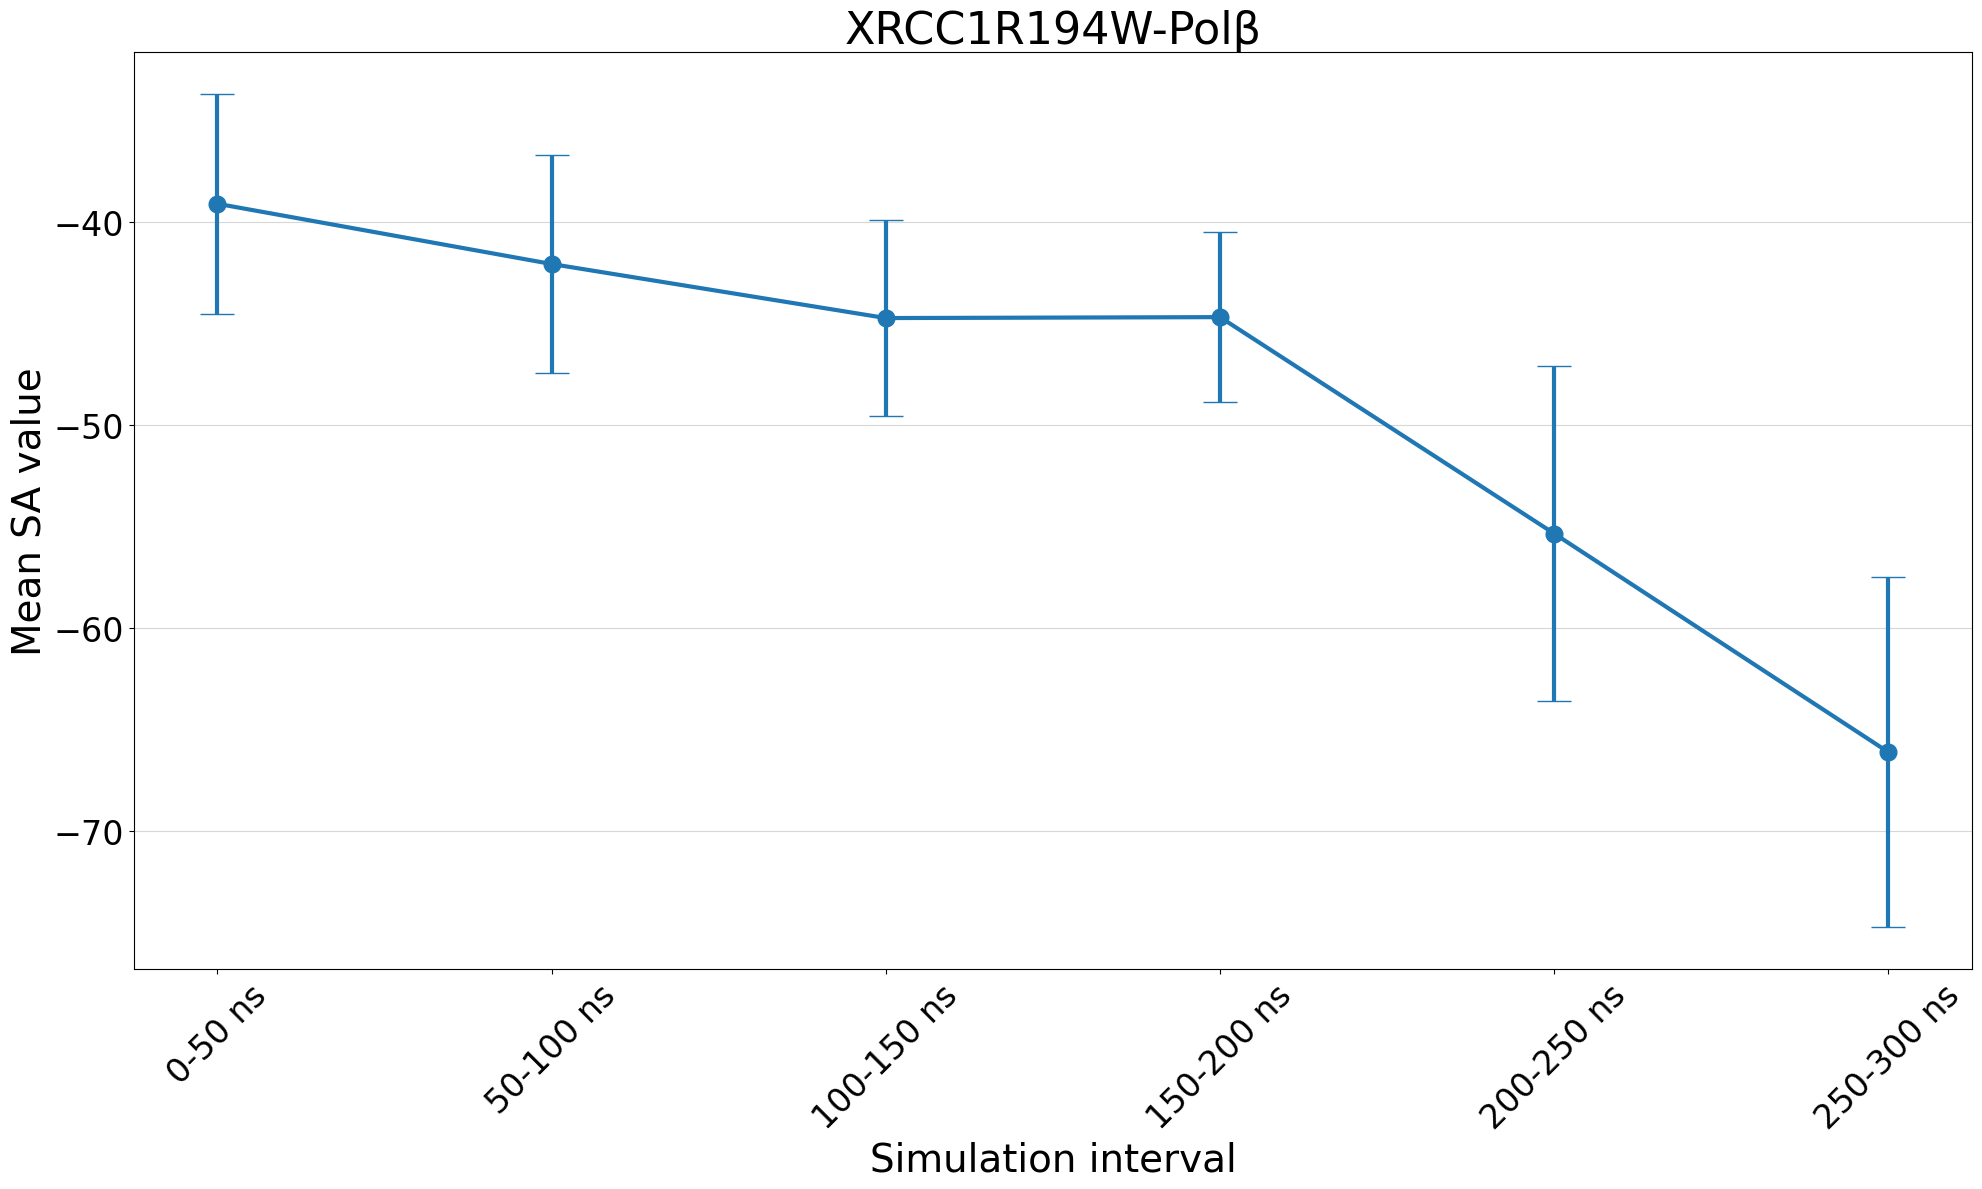

Saved: /home/naba/projects/results/XRCC1R194W-Pol_SA_block_analysis.png


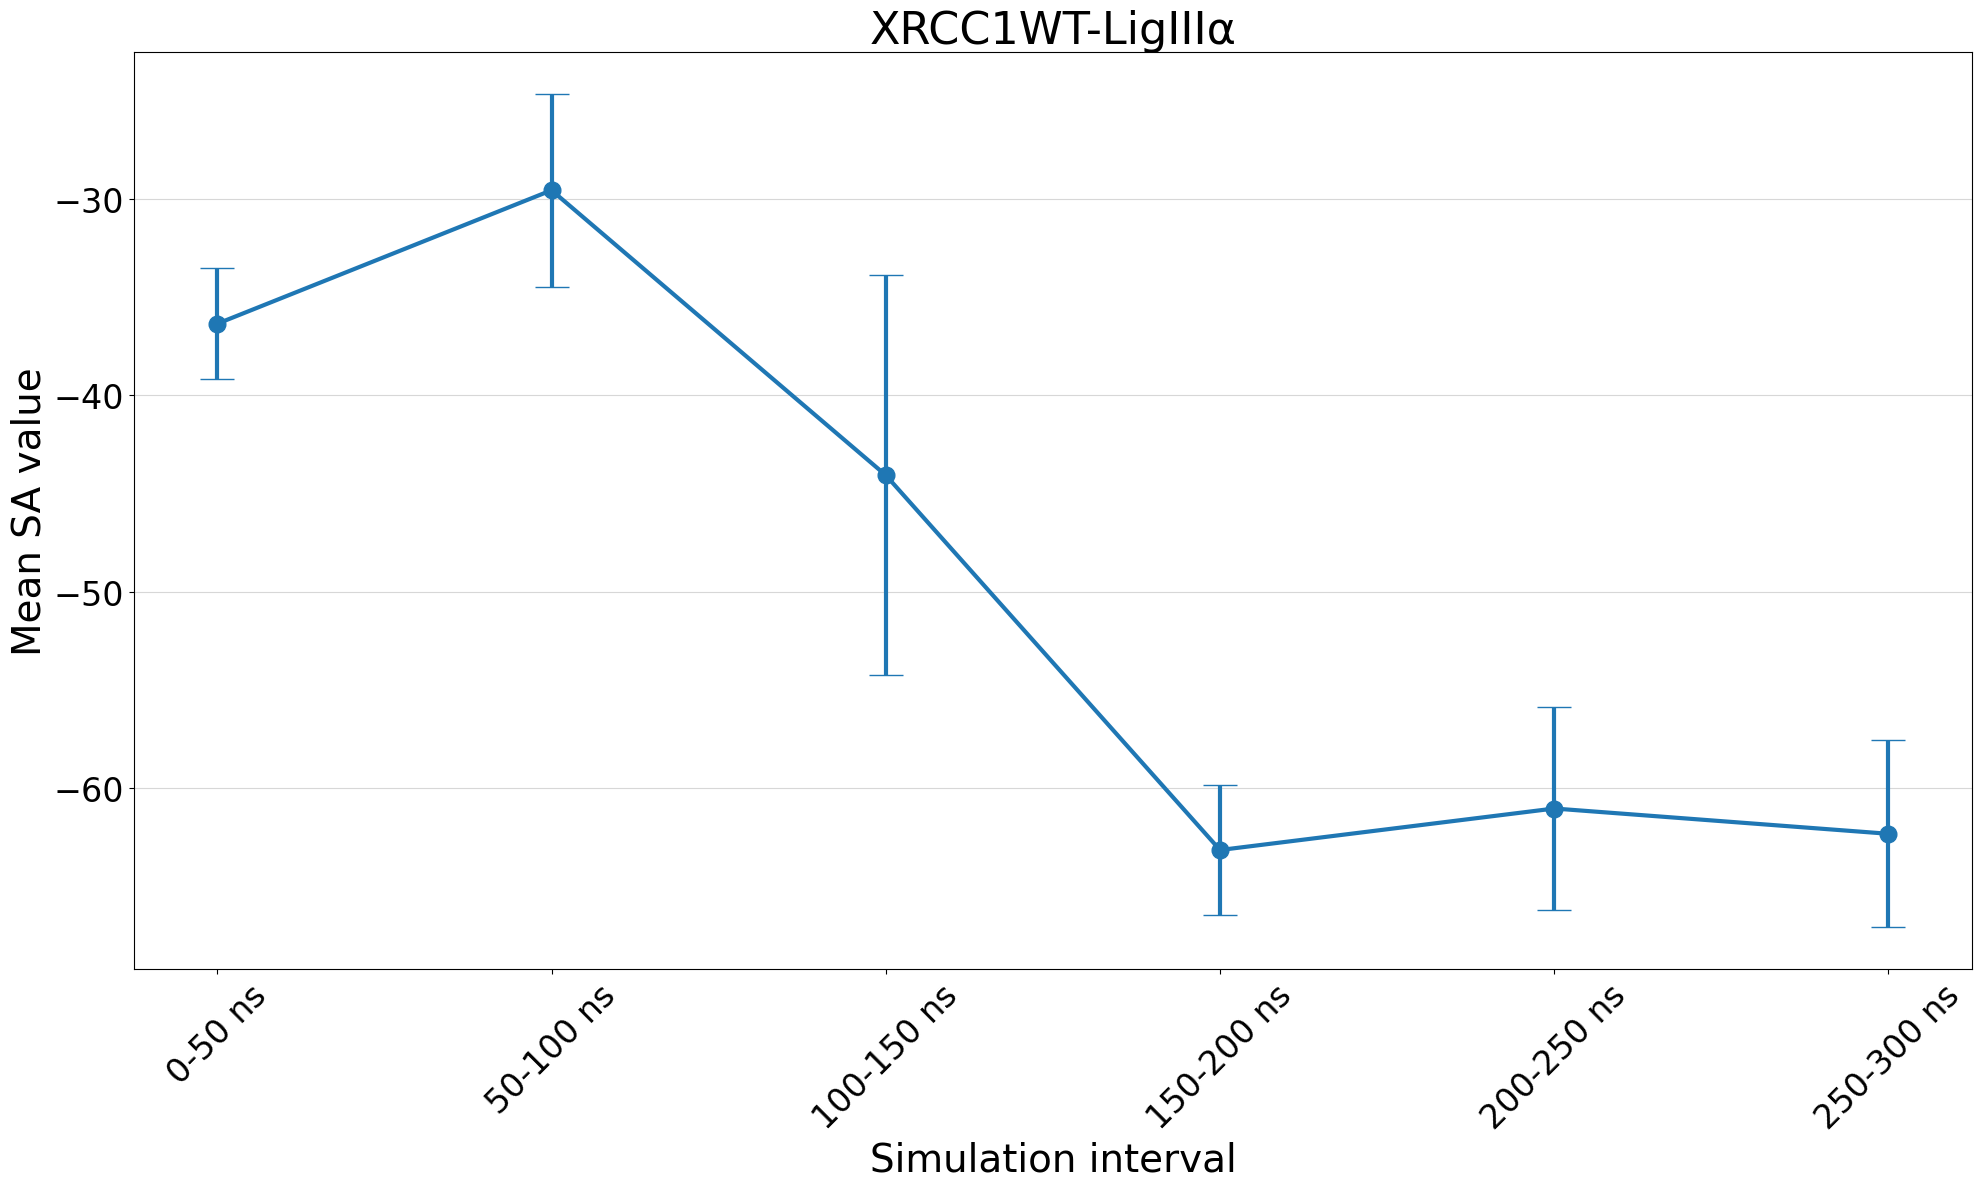

Saved: /home/naba/projects/results/XRCC1WT-LigIII_SA_block_analysis.png


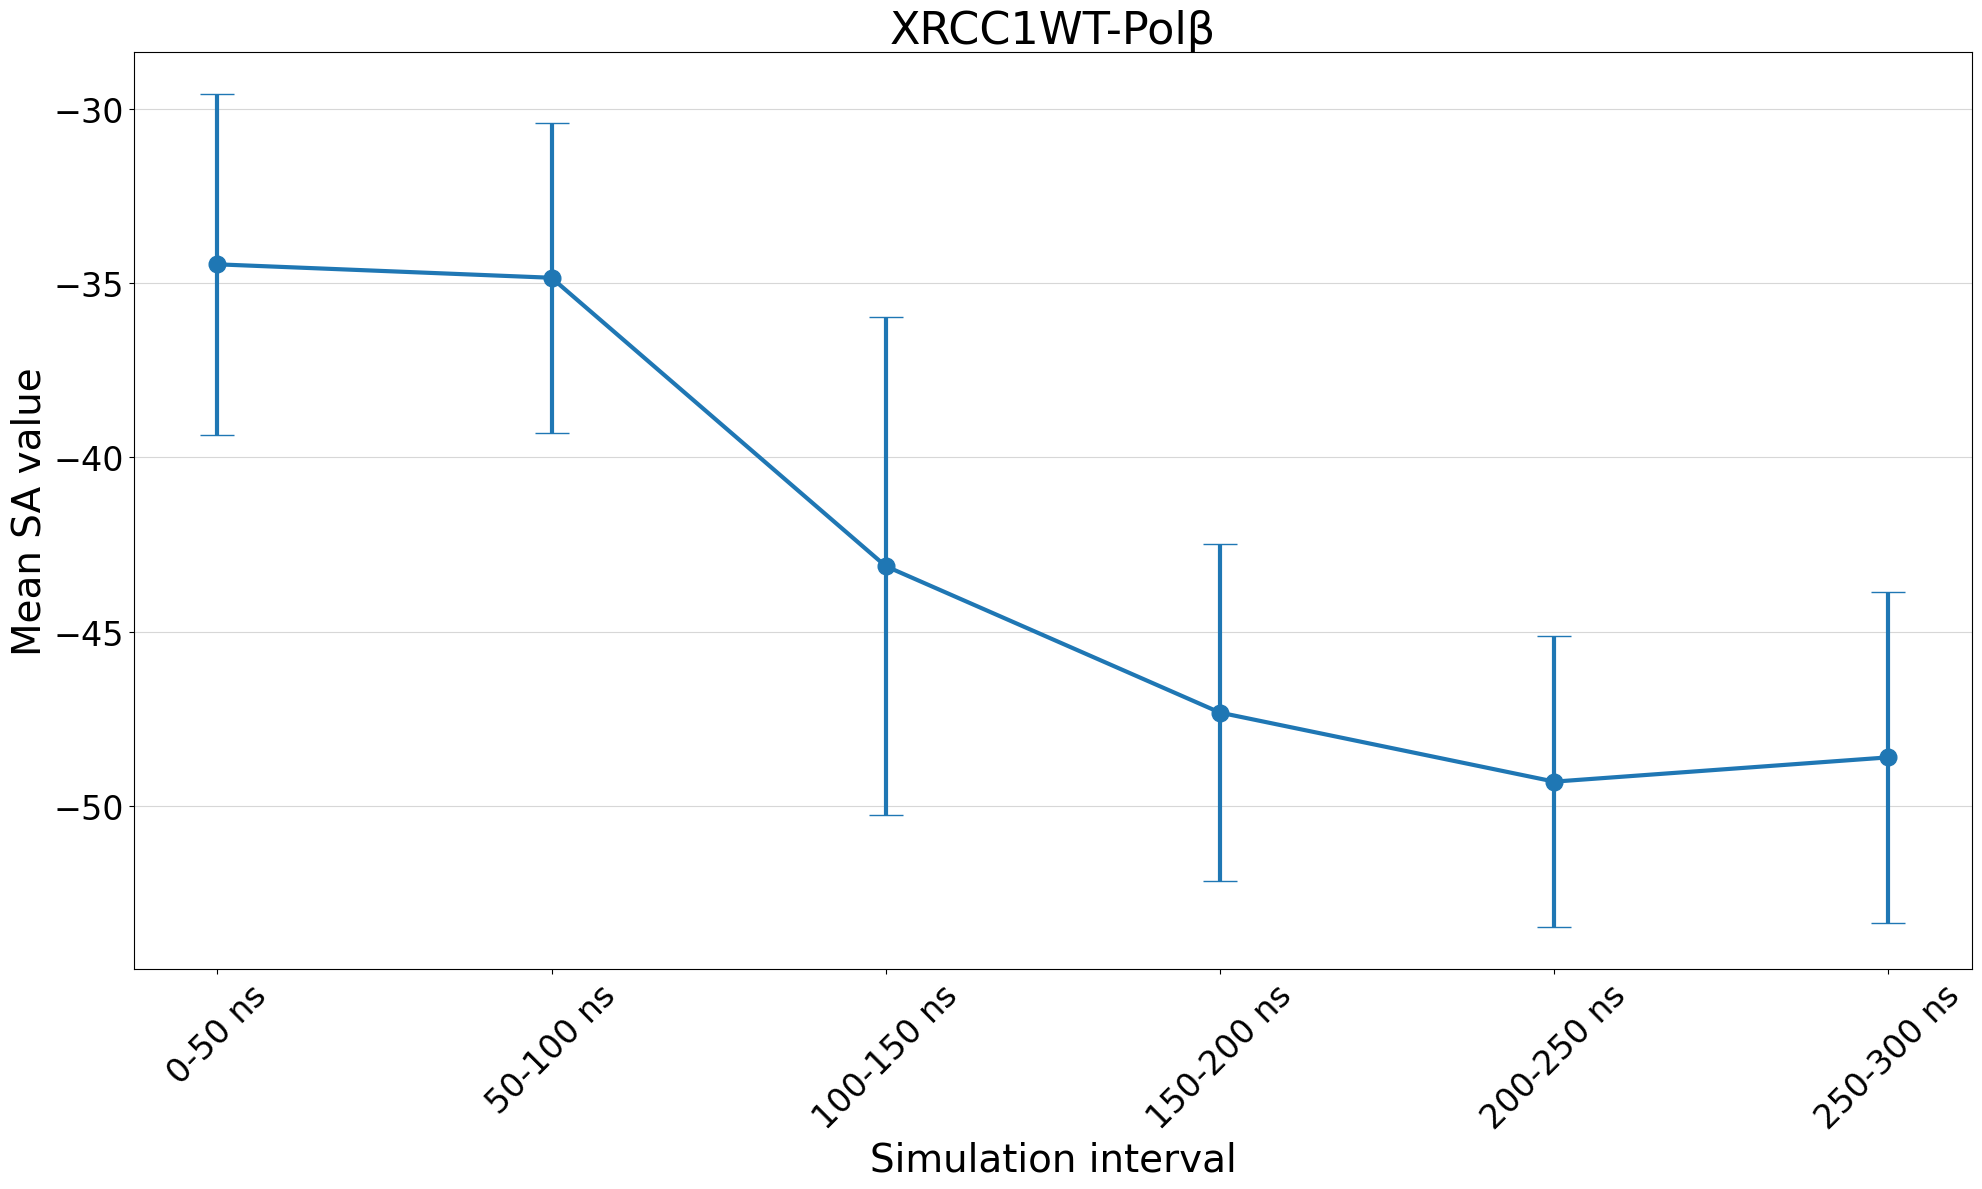

Saved: /home/naba/projects/results/XRCC1WT-Pol_SA_block_analysis.png


In [13]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_DIR = Path("/home/naba/projects")
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

result_files = sorted(PROJECT_DIR.glob("SA-WT-*_block_statistics.xlsx"))
if not result_files:
    raise FileNotFoundError(
        "No SA block-statistics Excel file found. Run block_analysis-SA.py first."
    )

results_df = pd.read_excel(result_files[0])
block_order = [
    "0-50 ns",
    "50-100 ns",
    "100-150 ns",
    "150-200 ns",
    "200-250 ns",
    "250-300 ns",
]

results_df = results_df.copy()
results_df["Block"] = pd.Categorical(
    results_df["Block"],
    categories=block_order,
    ordered=True,
)
systems = results_df["System"].dropna().unique()

for system in systems:
    temp = results_df[results_df["System"] == system].sort_values("Block")

    plt.figure(figsize=(20, 12))
    plt.errorbar(
        temp["Block"],
        temp["Mean"],
        yerr=temp["SD"],
        marker="o",
        markersize=12,
        capsize=12,
        linewidth=3,
    )
    plt.xlabel("Simulation interval", fontsize=28)
    plt.ylabel("Mean SA value", fontsize=28)
    plt.title(str(system), fontsize=32)
    plt.xticks(rotation=45, fontsize=24)
    plt.yticks(fontsize=24)
    plt.grid(axis="y", alpha=0.5)
    plt.tight_layout()

    filename = re.sub(r"[^A-Za-z0-9_.-]+", "_", str(system)).strip("_")
    output_path = RESULTS_DIR / f"{filename}_SA_block_analysis.png"
    plt.savefig(output_path, dpi=1200, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"Saved: {output_path}")

Comparison plot

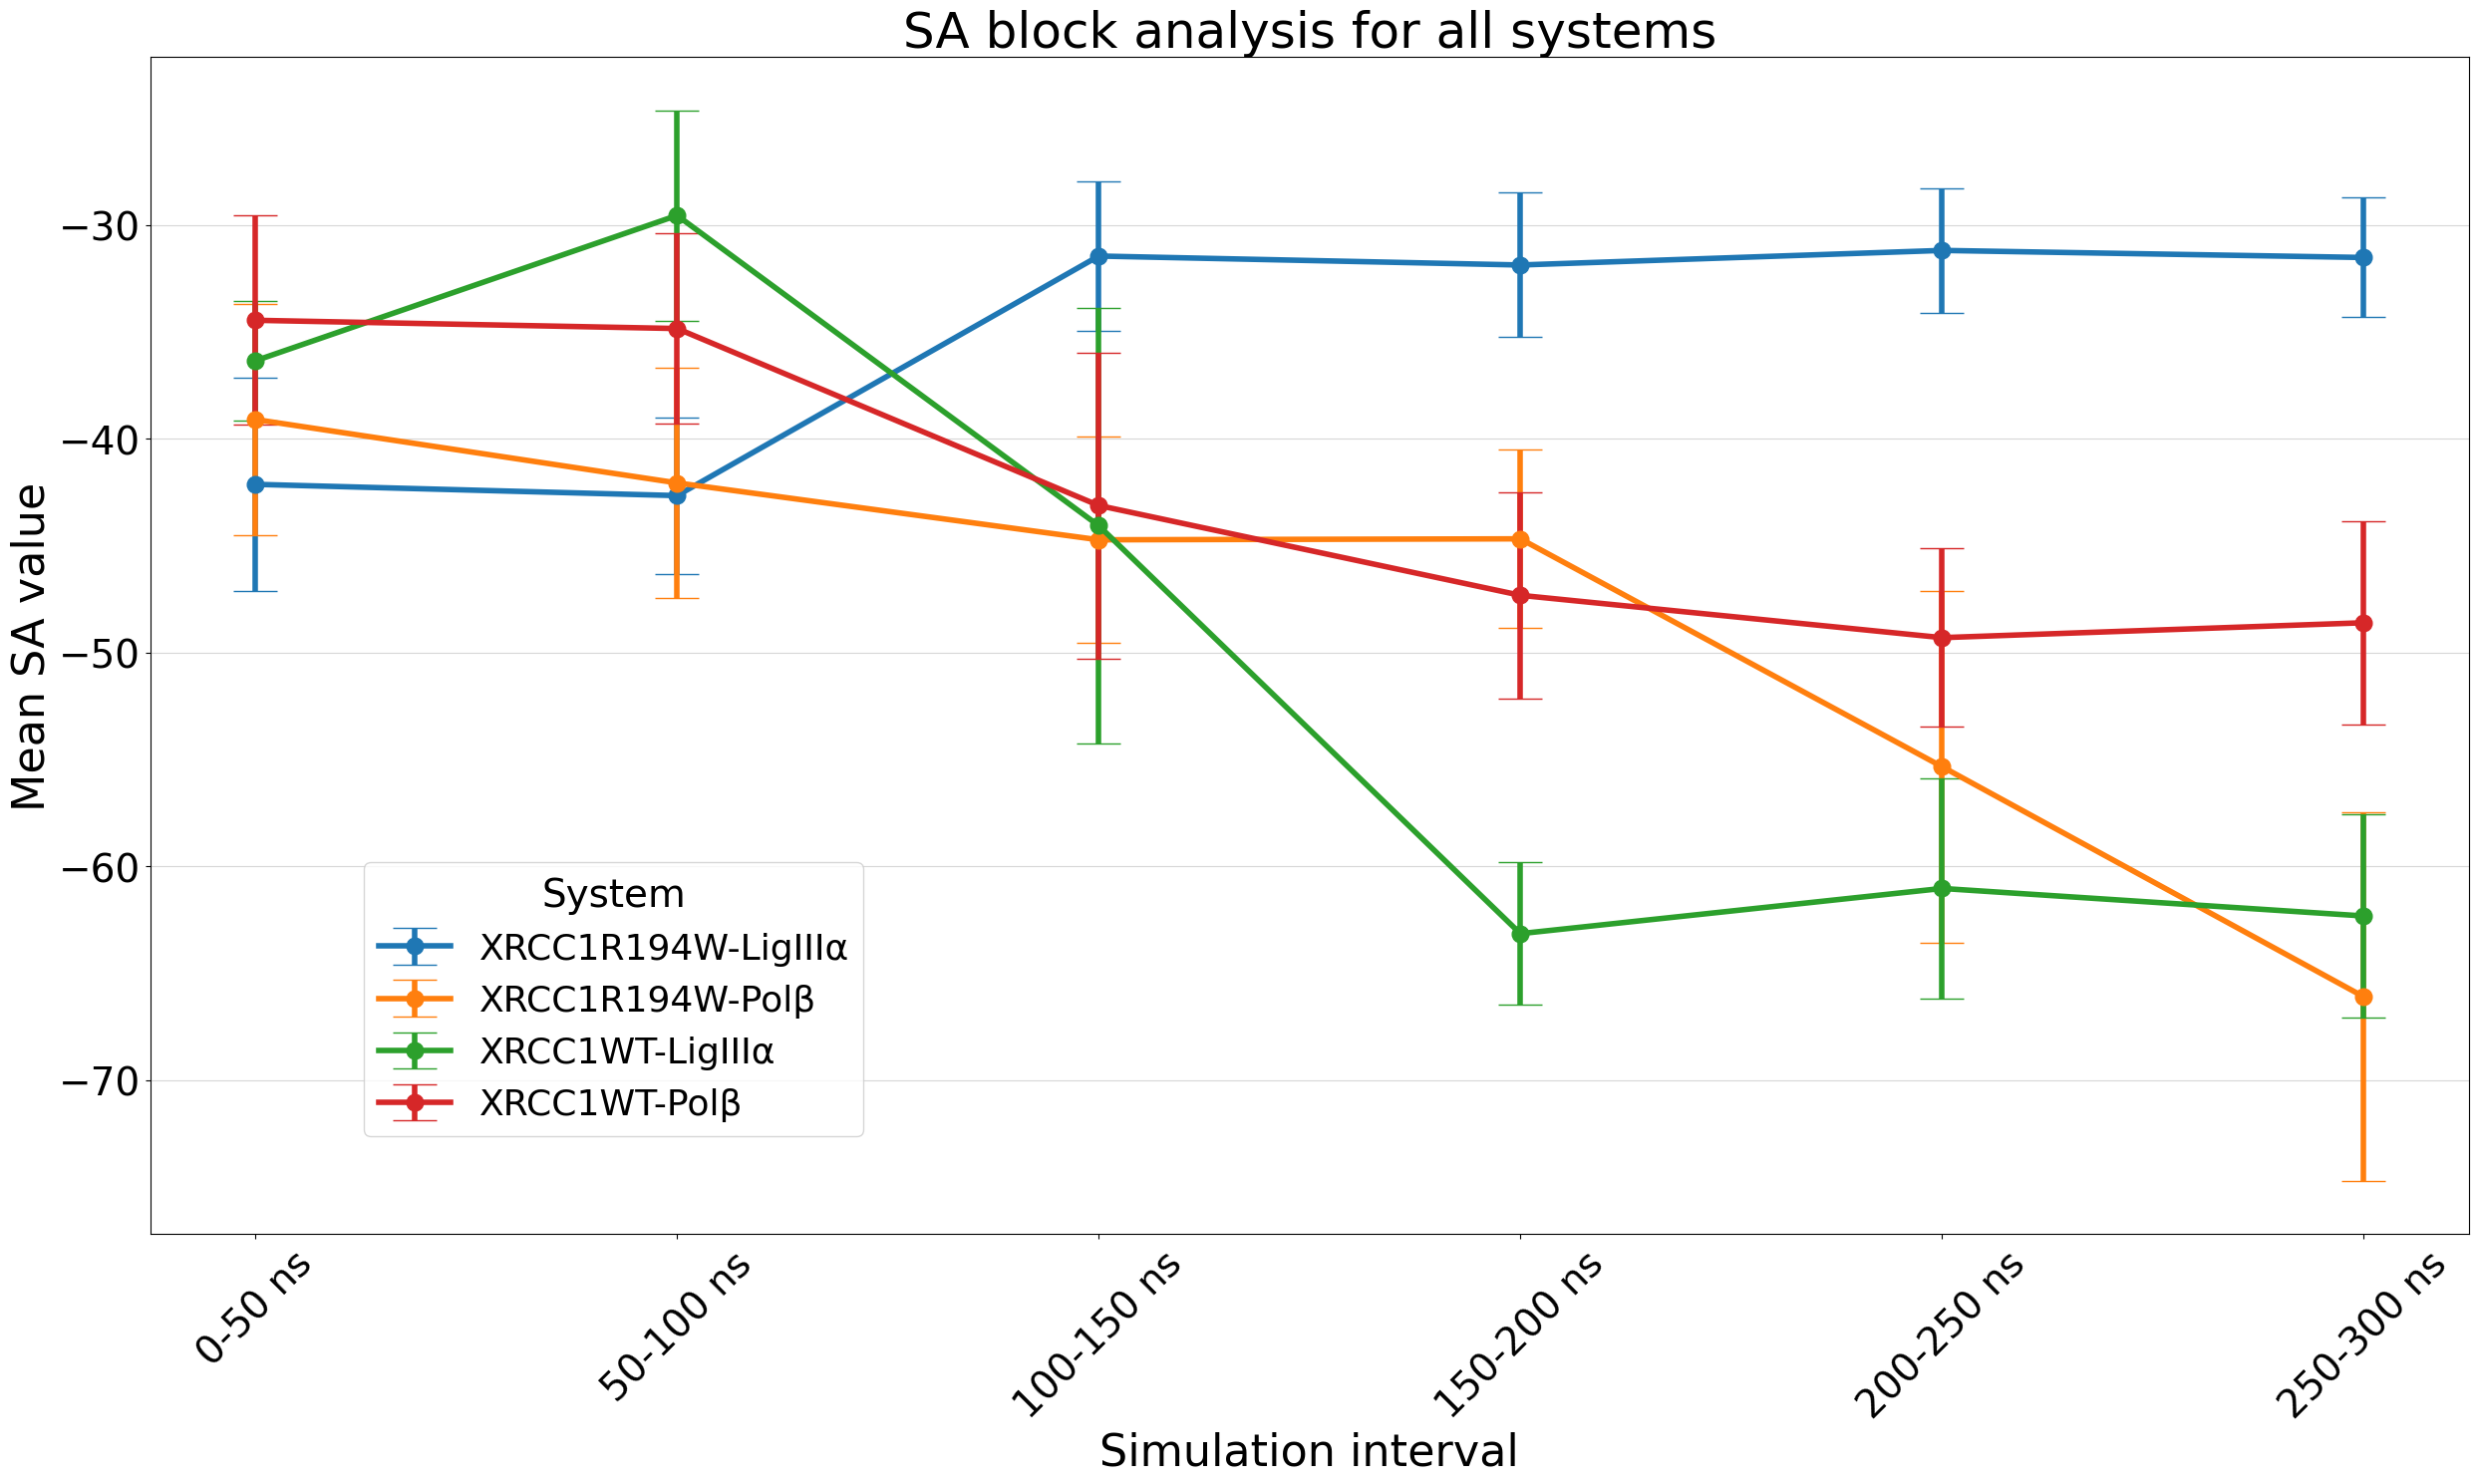

Saved: /home/naba/projects/results/all_systems_SA_block_analysis.png


In [14]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

PROJECT_DIR = Path("/home/naba/projects")
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

result_files = sorted(PROJECT_DIR.glob("SA-WT-*_block_statistics.xlsx"))
if not result_files:
    raise FileNotFoundError(
        "No SA block-statistics Excel file found. Run block_analysis-SA.py first."
    )

results_df = pd.read_excel(result_files[0])
block_order = [
    "0-50 ns",
    "50-100 ns",
    "100-150 ns",
    "150-200 ns",
    "200-250 ns",
    "250-300 ns",
]

results_df = results_df.copy()
results_df["Block"] = pd.Categorical(
    results_df["Block"],
    categories=block_order,
    ordered=True,
)
systems = results_df["System"].dropna().unique()
block_positions = range(len(block_order))

# Change these two values to move the legend box.
# x: 0 = left, 1 = right; y: 0 = bottom, 1 = top.
legend_position = (0.2, 0.2)

plt.figure(figsize=(25, 15))

for system in systems:
    temp = results_df[results_df["System"] == system].sort_values("Block")
    plt.errorbar(
        block_positions,
        temp["Mean"],
        yerr=temp["SD"],
        marker="o",
        markersize=12,
        capsize=16,
        linewidth=4,
        label=str(system),
    )

plt.xlabel("Simulation interval", fontsize=32)
plt.ylabel("Mean SA value", fontsize=32)
plt.title("SA block analysis for all systems", fontsize=36)
plt.xticks(list(block_positions), block_order, rotation=45, fontsize=28)
plt.yticks(fontsize=28)
plt.legend(
    title="System",
    title_fontsize=28,
    fontsize=26,
    loc="center",
    bbox_to_anchor=legend_position,
)
plt.grid(axis="y", alpha=0.5)
plt.tight_layout()

output_path = RESULTS_DIR / "all_systems_SA_block_analysis.png"
plt.savefig(output_path, dpi=1200, bbox_inches="tight")
plt.show()
plt.close()

print(f"Saved: {output_path}")

ΔGbind Block Analysis

In [15]:
!python block_analysis-bind.py


Selected input file:
/home/naba/projects/ΔGbind-WT-replicate-and-R194W.xlsx

Time column: Time
Time values are interpreted directly in ns.

Systems detected:
 - XRCC1WT-LigIIIα
 - XRCC1WT-Polβ
 - XRCC1R194W-LigIIIα
 - XRCC1R194W-Polβ

Block analysis completed successfully.
Output saved to:
/home/naba/projects/ΔGbind-WT-replicate-and-R194W_block_statistics.xlsx

Results:

            System      Block   N        Mean        SD      Min     Max
XRCC1R194W-LigIIIα    0-50 ns 100 -112.733610 45.050859 -204.003  21.439
XRCC1R194W-LigIIIα  50-100 ns 100 -129.787960 51.476720 -227.471   4.144
XRCC1R194W-LigIIIα 100-150 ns 100  -79.094810 52.136000 -188.824  66.074
XRCC1R194W-LigIIIα 150-200 ns 100  -57.018610 36.160081 -156.680   7.619
XRCC1R194W-LigIIIα 200-250 ns 100  -72.048310 51.451624 -190.452  69.938
XRCC1R194W-LigIIIα 250-300 ns 101  -67.207545 32.951300 -155.369  43.970
   XRCC1R194W-Polβ    0-50 ns 100  -68.724720 64.518652 -189.965  88.783
   XRCC1R194W-Polβ  50-100 ns 100  -78.42

bind-Plots

4 Plots

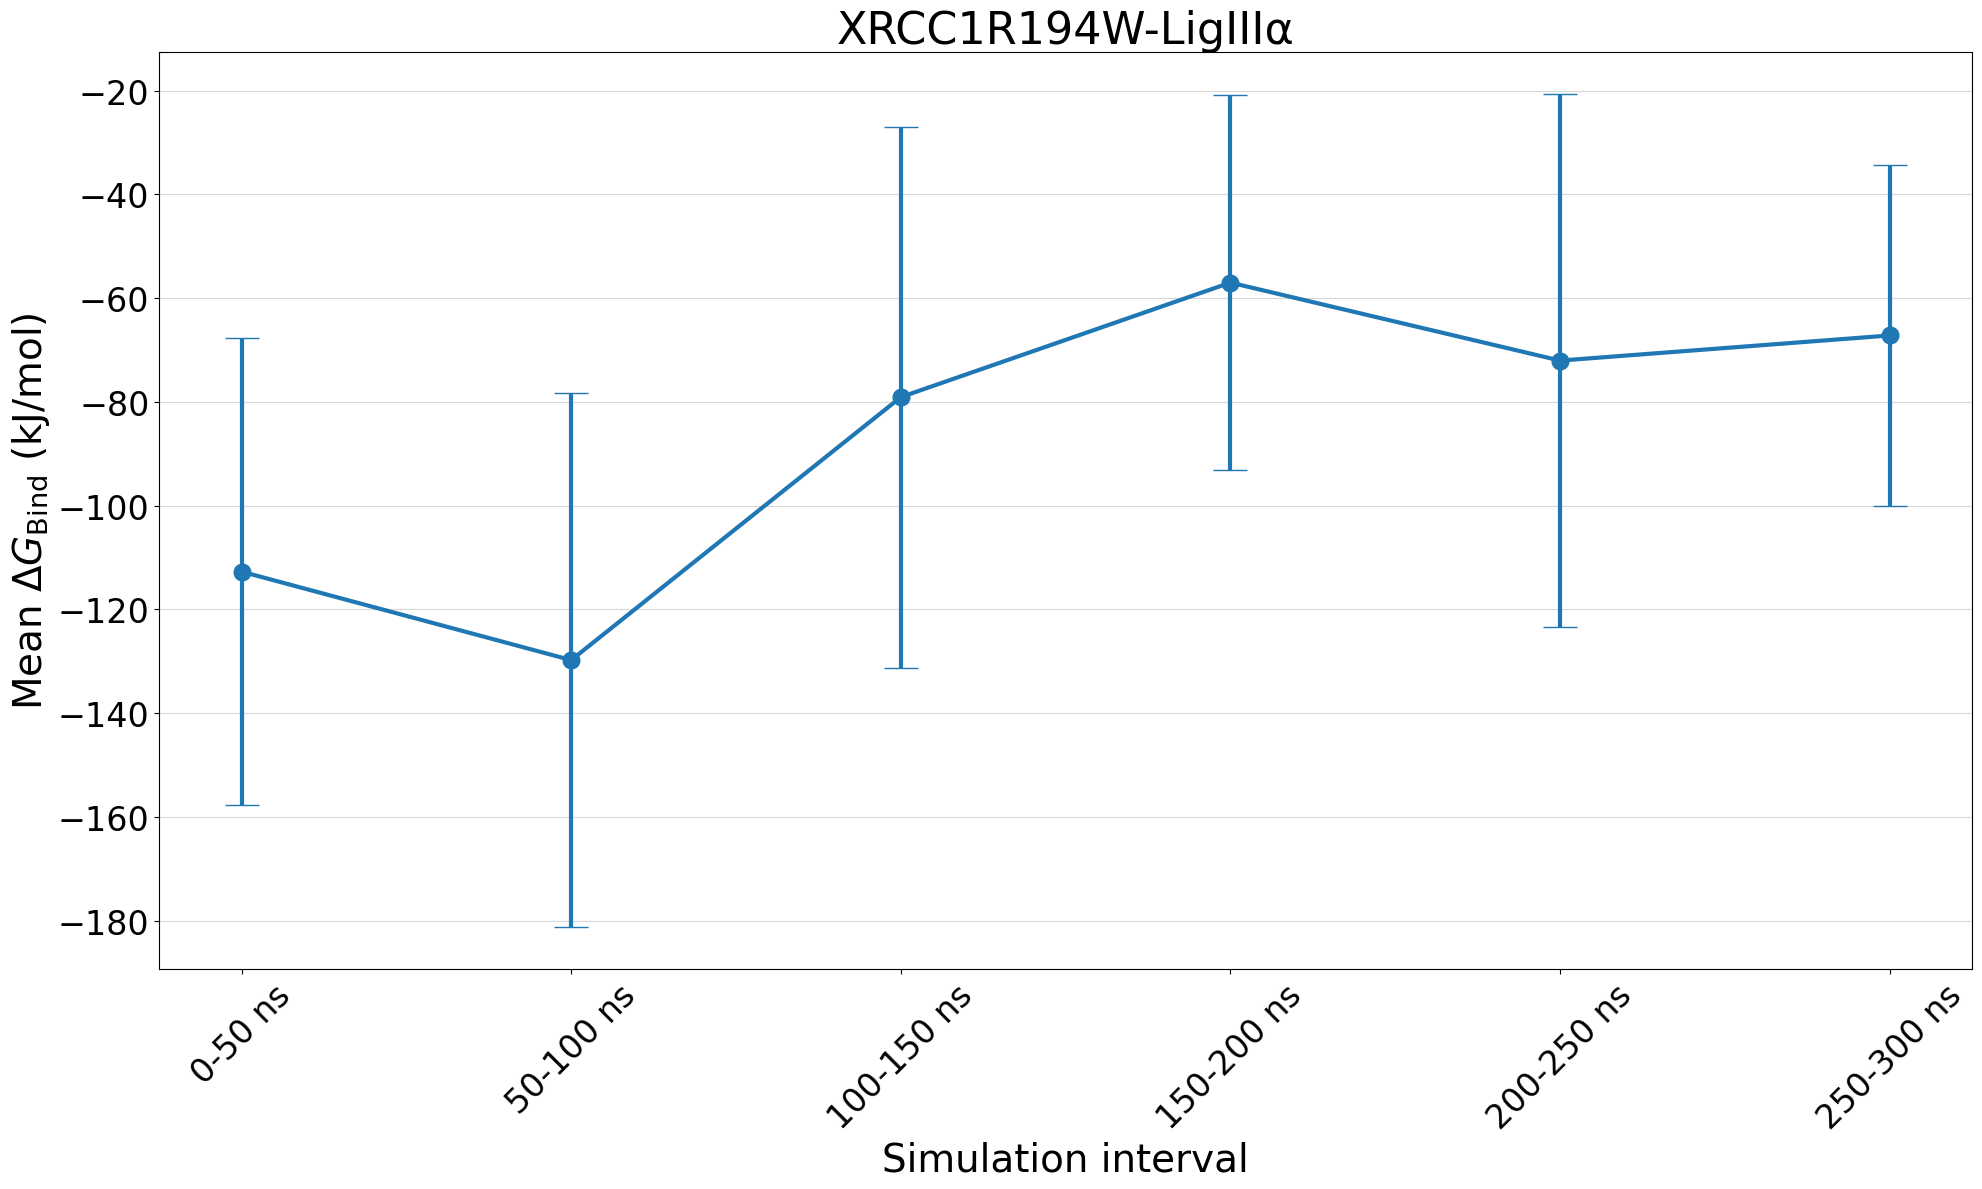

Saved: /home/naba/projects/results/XRCC1R194W-LigIII_bind_block_analysis.png


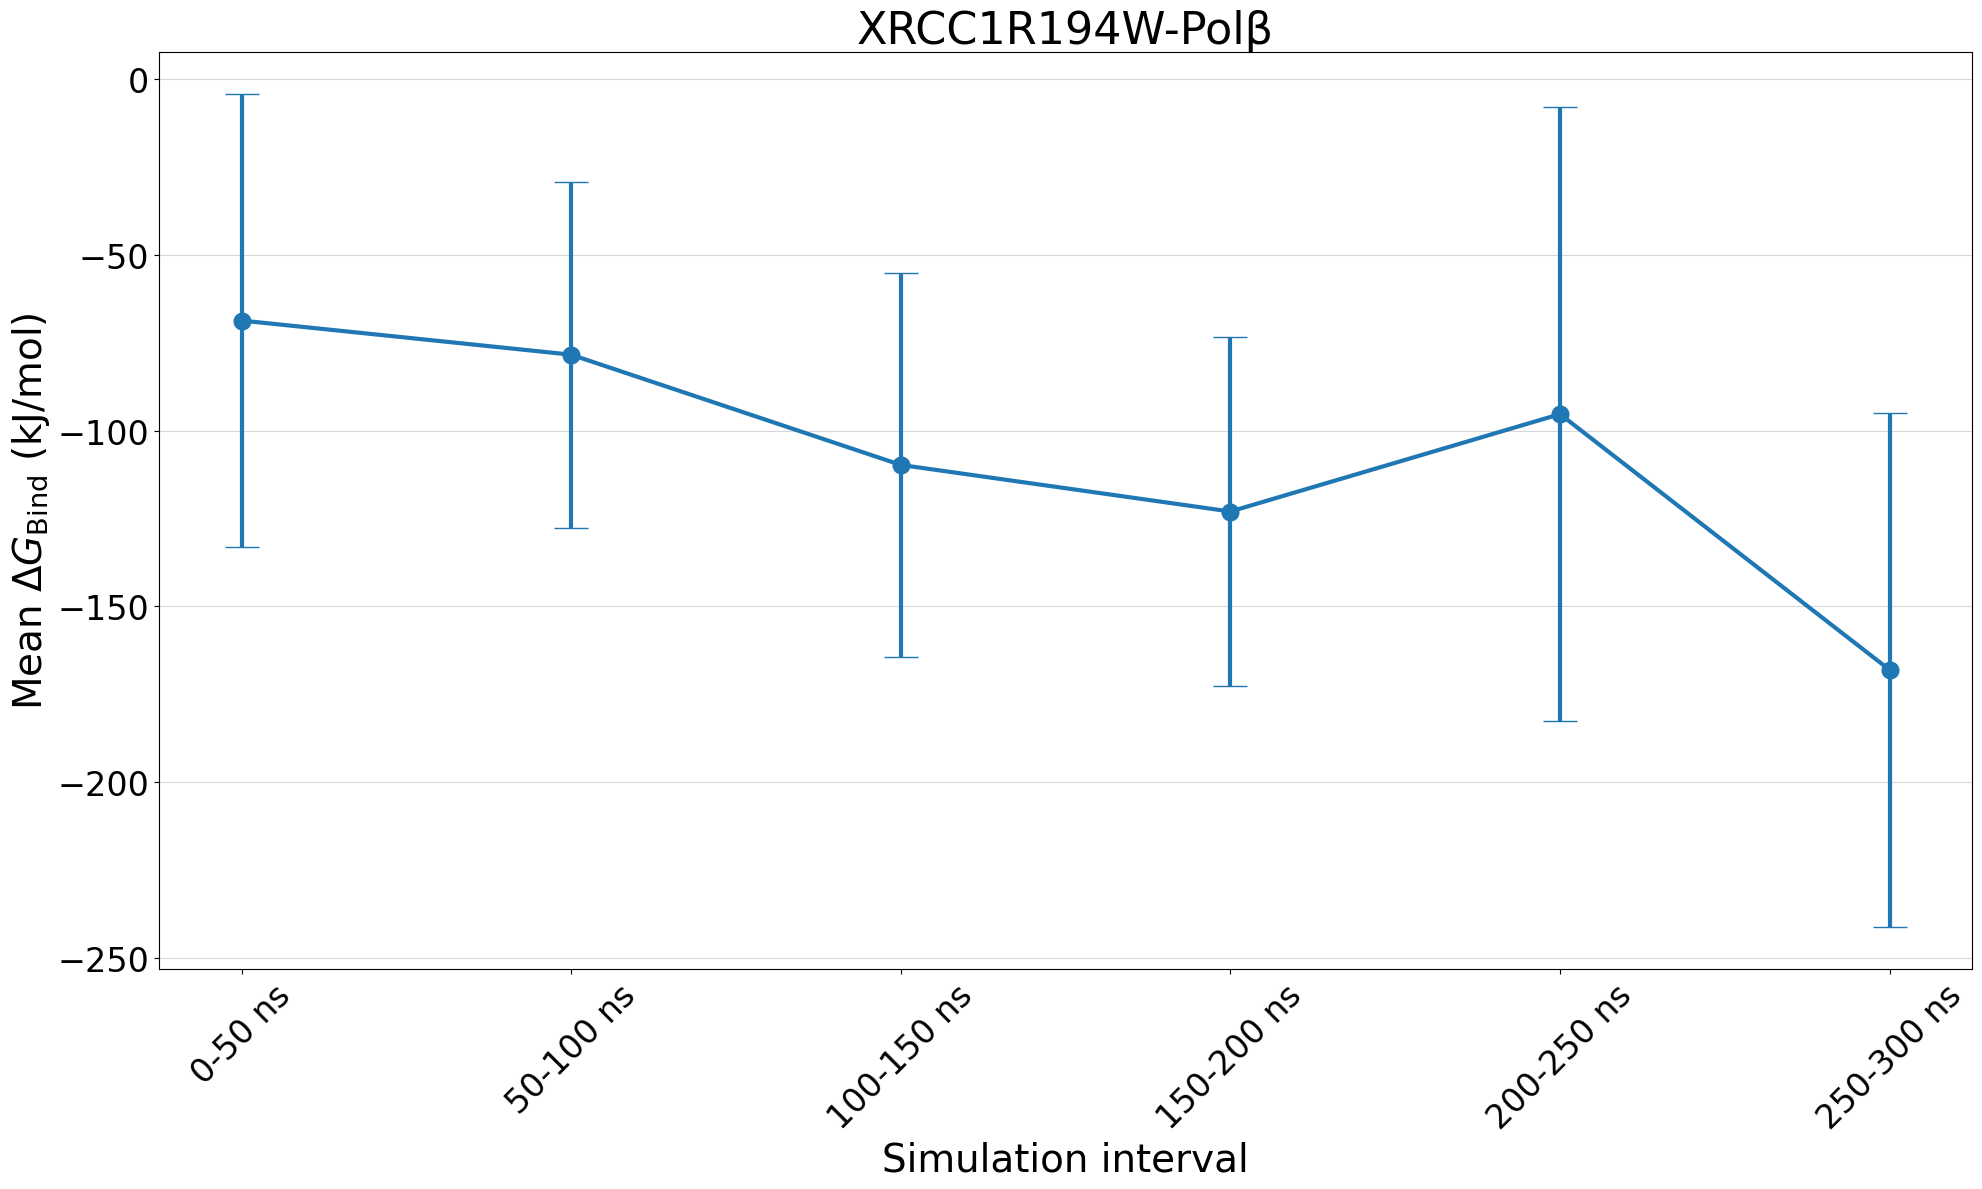

Saved: /home/naba/projects/results/XRCC1R194W-Pol_bind_block_analysis.png


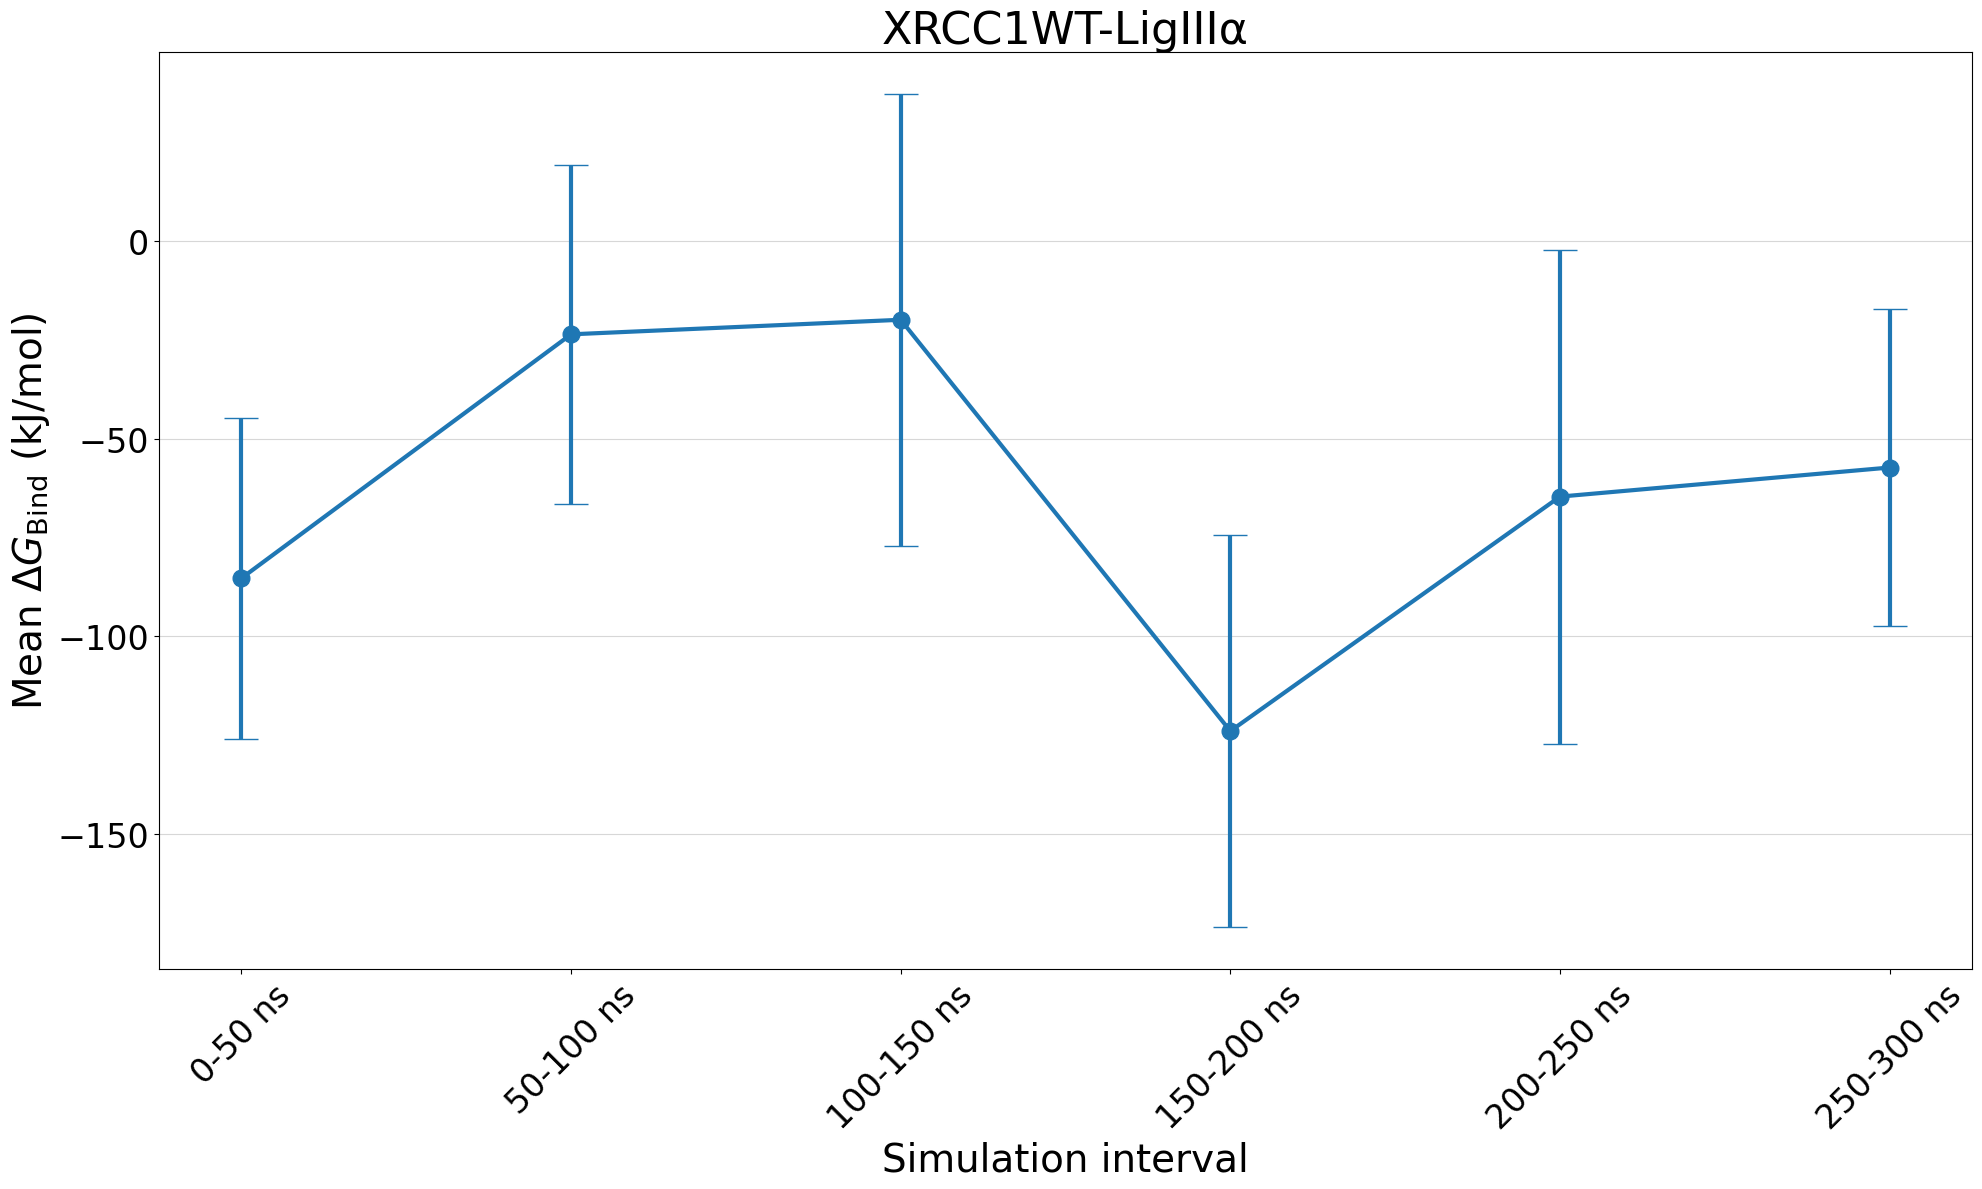

Saved: /home/naba/projects/results/XRCC1WT-LigIII_bind_block_analysis.png


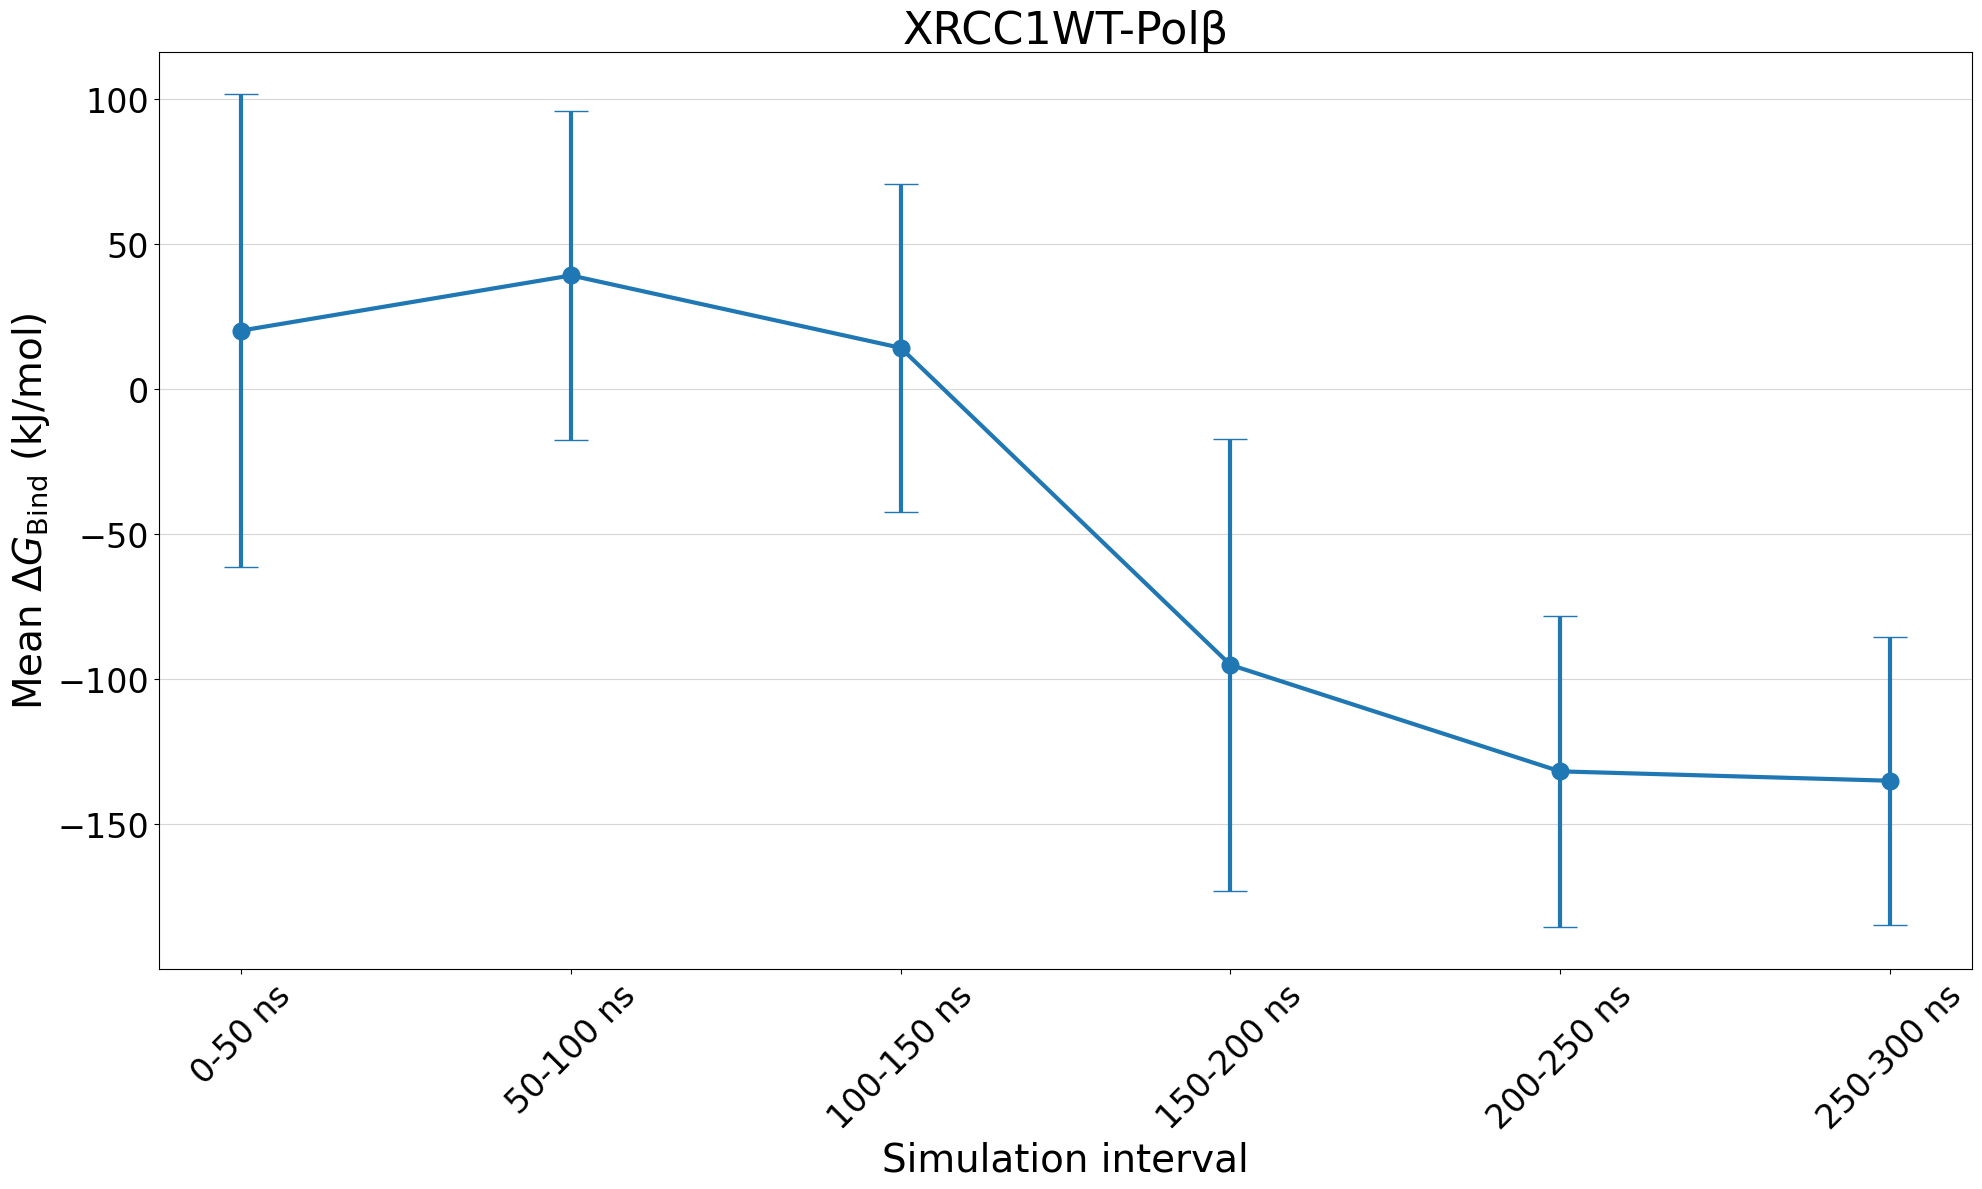

Saved: /home/naba/projects/results/XRCC1WT-Pol_bind_block_analysis.png


In [22]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_DIR = Path("/home/naba/projects")
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

result_files = sorted(PROJECT_DIR.glob("ΔGbind*_block_statistics.xlsx"))
if not result_files:
    raise FileNotFoundError(
        "No ΔGbind block-statistics Excel file found. Run block_analysis-bind.py first."
    )

results_df = pd.read_excel(result_files[0])
block_order = [
    "0-50 ns",
    "50-100 ns",
    "100-150 ns",
    "150-200 ns",
    "200-250 ns",
    "250-300 ns",
]

results_df = results_df.copy()
results_df["Block"] = pd.Categorical(
    results_df["Block"],
    categories=block_order,
    ordered=True,
)
systems = results_df["System"].dropna().unique()

for system in systems:
    temp = results_df[results_df["System"] == system].sort_values("Block")

    plt.figure(figsize=(20, 12))
    plt.errorbar(
        temp["Block"],
        temp["Mean"],
        yerr=temp["SD"],
        marker="o",
        markersize=12,
        capsize=12,
        linewidth=3,
    )
    plt.xlabel("Simulation interval", fontsize=28)
    plt.ylabel(r"Mean $\Delta G_{\mathrm{Bind}}$ (kJ/mol)", fontsize=28)
    plt.title(str(system), fontsize=32)
    plt.xticks(rotation=45, fontsize=24)
    plt.yticks(fontsize=24)
    plt.grid(axis="y", alpha=0.5)
    plt.tight_layout()

    filename = re.sub(r"[^A-Za-z0-9_.-]+", "_", str(system)).strip("_")
    output_path = RESULTS_DIR / f"{filename}_bind_block_analysis.png"
    plt.savefig(output_path, dpi=1200, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"Saved: {output_path}")

Comparison plot

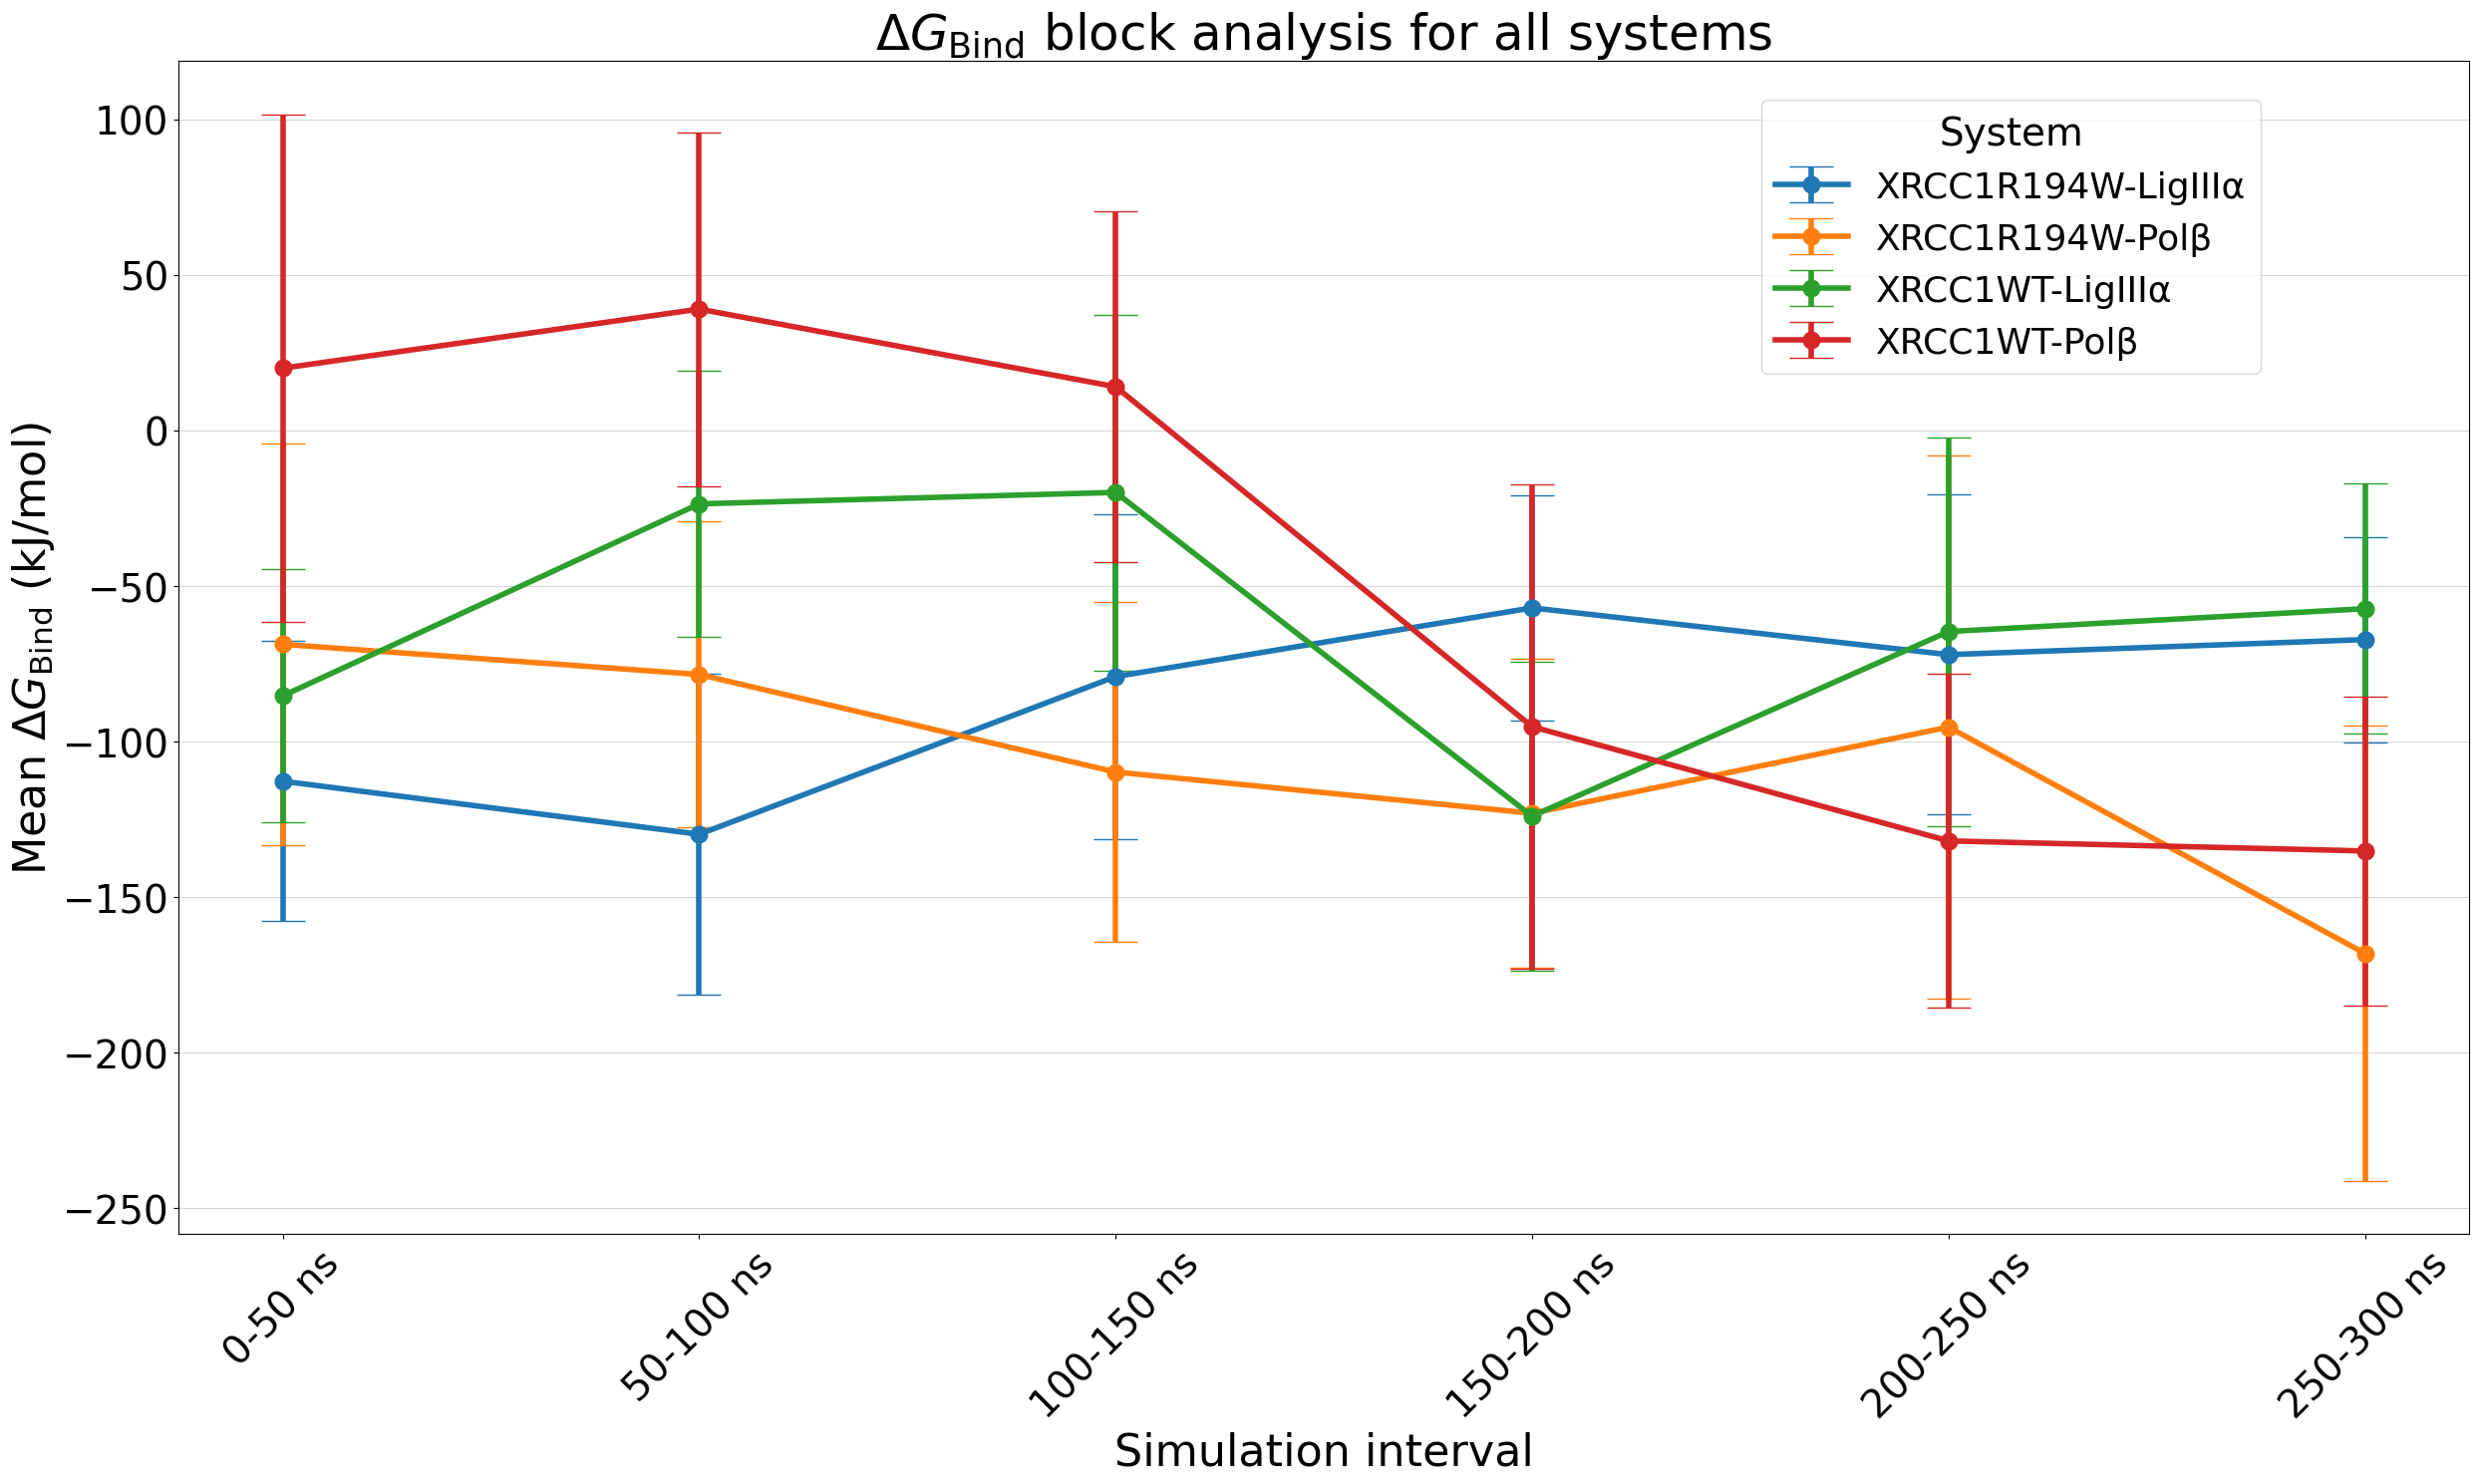

Saved: /home/naba/projects/results/all_systems_ΔGbind_block_analysis.png


In [23]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

PROJECT_DIR = Path("/home/naba/projects")
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

result_files = sorted(PROJECT_DIR.glob("ΔGbind*_block_statistics.xlsx"))
if not result_files:
    raise FileNotFoundError(
        "No ΔGbind block-statistics Excel file found. Run block_analysis-bind.py first."
    )

results_df = pd.read_excel(result_files[0])
block_order = [
    "0-50 ns",
    "50-100 ns",
    "100-150 ns",
    "150-200 ns",
    "200-250 ns",
    "250-300 ns",
]

results_df = results_df.copy()
results_df["Block"] = pd.Categorical(
    results_df["Block"],
    categories=block_order,
    ordered=True,
)
systems = results_df["System"].dropna().unique()
block_positions = range(len(block_order))

# Change these two values to move the legend box.
# x: 0 = left, 1 = right; y: 0 = bottom, 1 = top.
legend_position = (0.8, 0.85)

plt.figure(figsize=(25, 15))

for system in systems:
    temp = results_df[results_df["System"] == system].sort_values("Block")
    plt.errorbar(
        block_positions,
        temp["Mean"],
        yerr=temp["SD"],
        marker="o",
        markersize=12,
        capsize=16,
        linewidth=4,
        label=str(system),
    )

plt.xlabel("Simulation interval", fontsize=32)
plt.ylabel(r"Mean $\Delta G_{\mathrm{Bind}}$ (kJ/mol)", fontsize=32)
plt.title(r"$\Delta G_{\mathrm{Bind}}$ block analysis for all systems", fontsize=36)
plt.xticks(list(block_positions), block_order, rotation=45, fontsize=28)
plt.yticks(fontsize=28)
plt.legend(
    title="System",
    title_fontsize=28,
    fontsize=26,
    loc="center",
    bbox_to_anchor=legend_position,
)
plt.grid(axis="y", alpha=0.5)
plt.tight_layout()

output_path = RESULTS_DIR / "all_systems_ΔGbind_block_analysis.png"
plt.savefig(output_path, dpi=1200, bbox_inches="tight")
plt.show()
plt.close()

print(f"Saved: {output_path}")

Cumulative Means

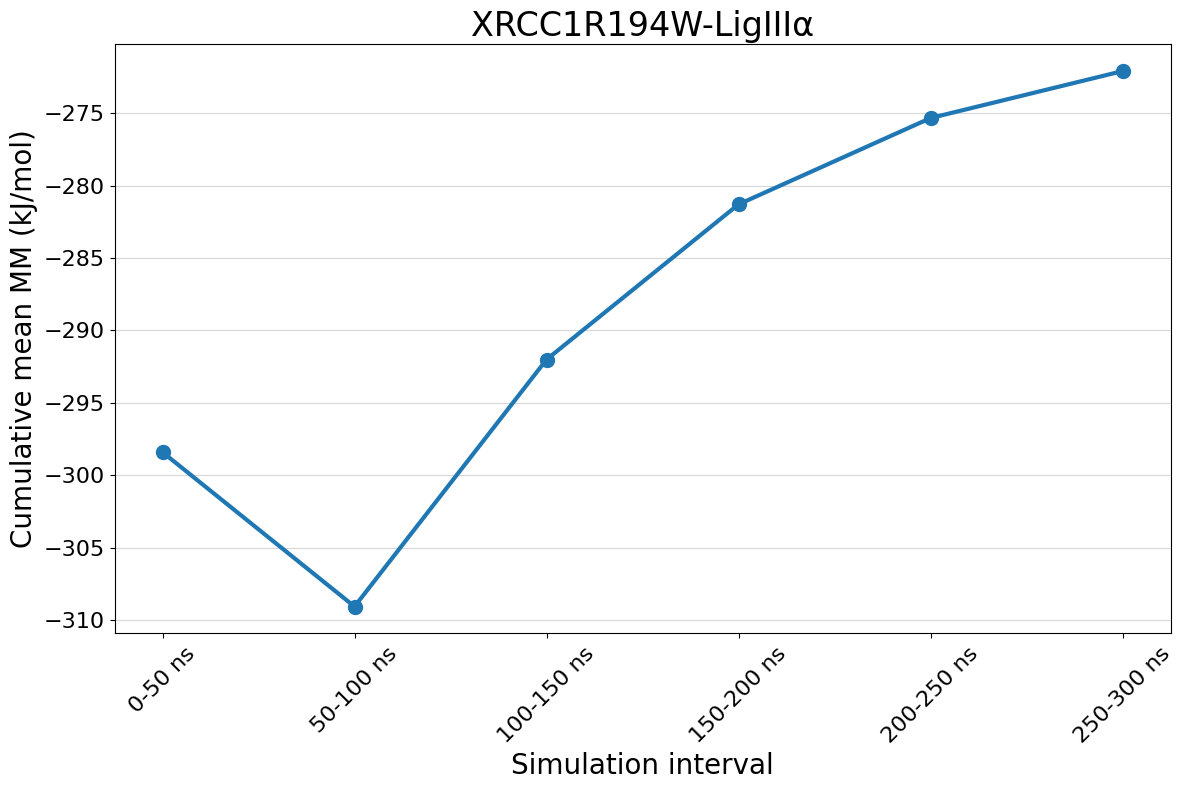

Saved: /home/naba/projects/results/MM-WT-replicate-and-R194W_XRCC1R194W-LigIIIα_cumulative_mean.png


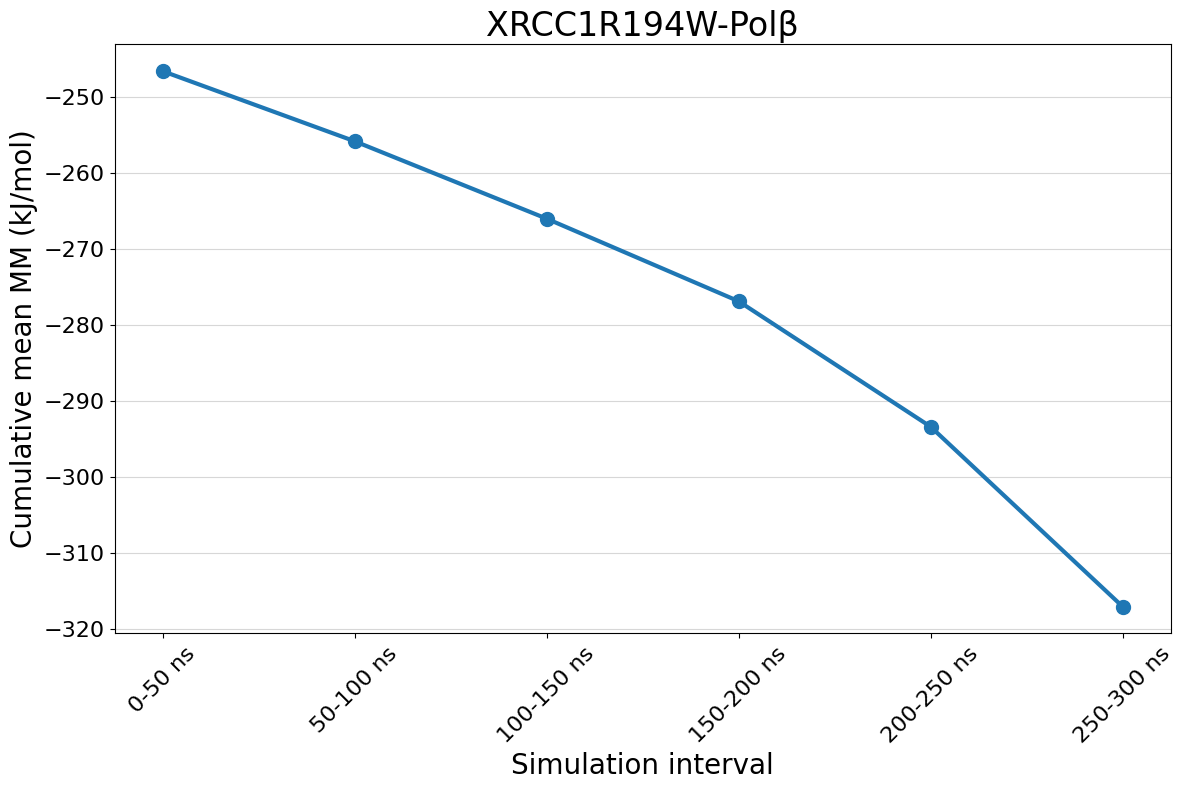

Saved: /home/naba/projects/results/MM-WT-replicate-and-R194W_XRCC1R194W-Polβ_cumulative_mean.png


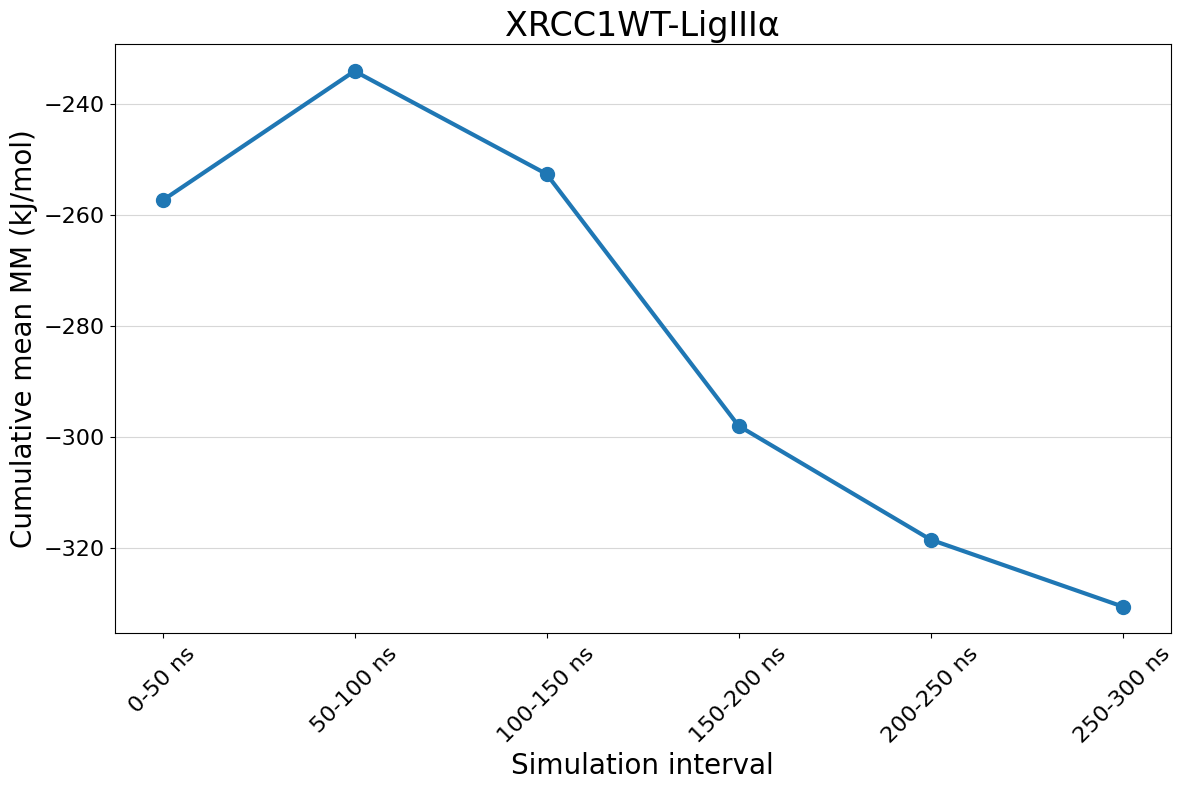

Saved: /home/naba/projects/results/MM-WT-replicate-and-R194W_XRCC1WT-LigIIIα_cumulative_mean.png


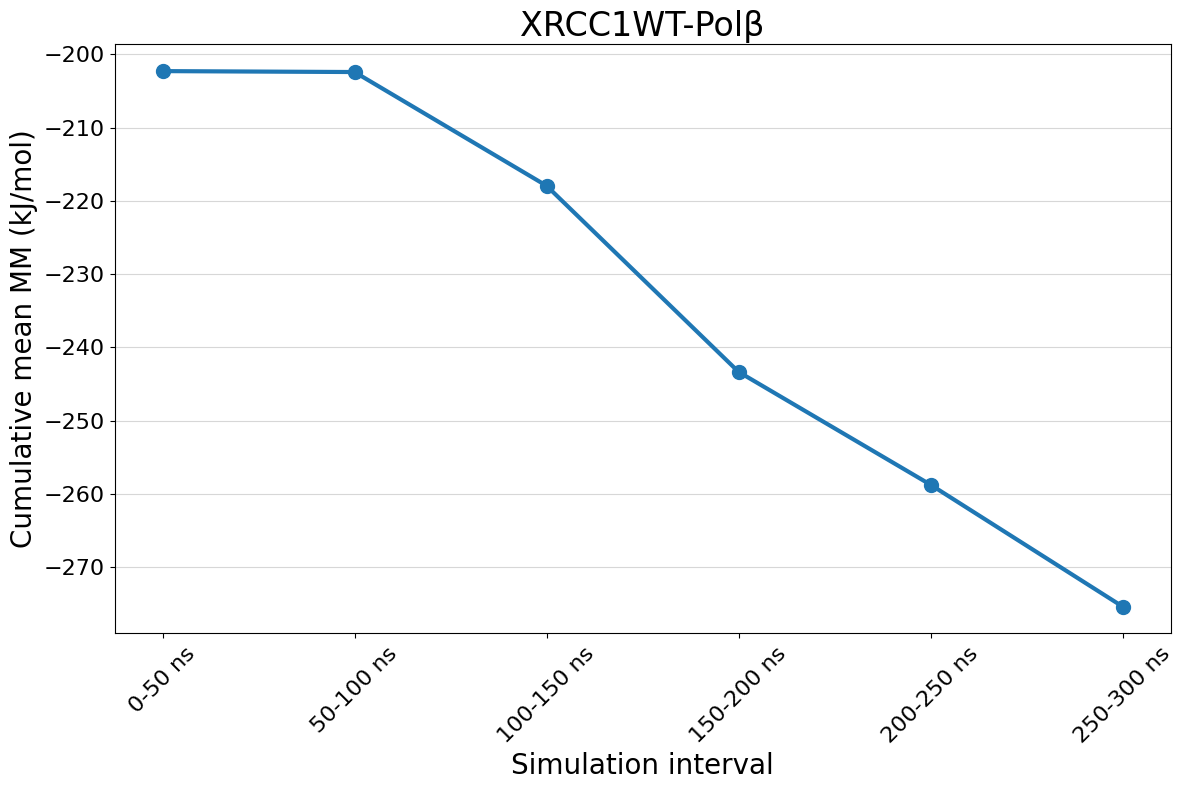

Saved: /home/naba/projects/results/MM-WT-replicate-and-R194W_XRCC1WT-Polβ_cumulative_mean.png


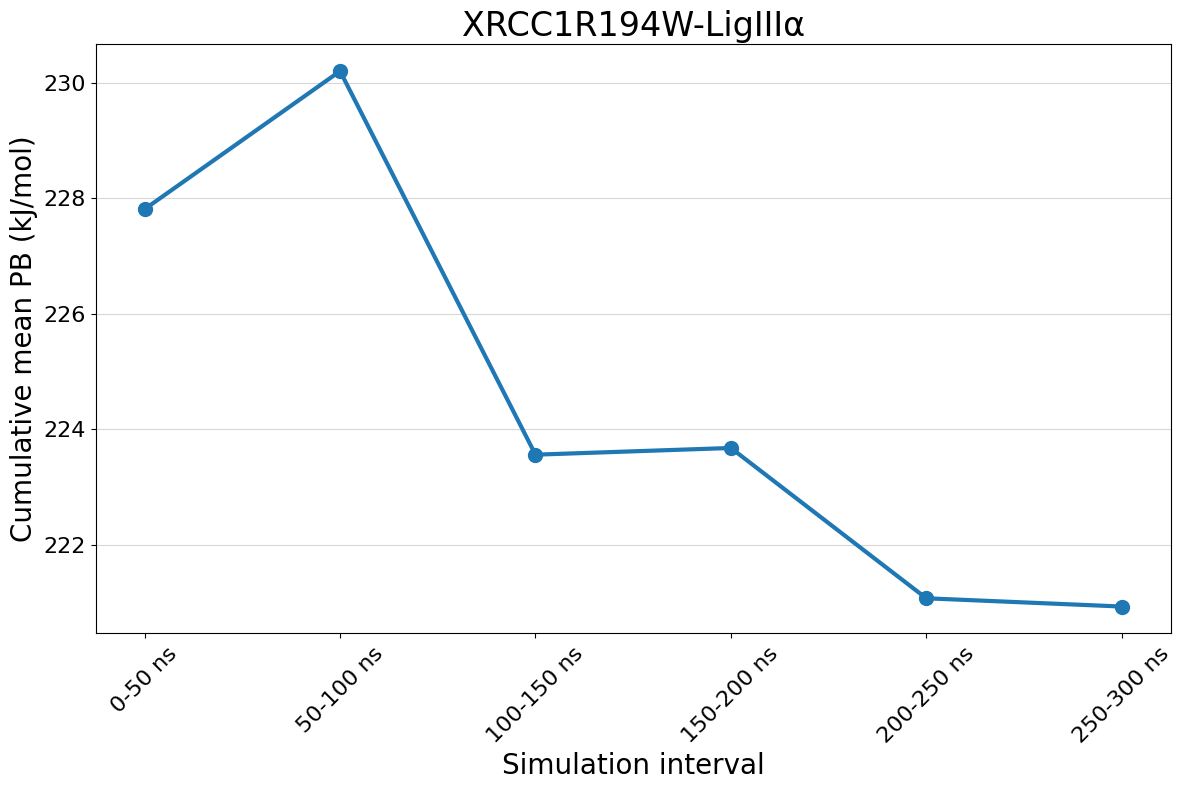

Saved: /home/naba/projects/results/PB-WT-replicate-and-R194W_XRCC1R194W-LigIIIα_cumulative_mean.png


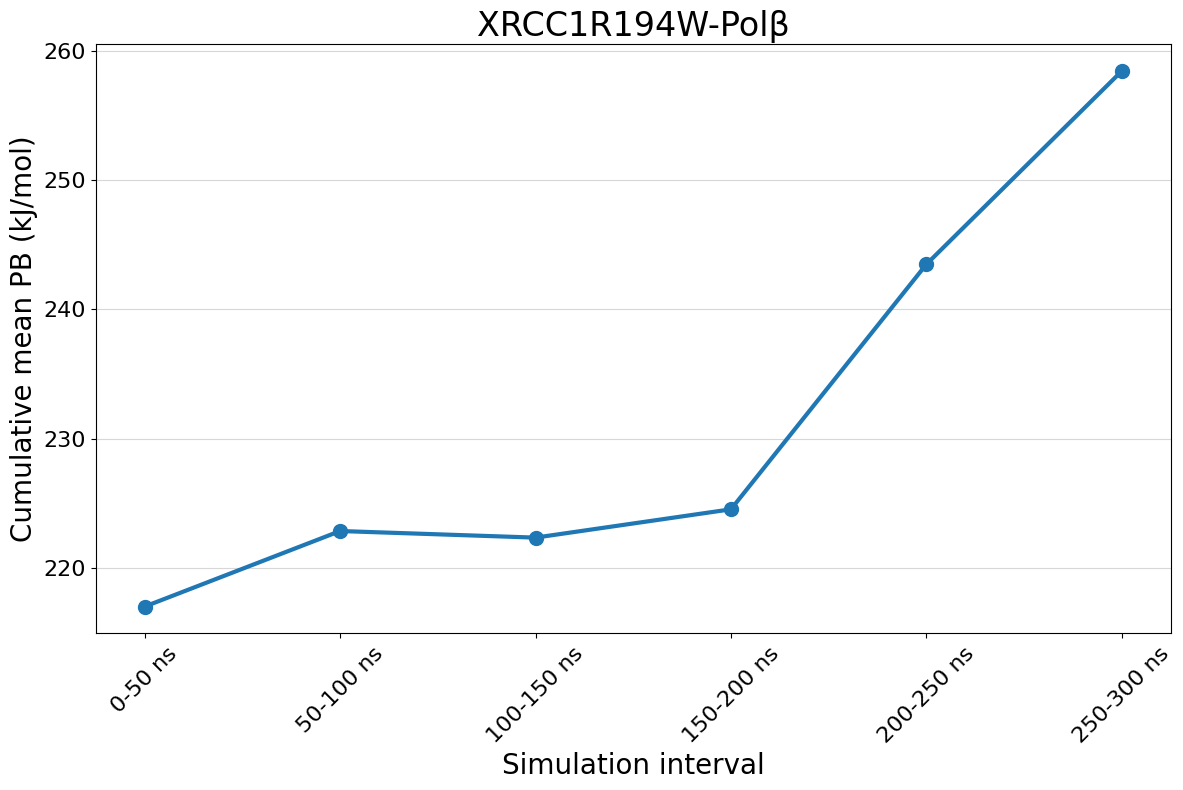

Saved: /home/naba/projects/results/PB-WT-replicate-and-R194W_XRCC1R194W-Polβ_cumulative_mean.png


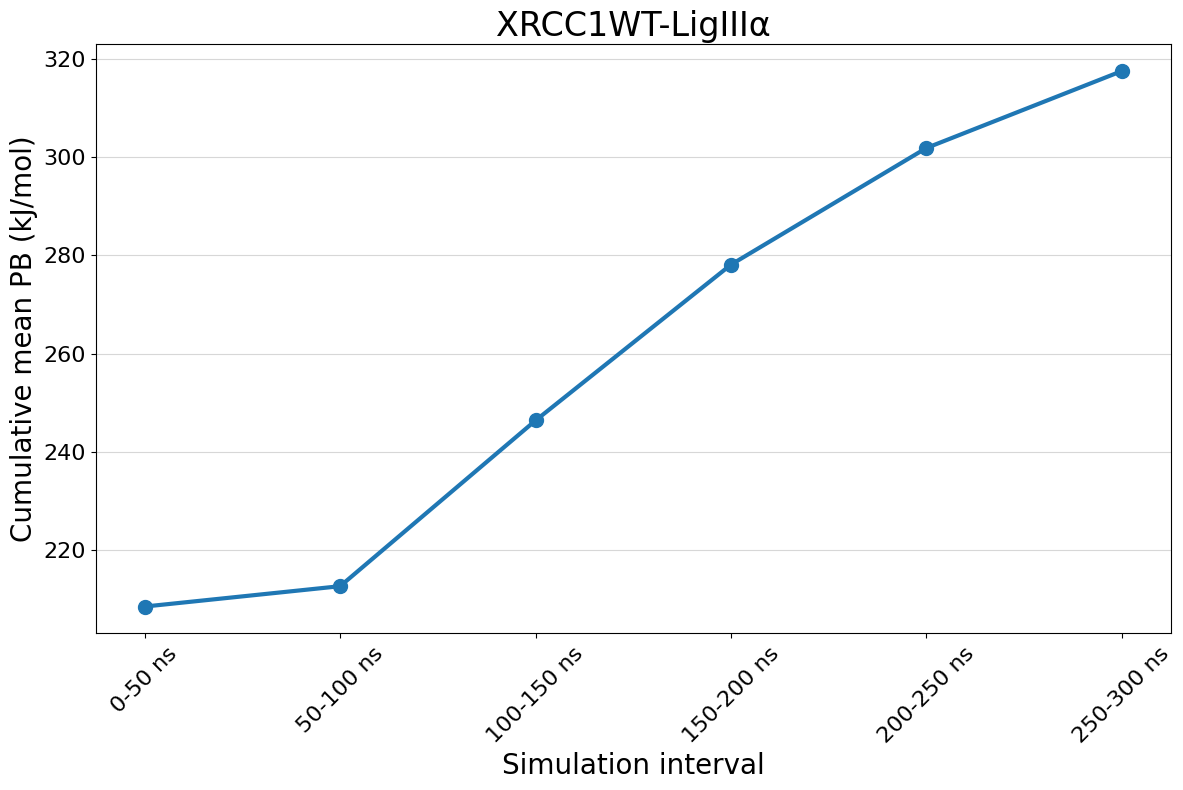

Saved: /home/naba/projects/results/PB-WT-replicate-and-R194W_XRCC1WT-LigIIIα_cumulative_mean.png


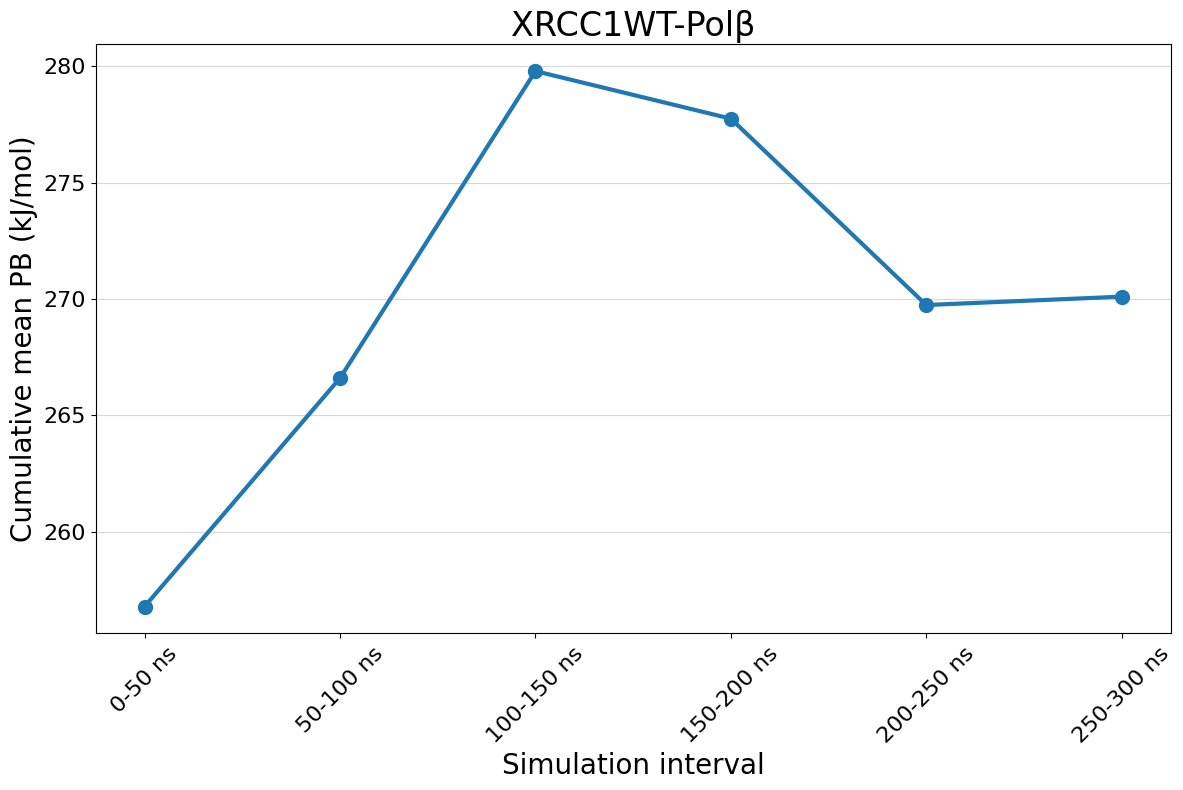

Saved: /home/naba/projects/results/PB-WT-replicate-and-R194W_XRCC1WT-Polβ_cumulative_mean.png


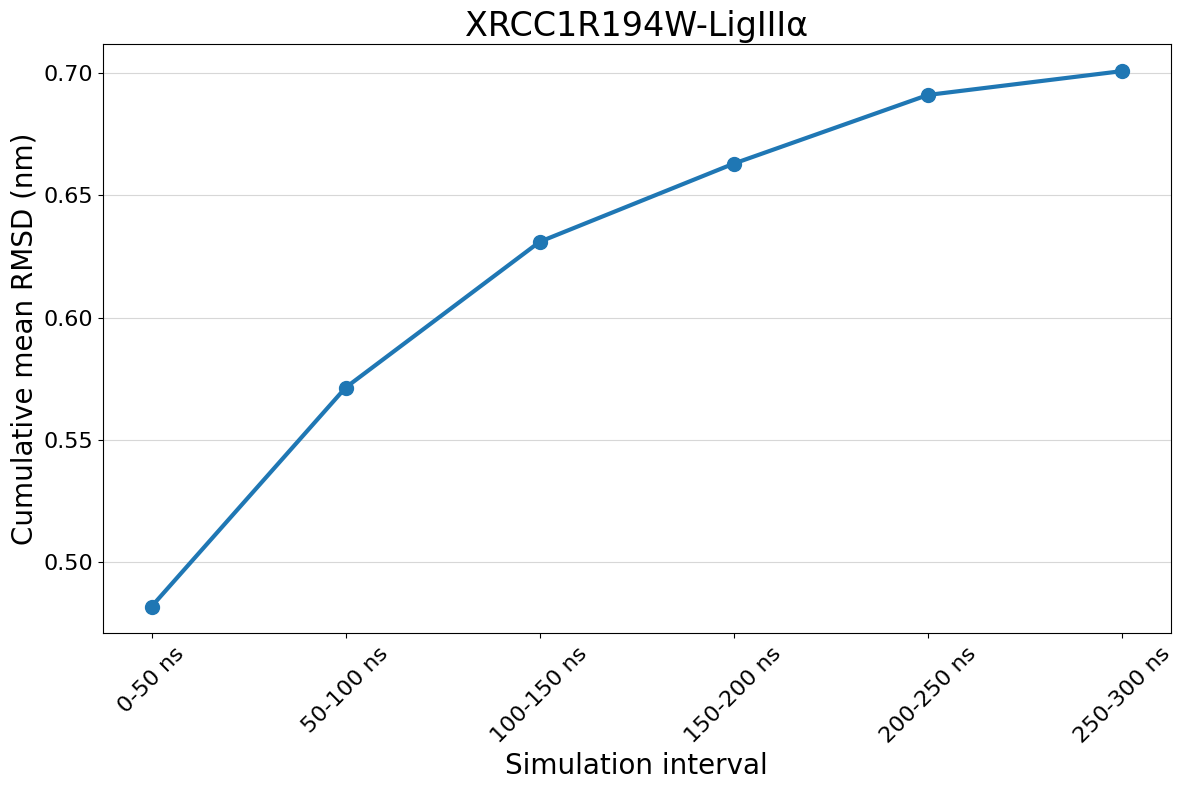

Saved: /home/naba/projects/results/RMSD-WT-replicate-and-R194W_XRCC1R194W-LigIIIα_cumulative_mean.png


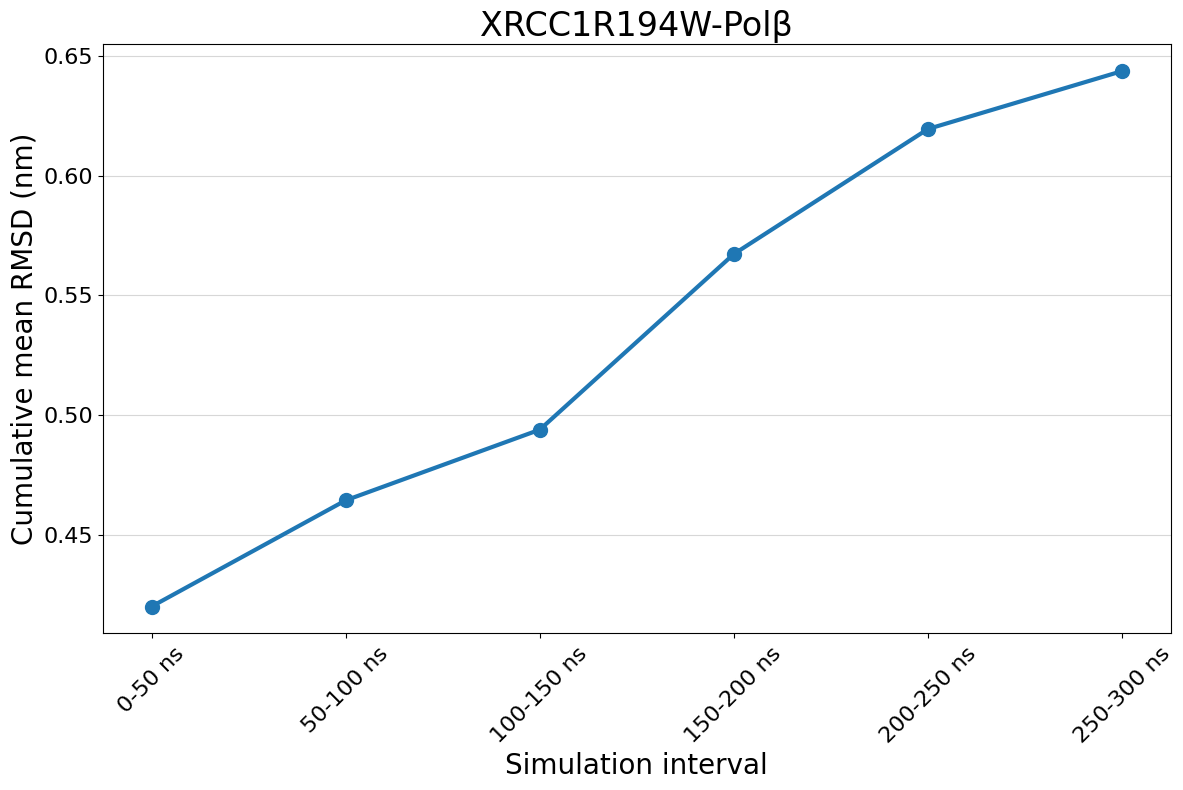

Saved: /home/naba/projects/results/RMSD-WT-replicate-and-R194W_XRCC1R194W-Polβ_cumulative_mean.png


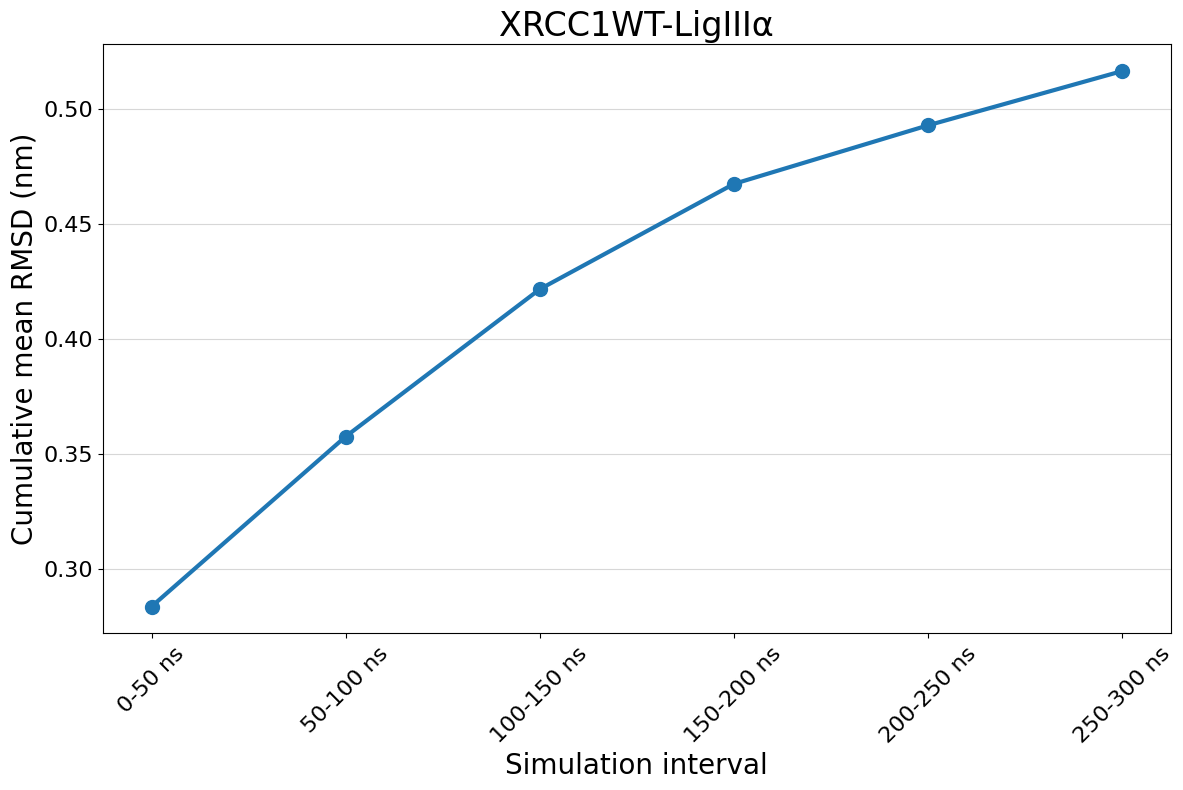

Saved: /home/naba/projects/results/RMSD-WT-replicate-and-R194W_XRCC1WT-LigIIIα_cumulative_mean.png


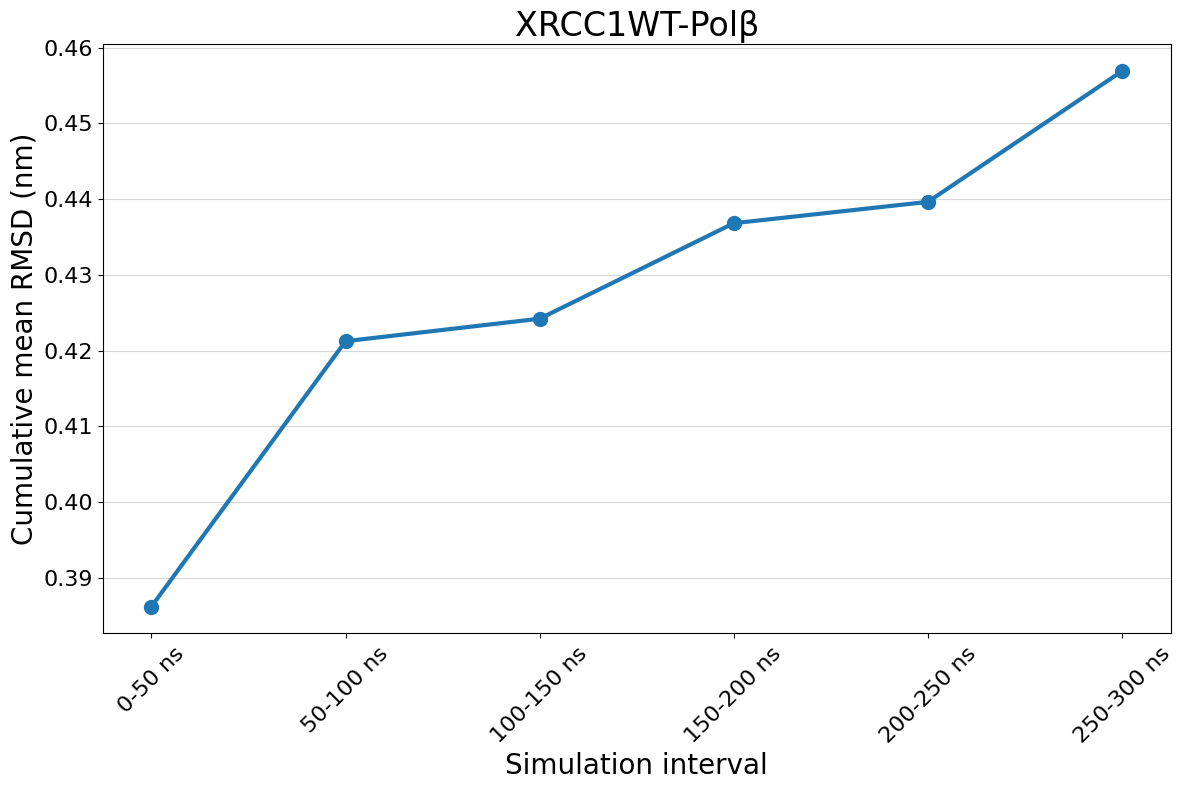

Saved: /home/naba/projects/results/RMSD-WT-replicate-and-R194W_XRCC1WT-Polβ_cumulative_mean.png


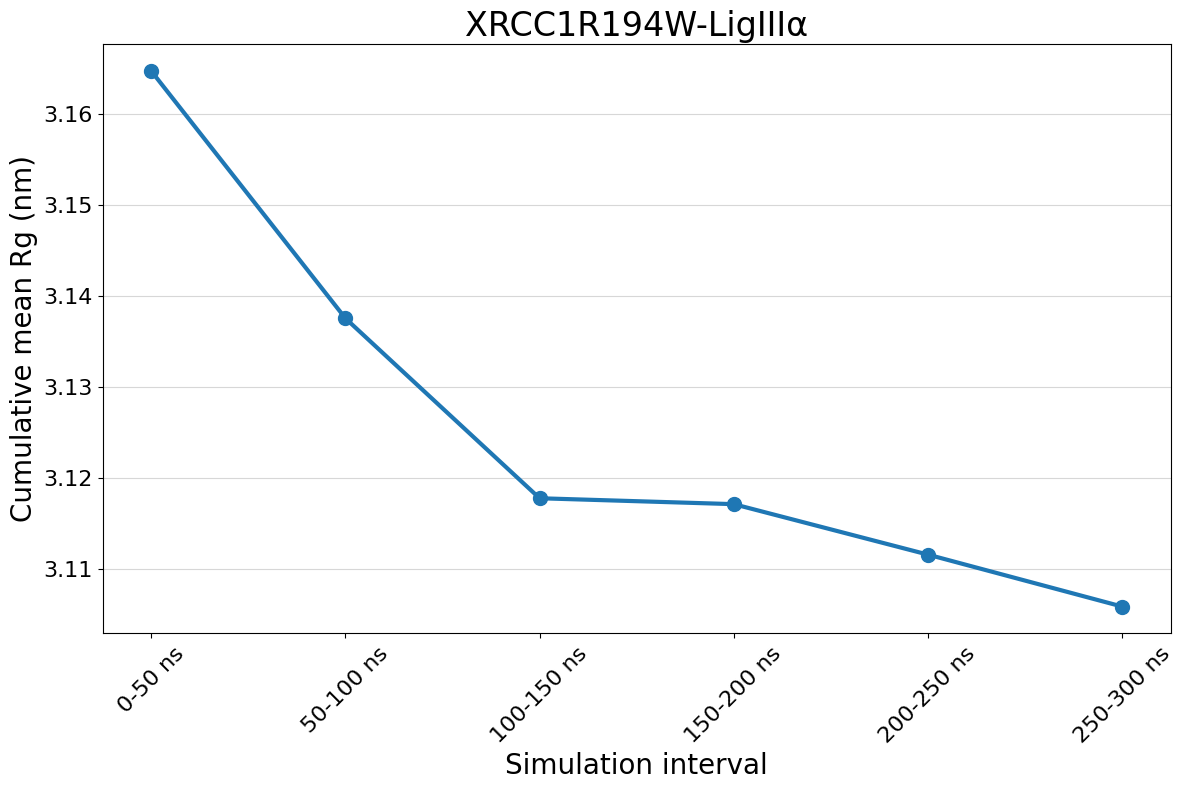

Saved: /home/naba/projects/results/Rg-WT-replicate-and-R194W_XRCC1R194W-LigIIIα_cumulative_mean.png


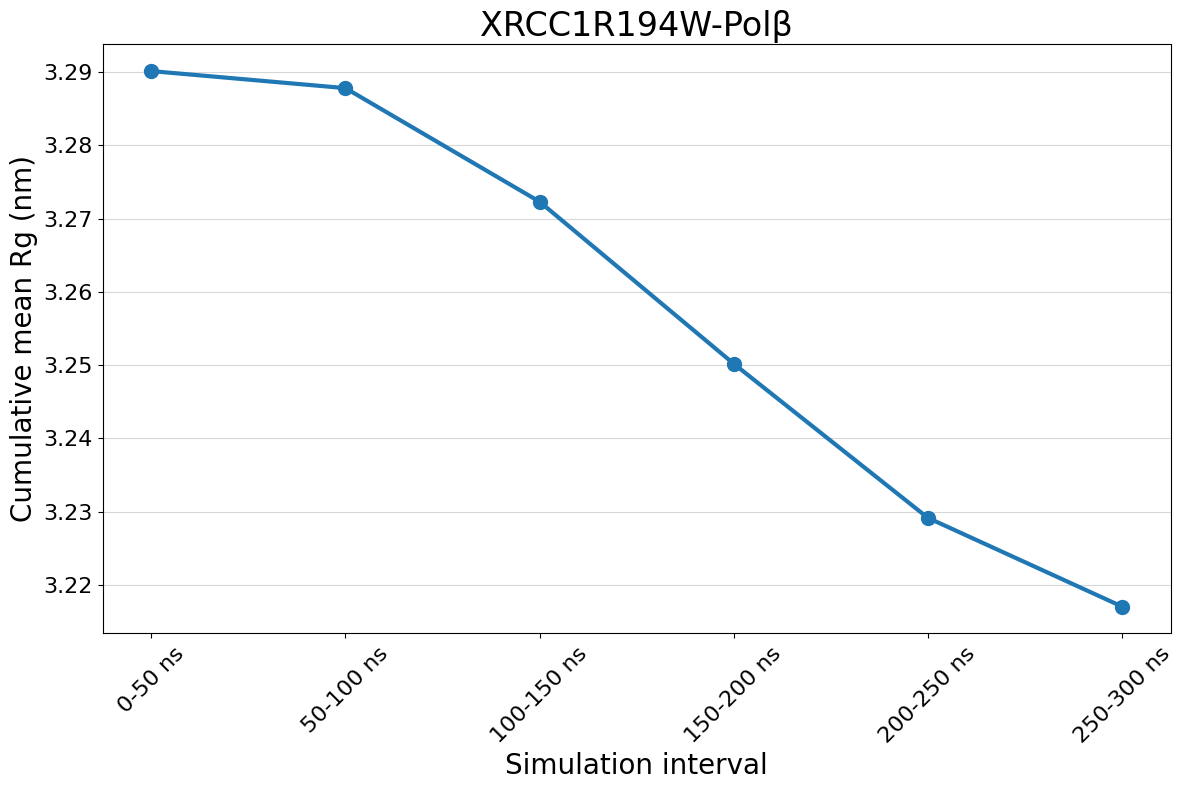

Saved: /home/naba/projects/results/Rg-WT-replicate-and-R194W_XRCC1R194W-Polβ_cumulative_mean.png


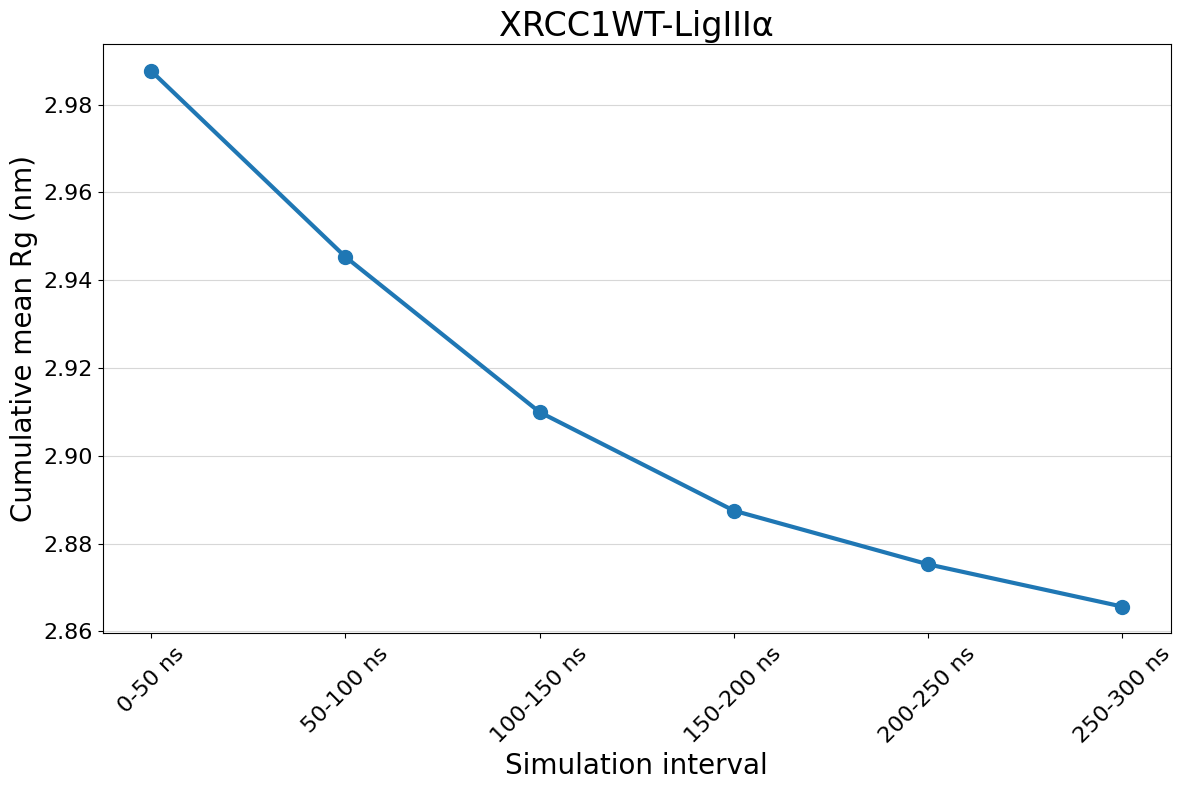

Saved: /home/naba/projects/results/Rg-WT-replicate-and-R194W_XRCC1WT-LigIIIα_cumulative_mean.png


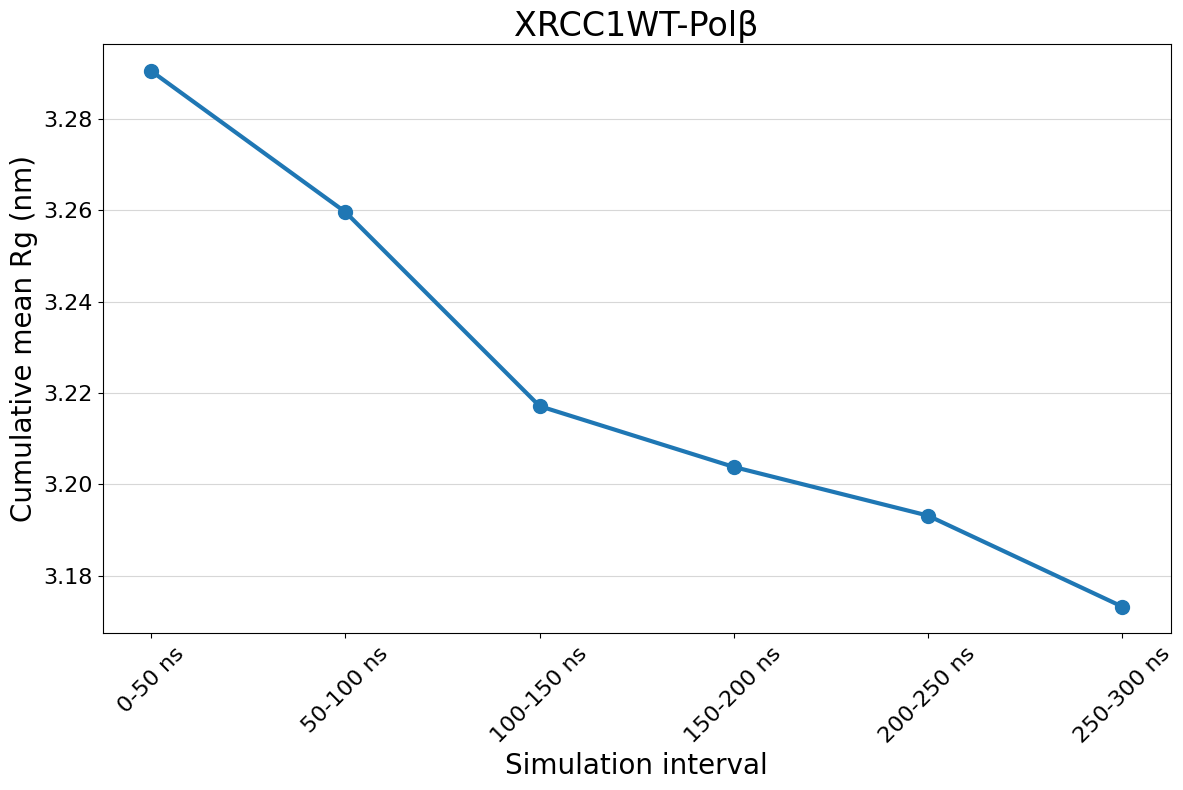

Saved: /home/naba/projects/results/Rg-WT-replicate-and-R194W_XRCC1WT-Polβ_cumulative_mean.png


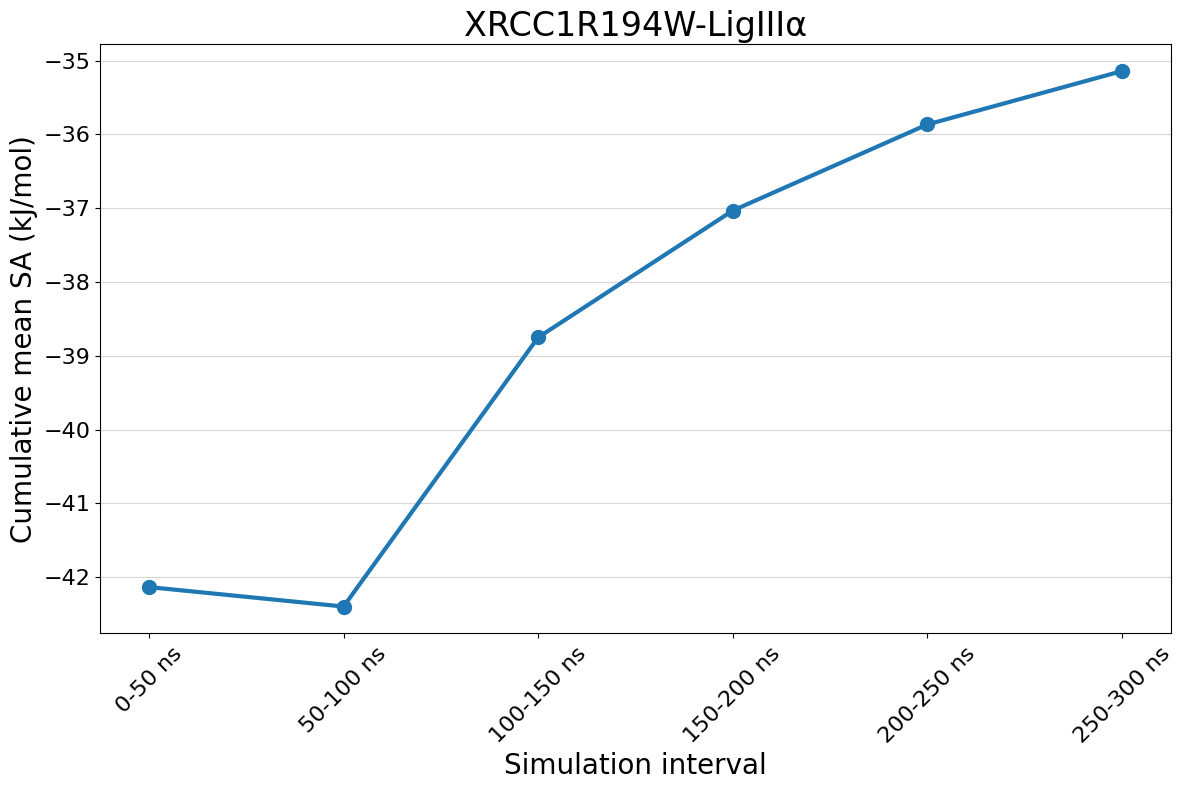

Saved: /home/naba/projects/results/SA-WT-replicate-and-R194W_XRCC1R194W-LigIIIα_cumulative_mean.png


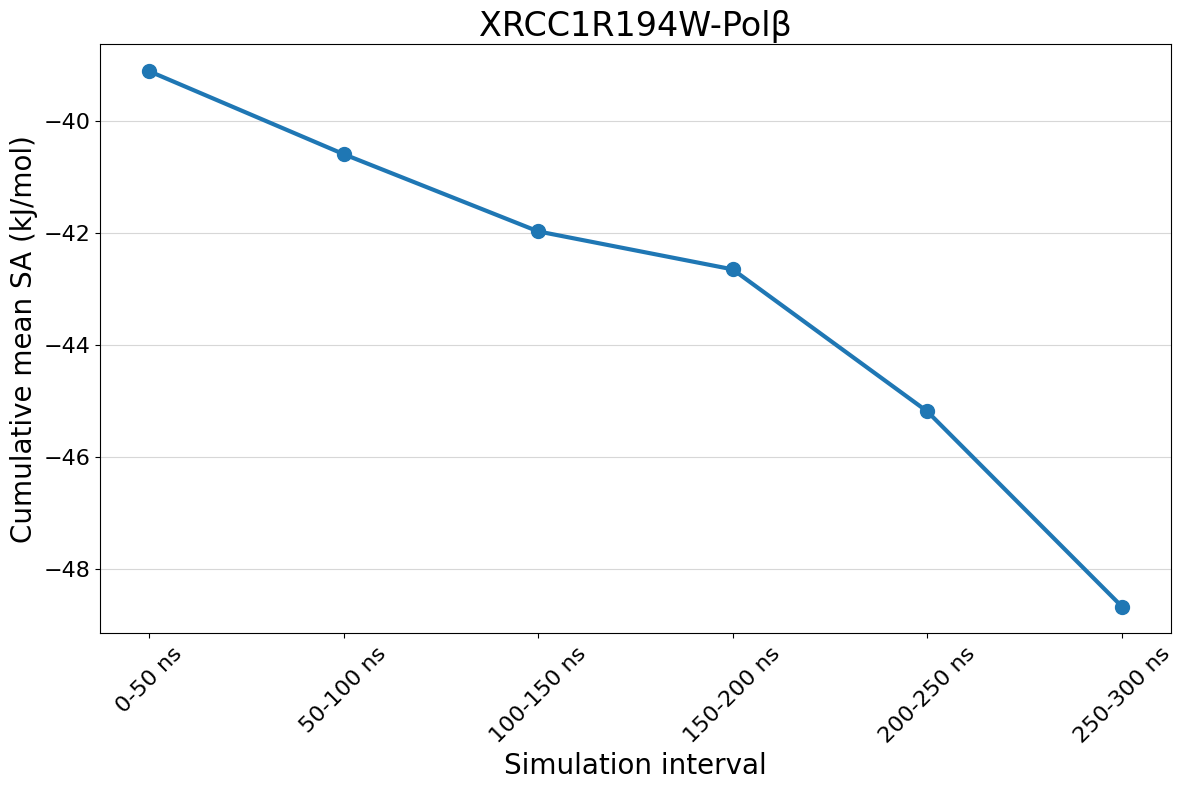

Saved: /home/naba/projects/results/SA-WT-replicate-and-R194W_XRCC1R194W-Polβ_cumulative_mean.png


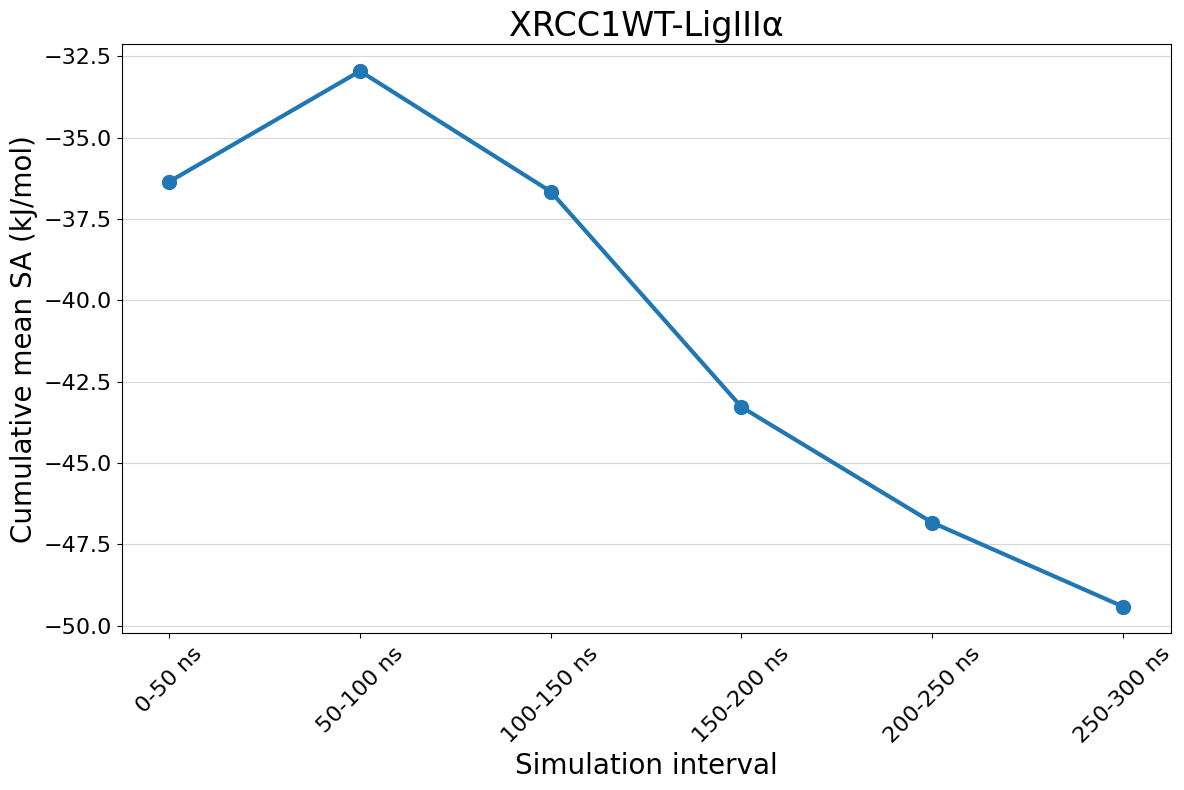

Saved: /home/naba/projects/results/SA-WT-replicate-and-R194W_XRCC1WT-LigIIIα_cumulative_mean.png


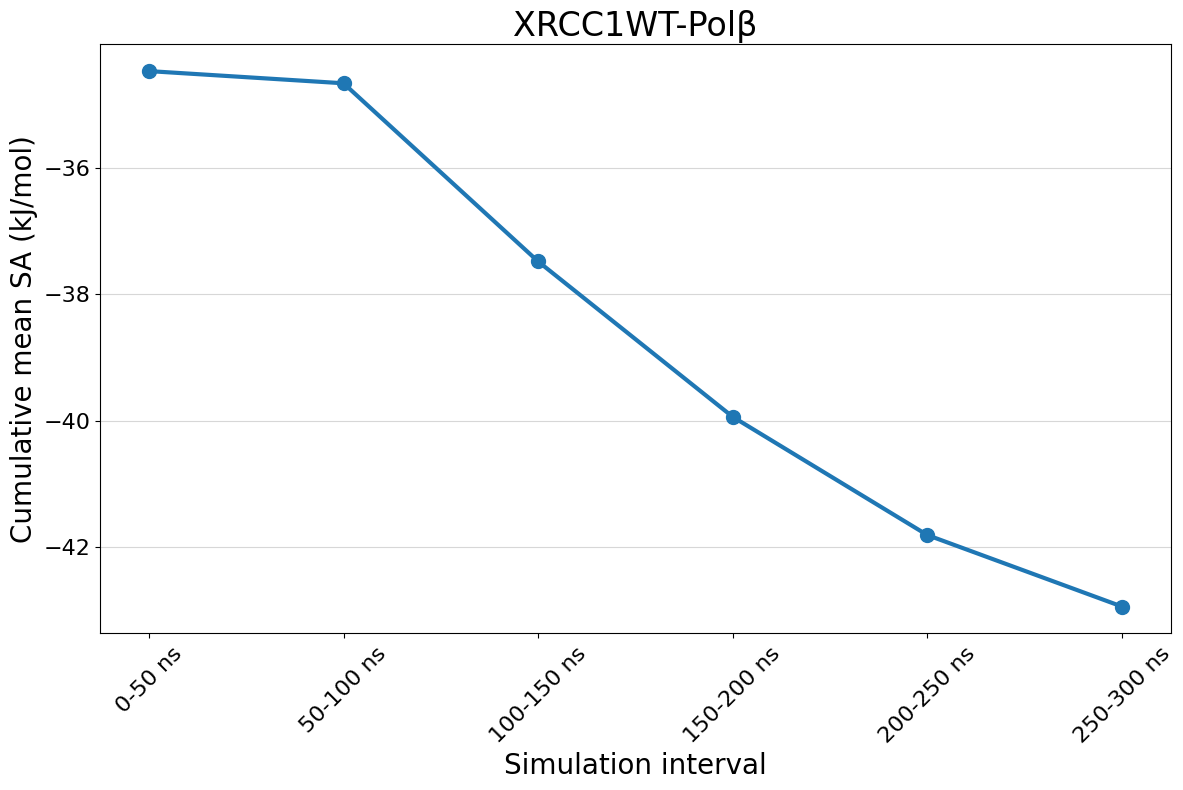

Saved: /home/naba/projects/results/SA-WT-replicate-and-R194W_XRCC1WT-Polβ_cumulative_mean.png


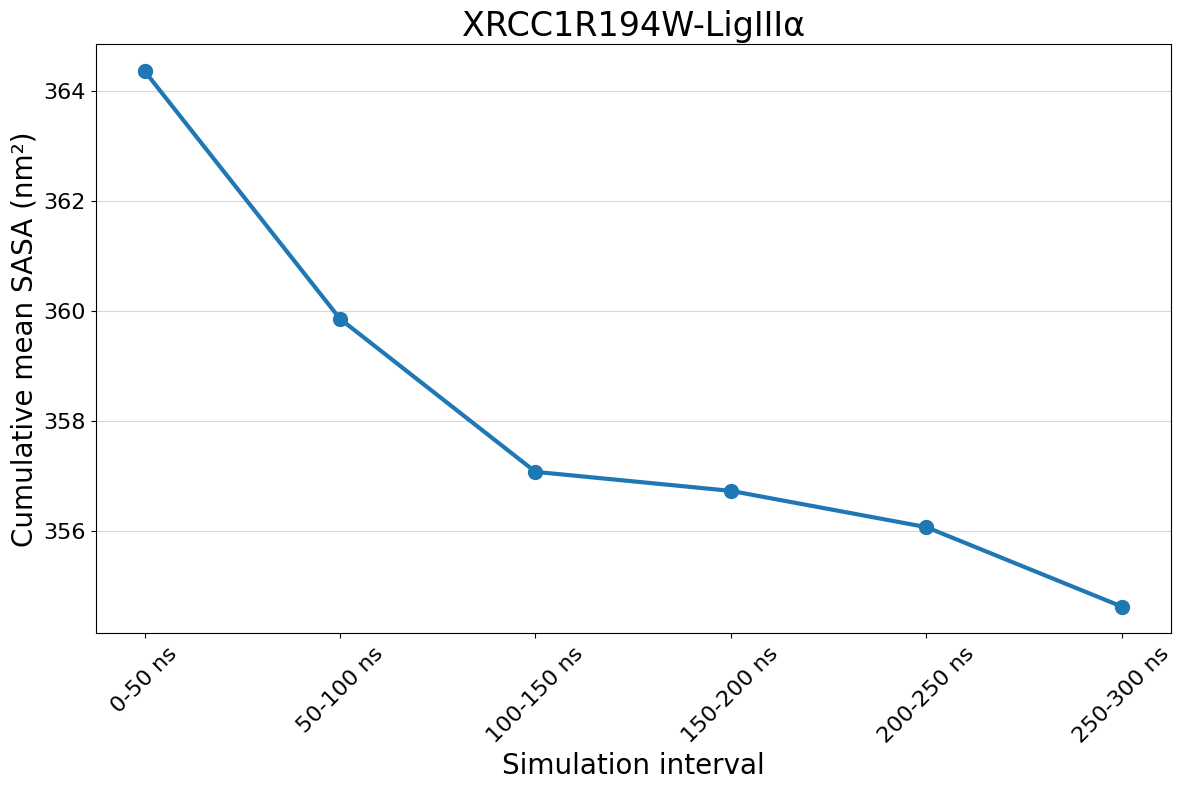

Saved: /home/naba/projects/results/SASA-WT-replicate-and-R194W_XRCC1R194W-LigIIIα_cumulative_mean.png


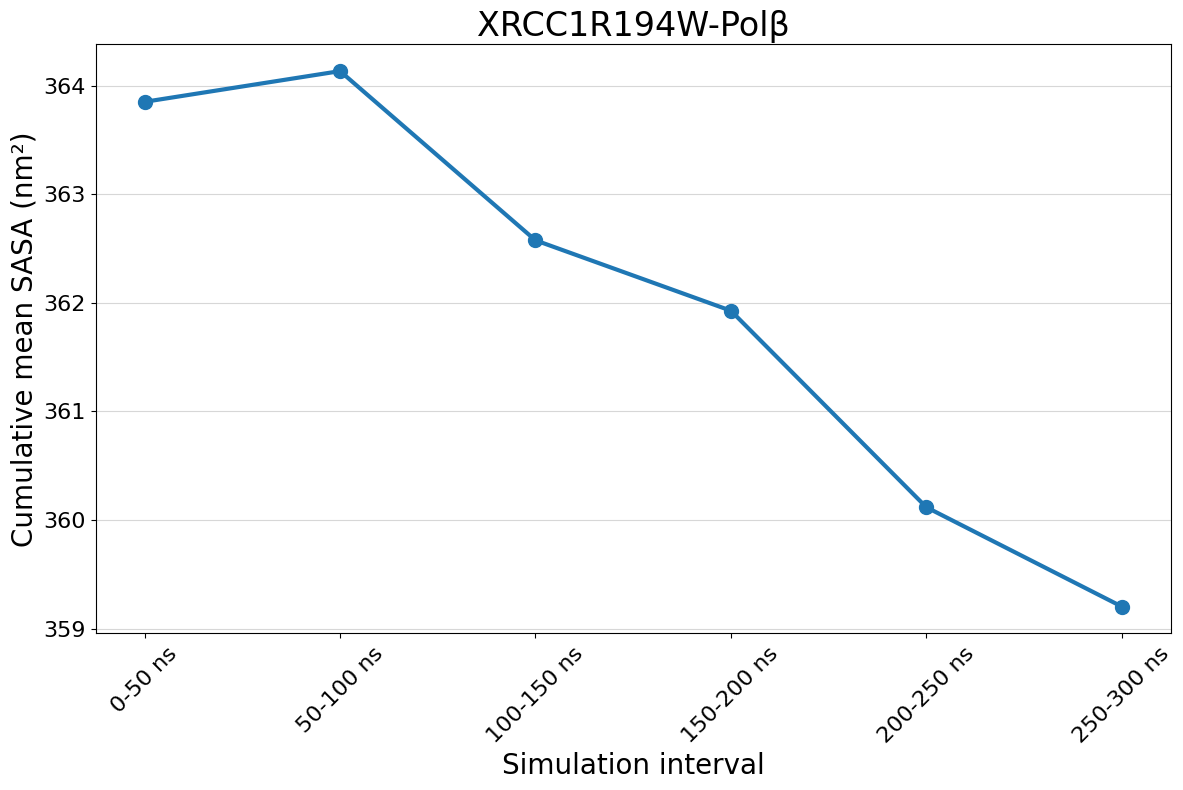

Saved: /home/naba/projects/results/SASA-WT-replicate-and-R194W_XRCC1R194W-Polβ_cumulative_mean.png


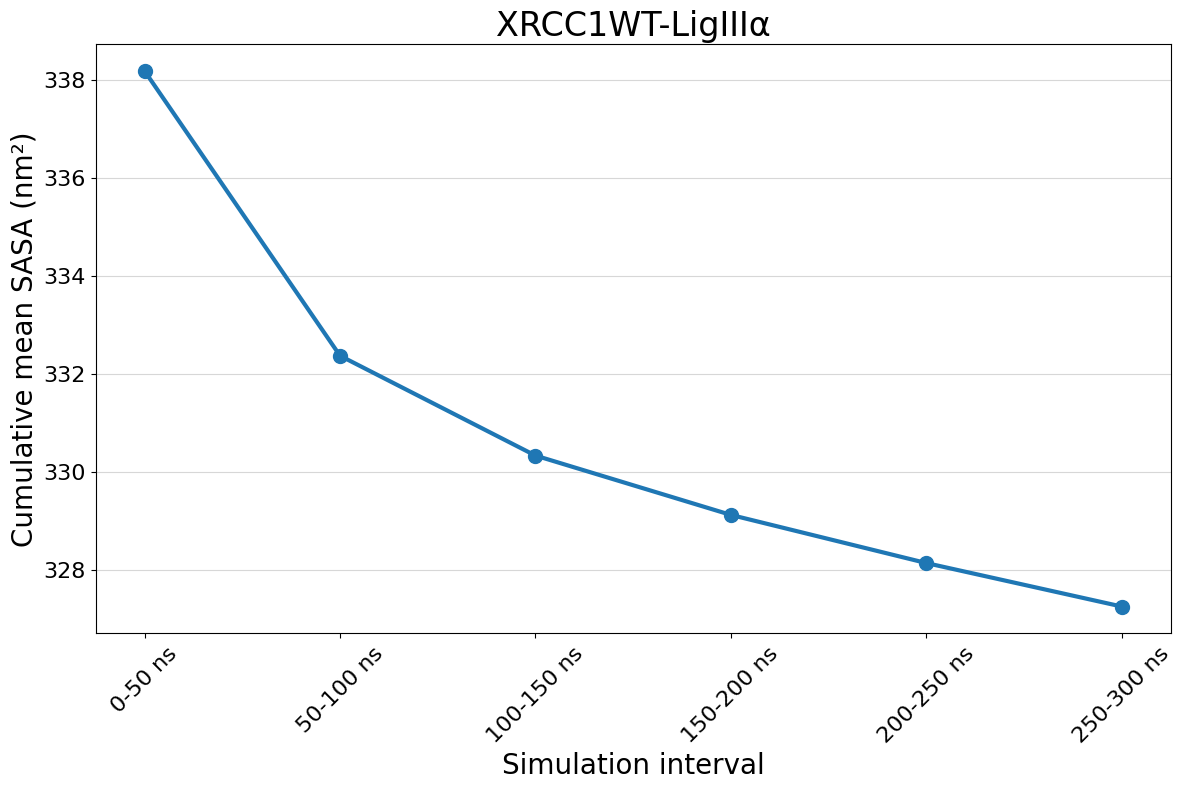

Saved: /home/naba/projects/results/SASA-WT-replicate-and-R194W_XRCC1WT-LigIIIα_cumulative_mean.png


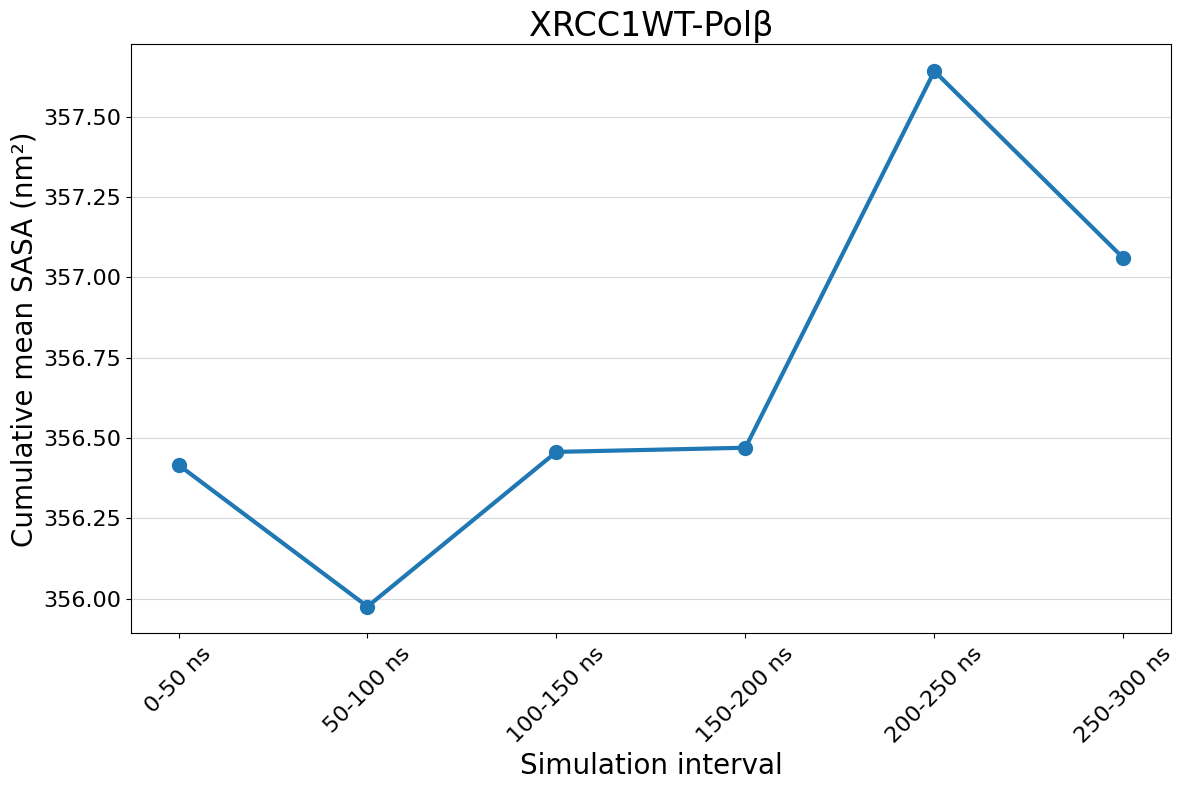

Saved: /home/naba/projects/results/SASA-WT-replicate-and-R194W_XRCC1WT-Polβ_cumulative_mean.png


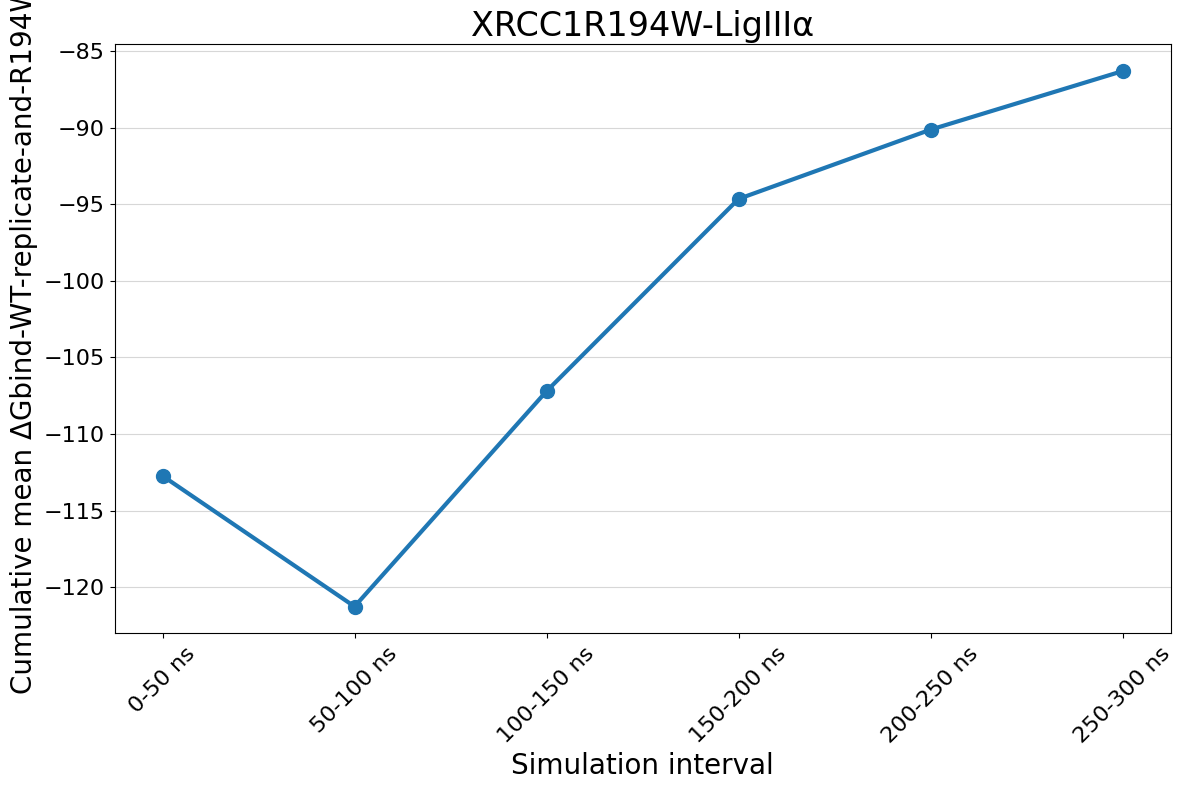

Saved: /home/naba/projects/results/ΔGbind-WT-replicate-and-R194W_XRCC1R194W-LigIIIα_cumulative_mean.png


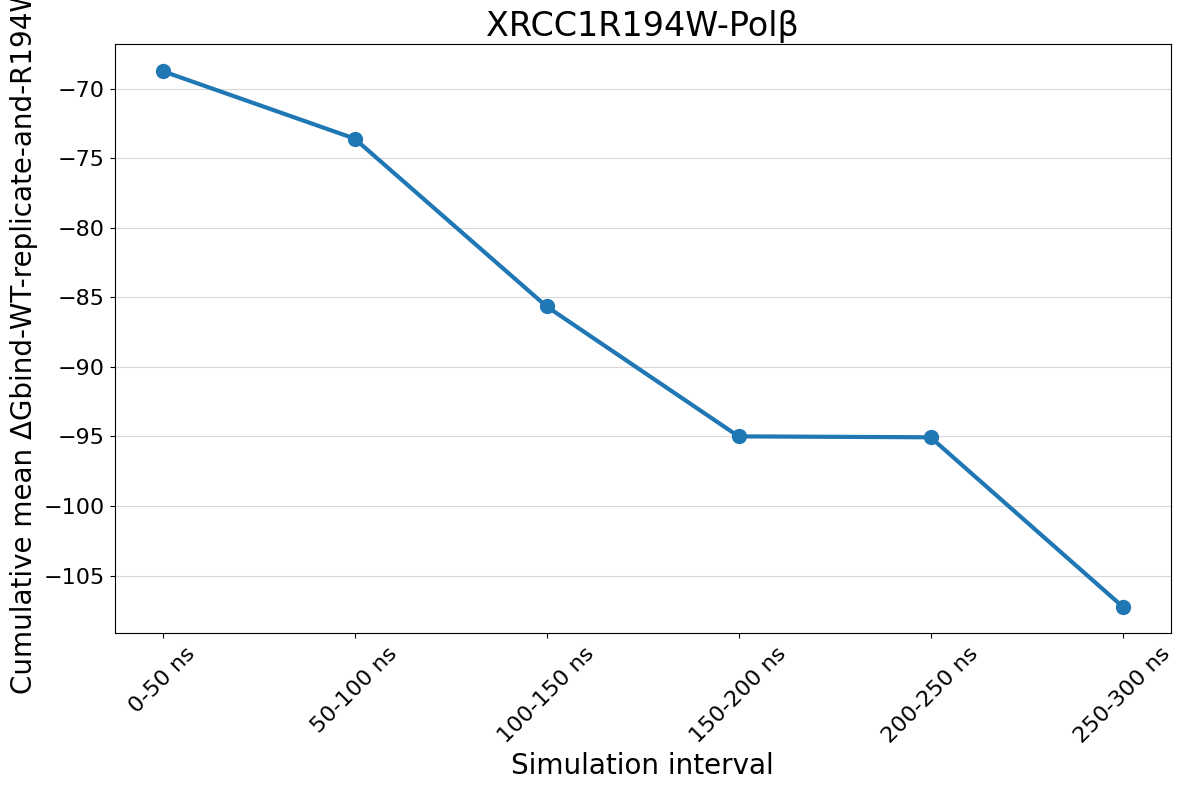

Saved: /home/naba/projects/results/ΔGbind-WT-replicate-and-R194W_XRCC1R194W-Polβ_cumulative_mean.png


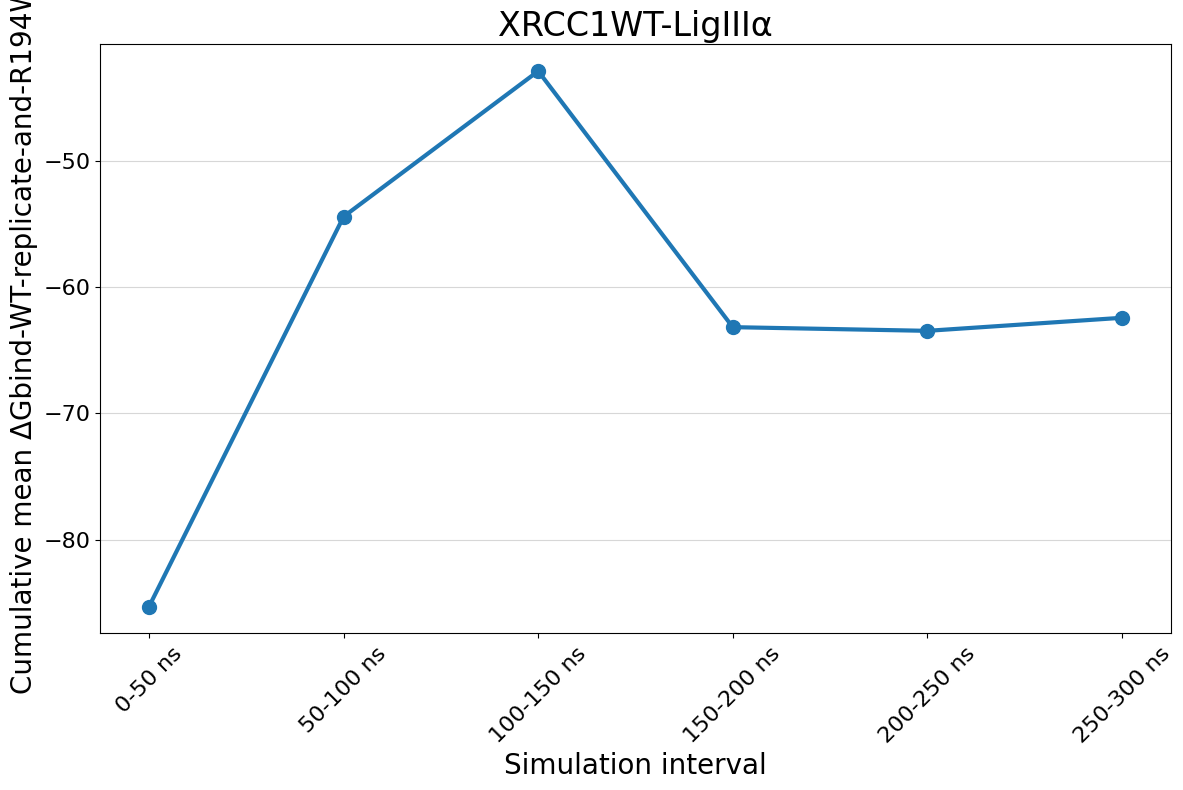

Saved: /home/naba/projects/results/ΔGbind-WT-replicate-and-R194W_XRCC1WT-LigIIIα_cumulative_mean.png


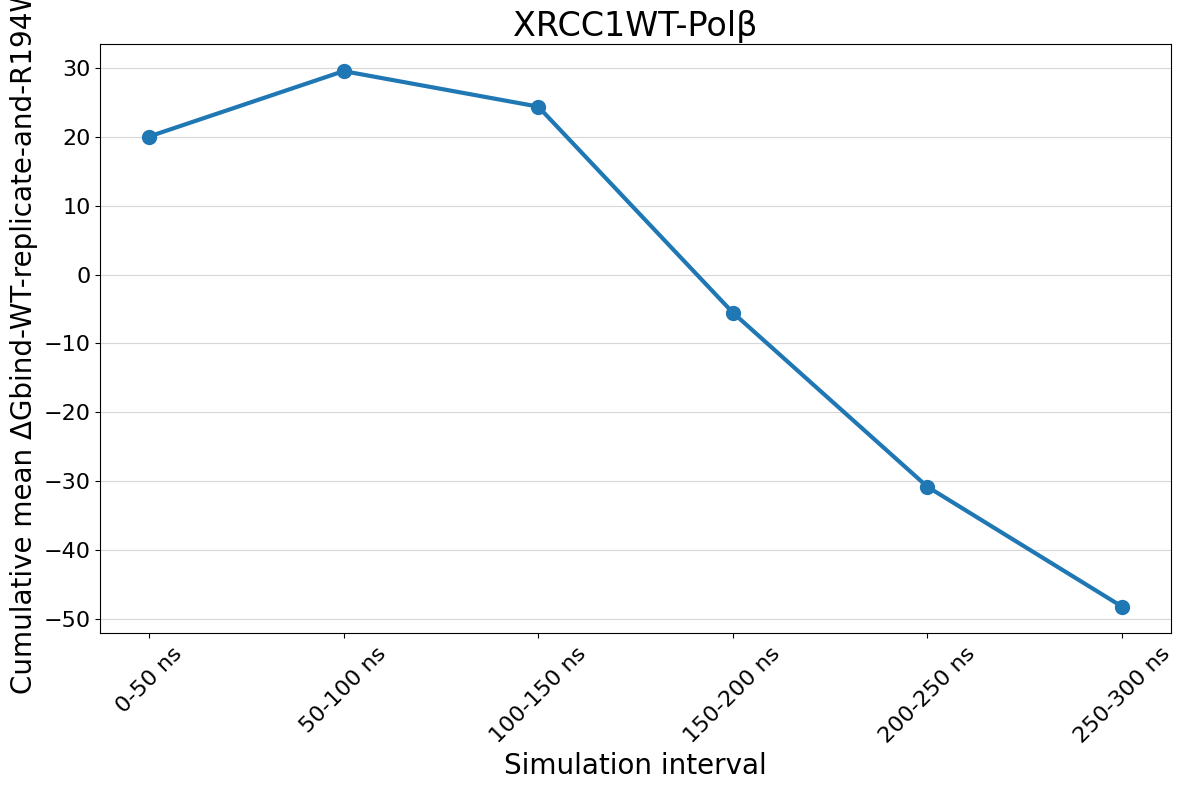

Saved: /home/naba/projects/results/ΔGbind-WT-replicate-and-R194W_XRCC1WT-Polβ_cumulative_mean.png


In [24]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_DIR = Path("/home/naba/projects")
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

result_files = sorted(PROJECT_DIR.glob("*_block_statistics.xlsx"))
if not result_files:
    raise FileNotFoundError(
        "No block-statistics Excel files found in /home/naba/projects."
    )

block_order = [
    "0-50 ns",
    "50-100 ns",
    "100-150 ns",
    "150-200 ns",
    "200-250 ns",
    "250-300 ns",
]
block_positions = range(len(block_order))

for result_file in result_files:
    block_results = pd.read_excel(result_file)
    required_columns = {"System", "Block", "Mean"}
    missing_columns = required_columns - set(block_results.columns)
    if missing_columns:
        raise ValueError(
            f"{result_file.name} is missing required columns: {sorted(missing_columns)}"
        )

    block_results["Block"] = pd.Categorical(
        block_results["Block"],
        categories=block_order,
        ordered=True,
    )
    block_results = block_results.sort_values(["System", "Block"])
    mean_values = block_results.pivot(
        index="Block",
        columns="System",
        values="Mean",
    ).reindex(block_order)

    metric_name = result_file.stem.replace("_block_statistics", "")
    metric_lower = metric_name.lower()
    if "rmsd" in metric_lower:
        metric_label = "RMSD"
        unit_label = "nm"
    elif "rg" in metric_lower:
        metric_label = "Rg"
        unit_label = "nm"
    elif "sasa" in metric_lower:
        metric_label = "SASA"
        unit_label = "nm²"
    elif "dgbind" in metric_lower or "Δgbind" in metric_lower:
        metric_label = r"$\Delta G_{\mathrm{Bind}}$"
        unit_label = "kJ/mol"
    elif "mm" in metric_lower:
        metric_label = "MM"
        unit_label = "kJ/mol"
    elif "pb" in metric_lower:
        metric_label = "PB"
        unit_label = "kJ/mol"
    elif "sa" in metric_lower:
        metric_label = "SA"
        unit_label = "kJ/mol"
    else:
        metric_label = metric_name
        unit_label = ""

    for system in mean_values.columns:
        cumulative_mean = mean_values[system].expanding().mean()

        plt.figure(figsize=(12, 8))
        plt.plot(
            block_positions,
            cumulative_mean,
            marker="o",
            linewidth=3,
            markersize=10,
        )
        plt.xlabel("Simulation interval", fontsize=20)
        ylabel = f"Cumulative mean {metric_label}"
        if unit_label:
            ylabel += f" ({unit_label})"
        plt.ylabel(ylabel, fontsize=20)
        plt.title(str(system), fontsize=24)
        plt.xticks(list(block_positions), block_order, rotation=45, fontsize=16)
        plt.yticks(fontsize=16)
        plt.grid(axis="y", alpha=0.5)
        plt.tight_layout()

        system_name = str(system).replace("/", "_").replace(" ", "_")
        file_name = result_file.stem.replace("_block_statistics", "")
        output_path = RESULTS_DIR / f"{file_name}_{system_name}_cumulative_mean.png"
        plt.savefig(output_path, dpi=1200, bbox_inches="tight")
        plt.show()
        plt.close()

        print(f"Saved: {output_path}")

All 4 RMSD Cumulative Mean

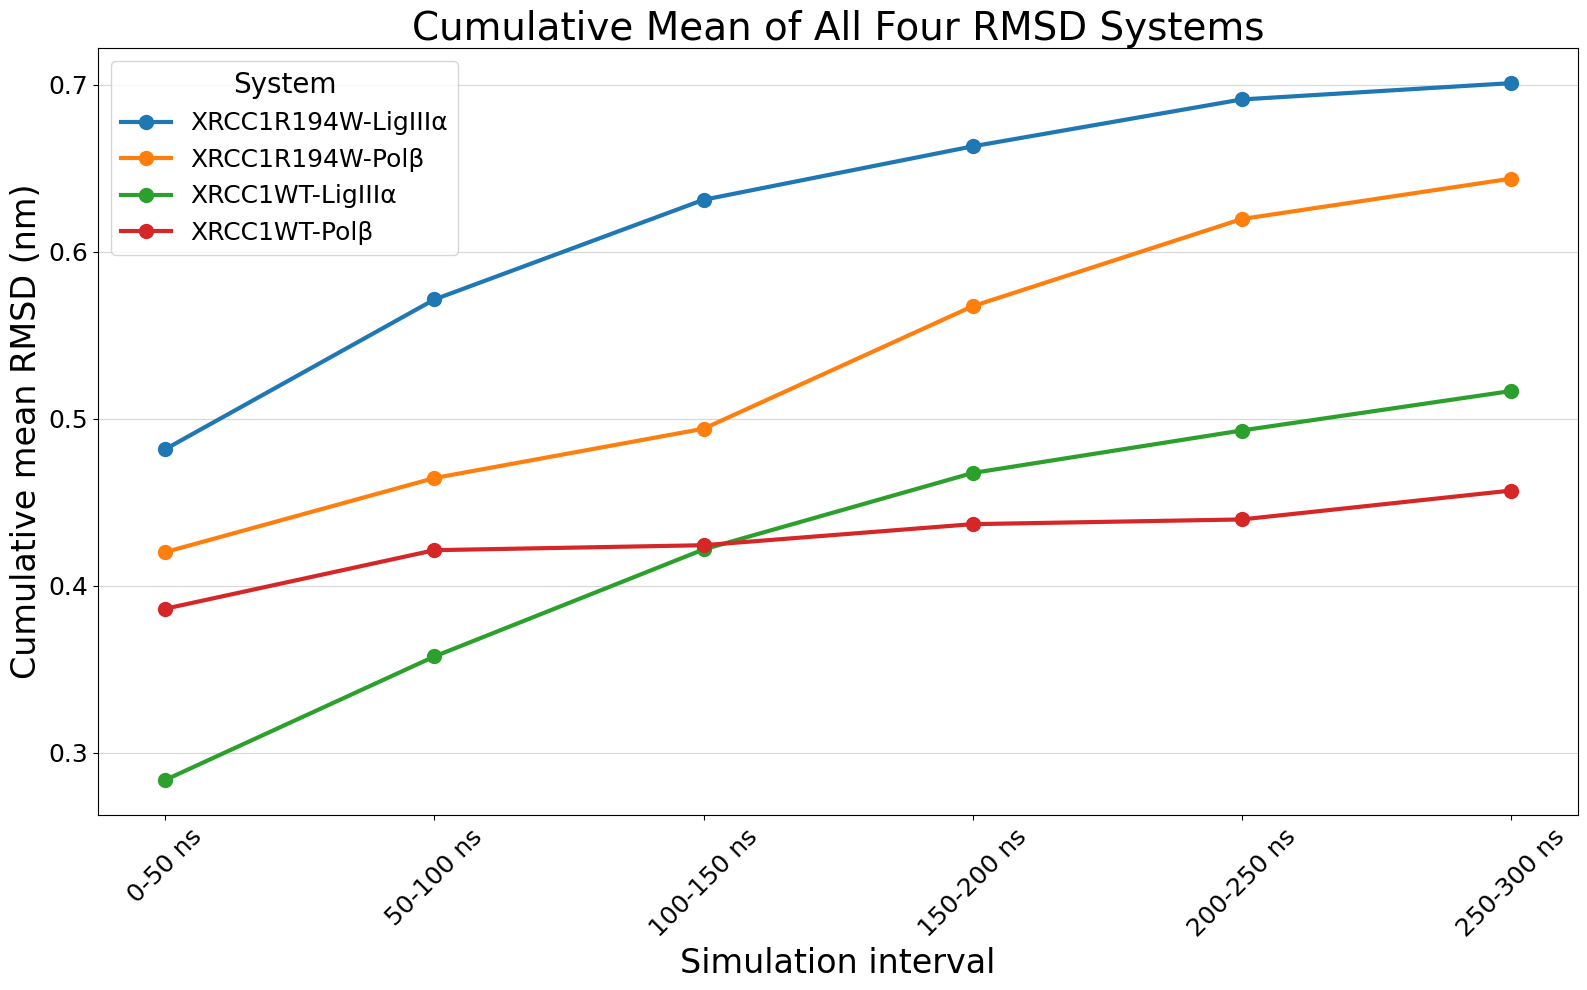

Saved: /home/naba/projects/results/all_systems_RMSD_cumulative_mean.png


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_DIR = Path("/home/naba/projects")
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

input_path = PROJECT_DIR / "RMSD-WT-replicate-and-R194W_block_statistics.xlsx"
if not input_path.exists():
    raise FileNotFoundError(f"Input file not found: {input_path}")

block_order = [
    "0-50 ns",
    "50-100 ns",
    "100-150 ns",
    "150-200 ns",
    "200-250 ns",
    "250-300 ns",
]

block_results = pd.read_excel(input_path)
required_columns = {"System", "Block", "Mean"}
missing_columns = required_columns - set(block_results.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

block_results["Block"] = pd.Categorical(
    block_results["Block"],
    categories=block_order,
    ordered=True,
)
block_results = block_results.sort_values(["System", "Block"])
mean_values = block_results.pivot(
    index="Block",
    columns="System",
    values="Mean",
).reindex(block_order)

block_positions = range(len(block_order))
plt.figure(figsize=(16, 10))

for system in mean_values.columns:
    cumulative_mean = mean_values[system].expanding().mean()
    plt.plot(
        block_positions,
        cumulative_mean,
        marker="o",
        markersize=10,
        linewidth=3,
        label=str(system),
    )

plt.xlabel("Simulation interval", fontsize=24)
plt.ylabel("Cumulative mean RMSD (nm)", fontsize=24)
plt.title("Cumulative Mean of All Four RMSD Systems", fontsize=28)
plt.xticks(list(block_positions), block_order, rotation=45, fontsize=18)
plt.yticks(fontsize=18)
plt.legend(title="System", title_fontsize=20, fontsize=18)
plt.grid(axis="y", alpha=0.5)
plt.tight_layout()

output_path = RESULTS_DIR / "all_systems_RMSD_cumulative_mean.png"
plt.savefig(output_path, dpi=1200, bbox_inches="tight")
plt.show()
plt.close()

print(f"Saved: {output_path}")

Rg Cumulative mean

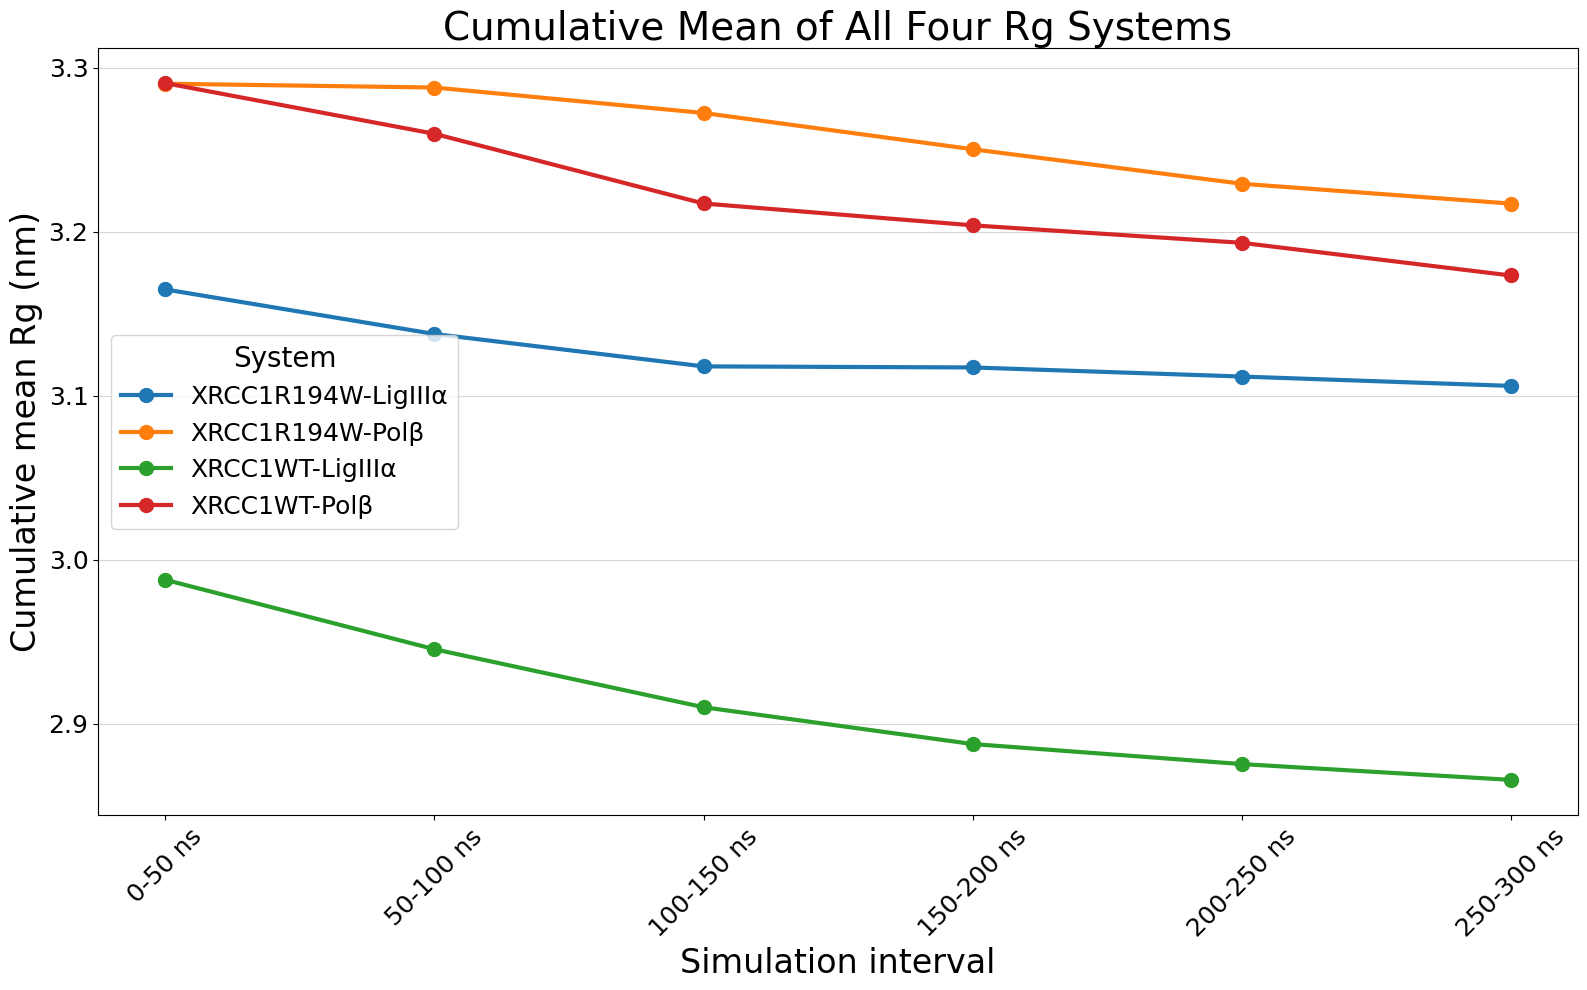

Saved: /home/naba/projects/results/all_systems_Rg_cumulative_mean.png


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_DIR = Path("/home/naba/projects")
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

input_path = PROJECT_DIR / "Rg-WT-replicate-and-R194W_block_statistics.xlsx"
if not input_path.exists():
    raise FileNotFoundError(f"Input file not found: {input_path}")

block_order = [
    "0-50 ns",
    "50-100 ns",
    "100-150 ns",
    "150-200 ns",
    "200-250 ns",
    "250-300 ns",
]

block_results = pd.read_excel(input_path)
required_columns = {"System", "Block", "Mean"}
missing_columns = required_columns - set(block_results.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

block_results["Block"] = pd.Categorical(
    block_results["Block"],
    categories=block_order,
    ordered=True,
)
block_results = block_results.sort_values(["System", "Block"])
mean_values = block_results.pivot(
    index="Block",
    columns="System",
    values="Mean",
).reindex(block_order)

block_positions = range(len(block_order))
plt.figure(figsize=(16, 10))

for system in mean_values.columns:
    cumulative_mean = mean_values[system].expanding().mean()
    plt.plot(
        block_positions,
        cumulative_mean,
        marker="o",
        markersize=10,
        linewidth=3,
        label=str(system),
    )

plt.xlabel("Simulation interval", fontsize=24)
plt.ylabel("Cumulative mean Rg (nm)", fontsize=24)
plt.title("Cumulative Mean of All Four Rg Systems", fontsize=28)
plt.xticks(list(block_positions), block_order, rotation=45, fontsize=18)
plt.yticks(fontsize=18)
plt.legend(title="System", title_fontsize=20, fontsize=18)
plt.grid(axis="y", alpha=0.5)
plt.tight_layout()

output_path = RESULTS_DIR / "all_systems_Rg_cumulative_mean.png"
plt.savefig(output_path, dpi=1200, bbox_inches="tight")
plt.show()
plt.close()

print(f"Saved: {output_path}")

SASA Cumulative mean

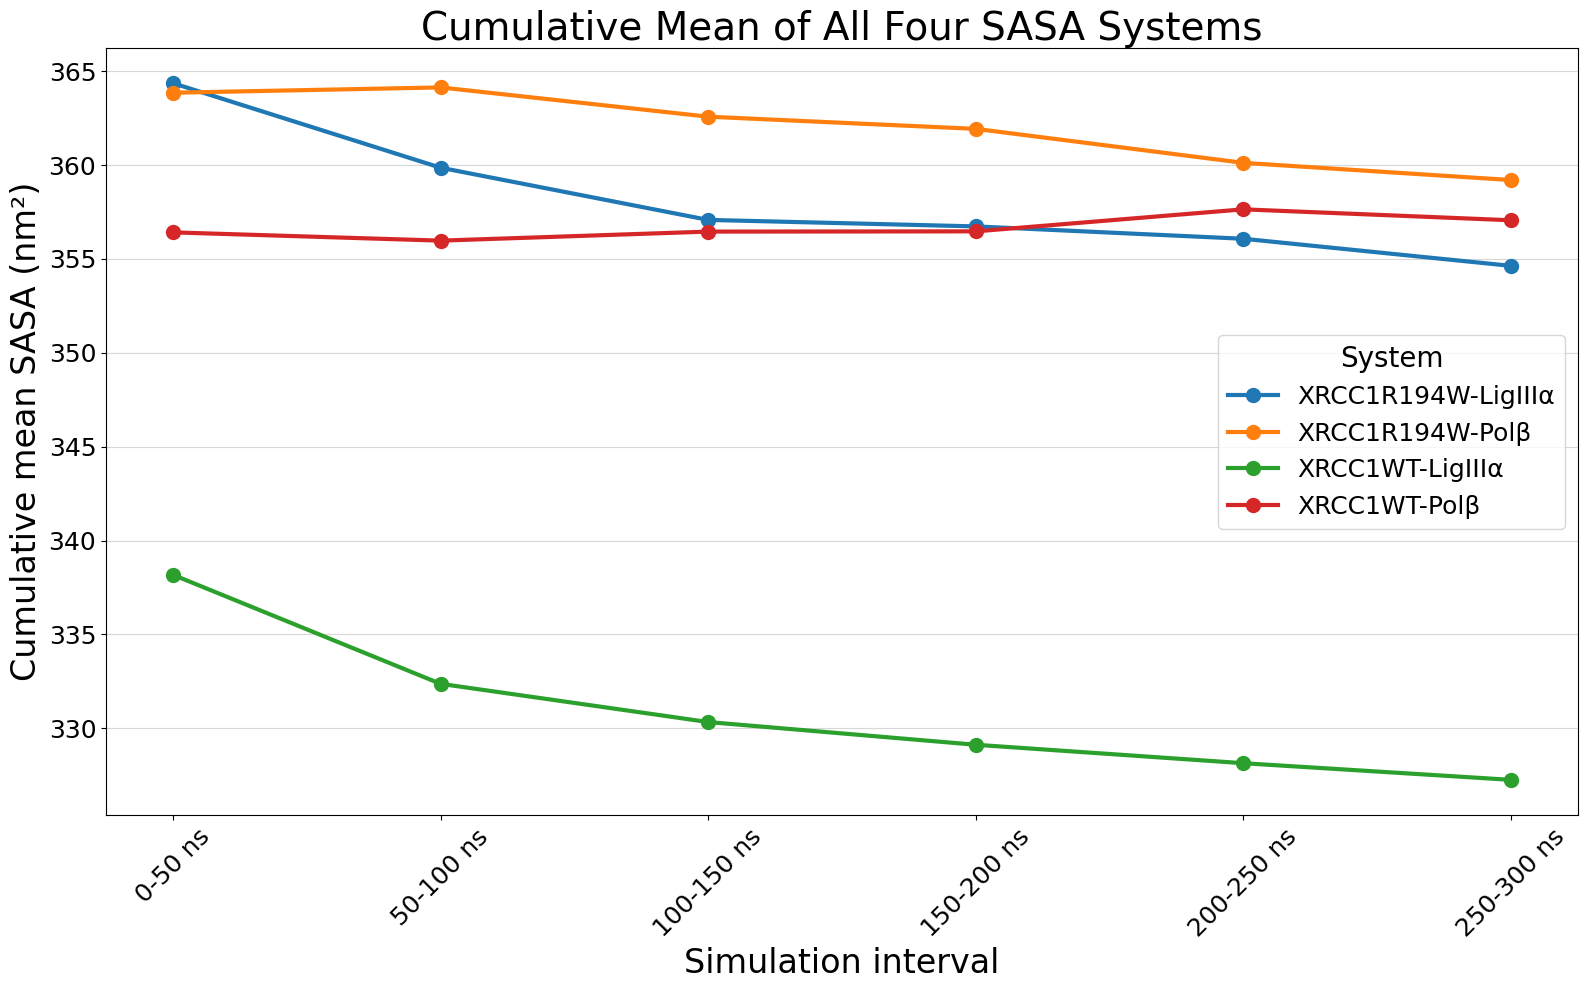

Saved: /home/naba/projects/results/all_systems_SASA_cumulative_mean.png


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_DIR = Path("/home/naba/projects")
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

input_path = PROJECT_DIR / "SASA-WT-replicate-and-R194W_block_statistics.xlsx"
if not input_path.exists():
    raise FileNotFoundError(f"Input file not found: {input_path}")

block_order = [
    "0-50 ns",
    "50-100 ns",
    "100-150 ns",
    "150-200 ns",
    "200-250 ns",
    "250-300 ns",
]

block_results = pd.read_excel(input_path)
required_columns = {"System", "Block", "Mean"}
missing_columns = required_columns - set(block_results.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

block_results["Block"] = pd.Categorical(
    block_results["Block"],
    categories=block_order,
    ordered=True,
)
block_results = block_results.sort_values(["System", "Block"])
mean_values = block_results.pivot(
    index="Block",
    columns="System",
    values="Mean",
).reindex(block_order)

block_positions = range(len(block_order))
plt.figure(figsize=(16, 10))

for system in mean_values.columns:
    cumulative_mean = mean_values[system].expanding().mean()
    plt.plot(
        block_positions,
        cumulative_mean,
        marker="o",
        markersize=10,
        linewidth=3,
        label=str(system),
    )

plt.xlabel("Simulation interval", fontsize=24)
plt.ylabel("Cumulative mean SASA (nm²)", fontsize=24)
plt.title("Cumulative Mean of All Four SASA Systems", fontsize=28)
plt.xticks(list(block_positions), block_order, rotation=45, fontsize=18)
plt.yticks(fontsize=18)
plt.legend(title="System", title_fontsize=20, fontsize=18)
plt.grid(axis="y", alpha=0.5)
plt.tight_layout()

output_path = RESULTS_DIR / "all_systems_SASA_cumulative_mean.png"
plt.savefig(output_path, dpi=1200, bbox_inches="tight")
plt.show()
plt.close()

print(f"Saved: {output_path}")

MMPBSA cumulative mean

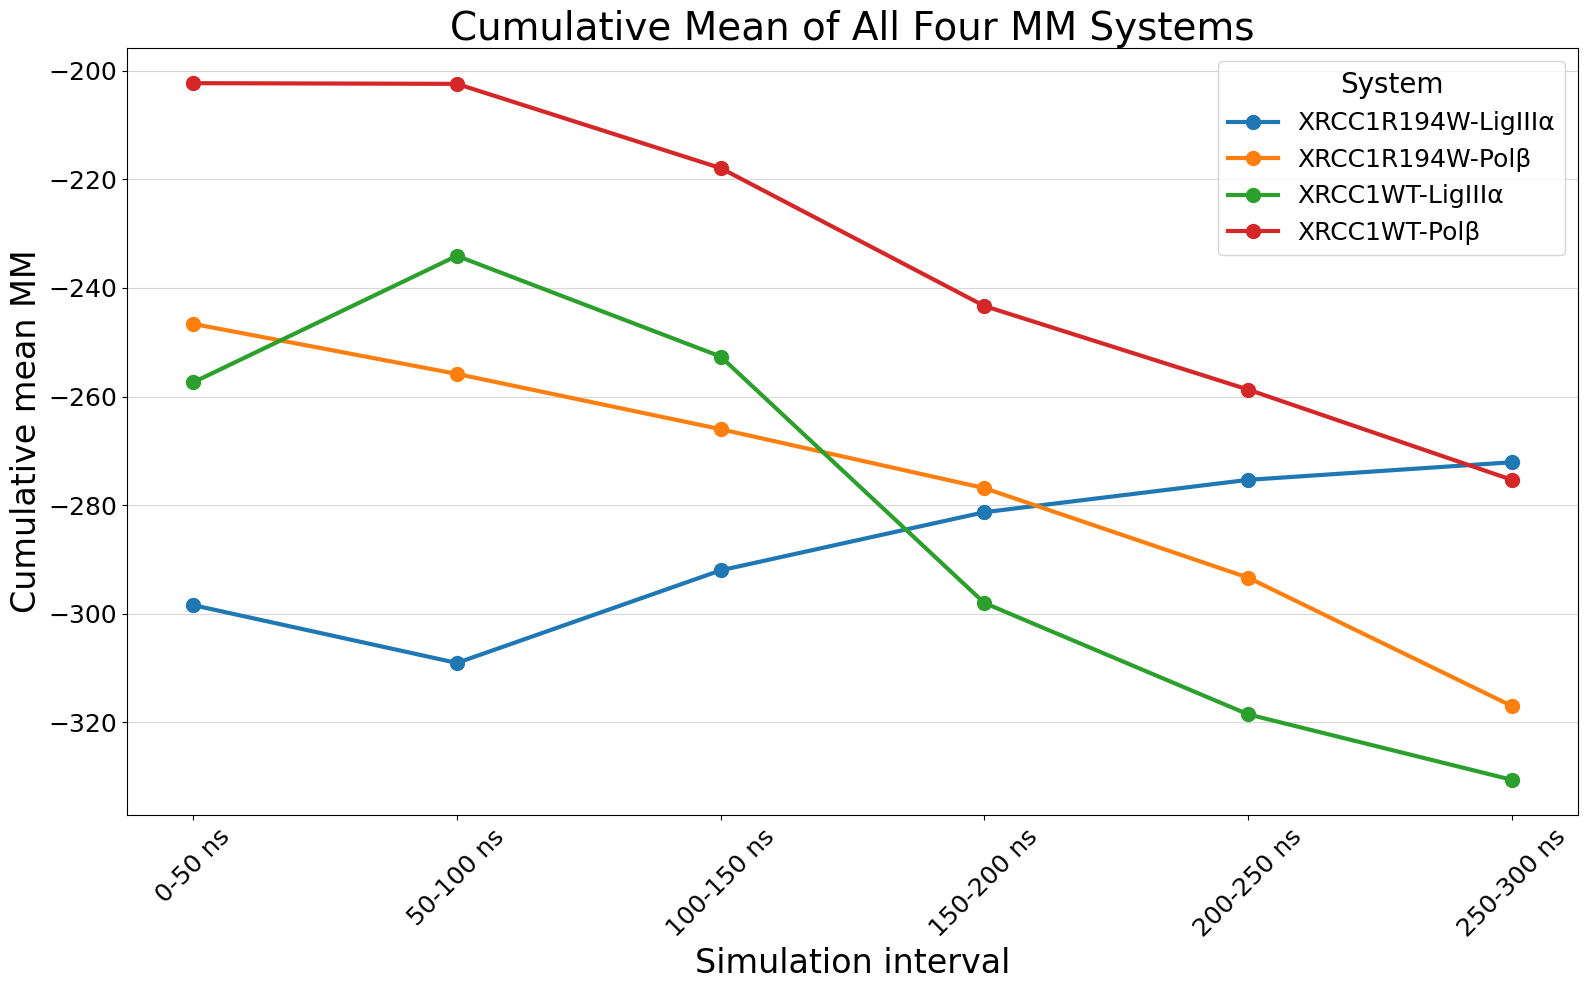

Saved: /home/naba/projects/results/all_systems_MM_cumulative_mean.png


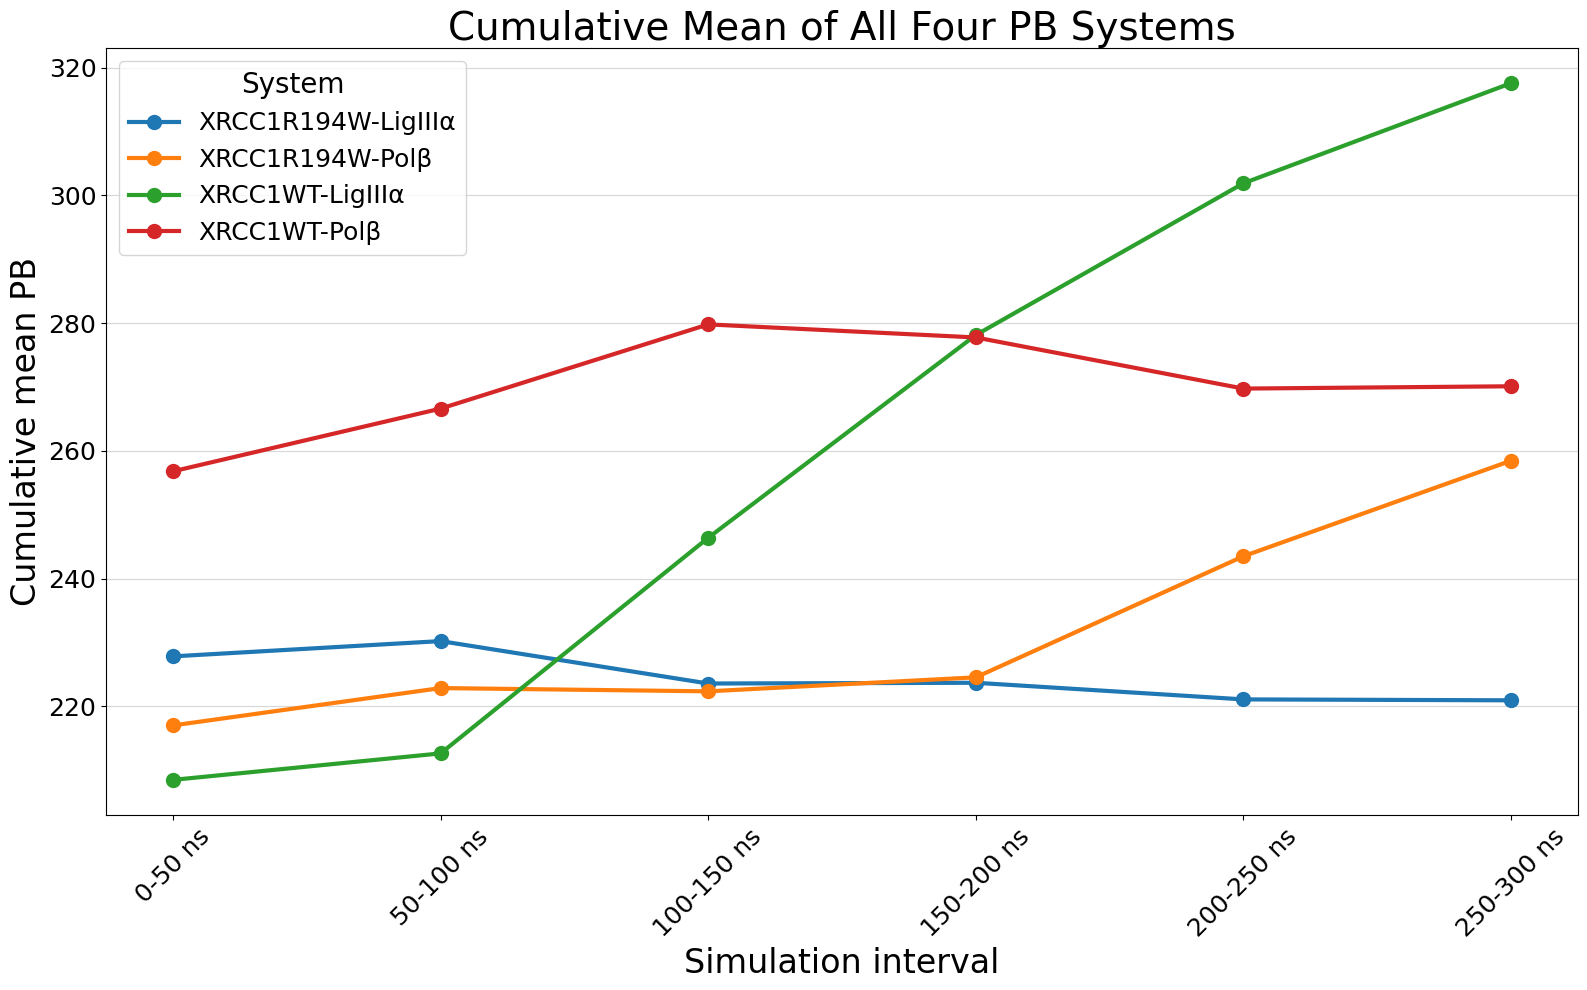

Saved: /home/naba/projects/results/all_systems_PB_cumulative_mean.png


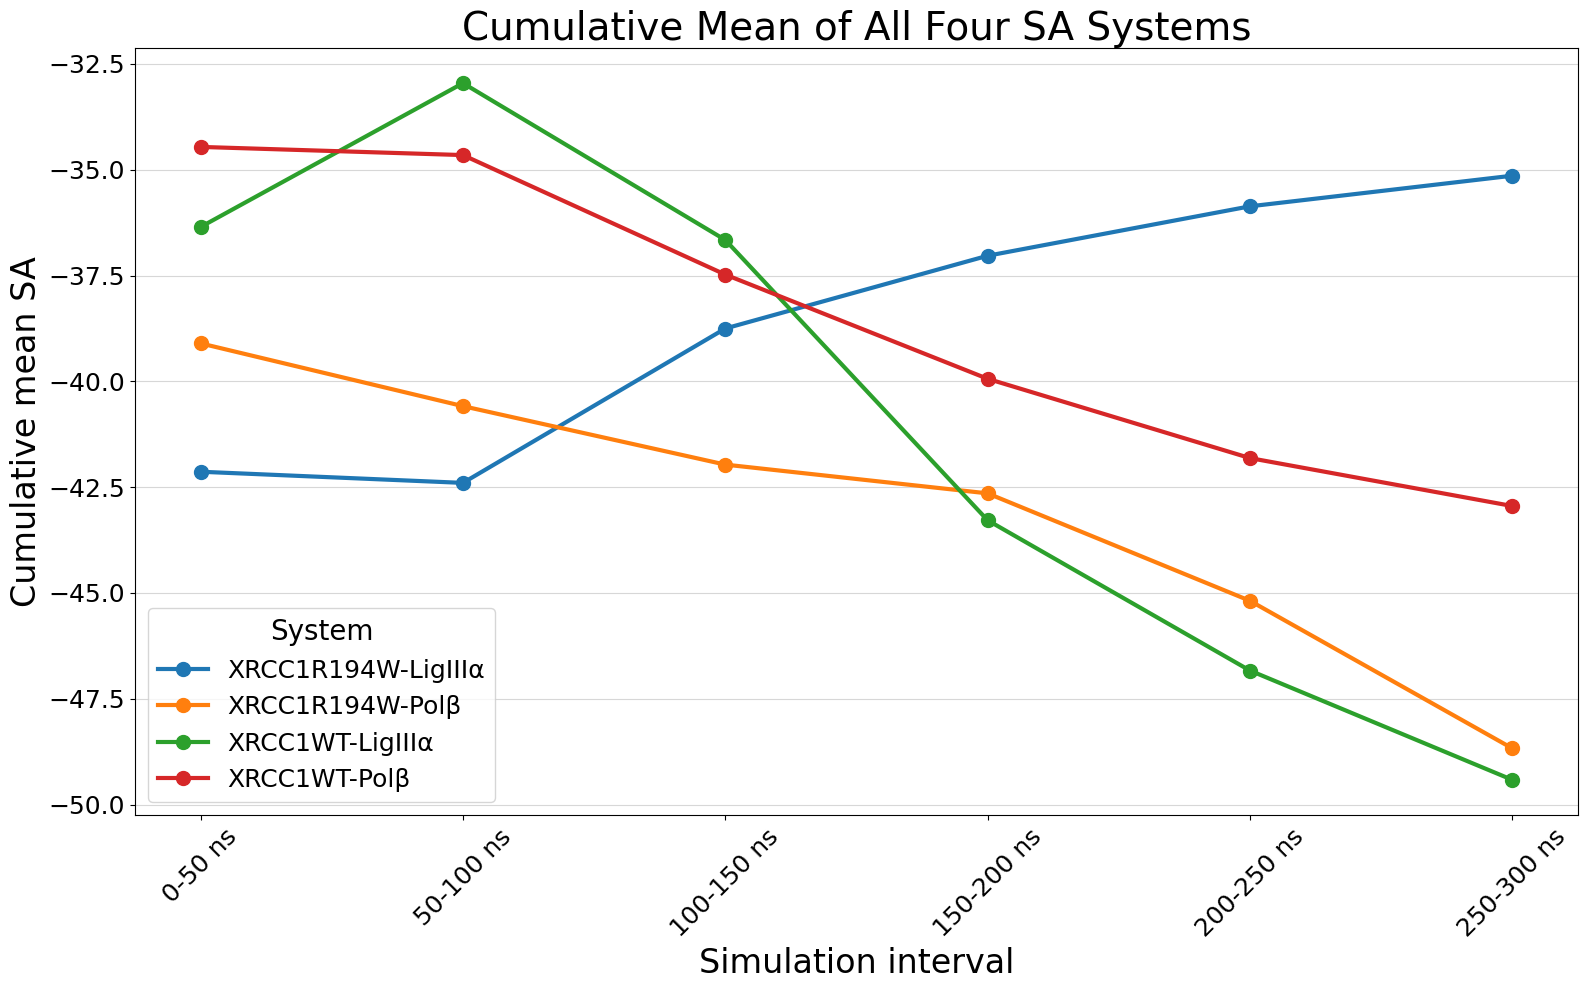

Saved: /home/naba/projects/results/all_systems_SA_cumulative_mean.png


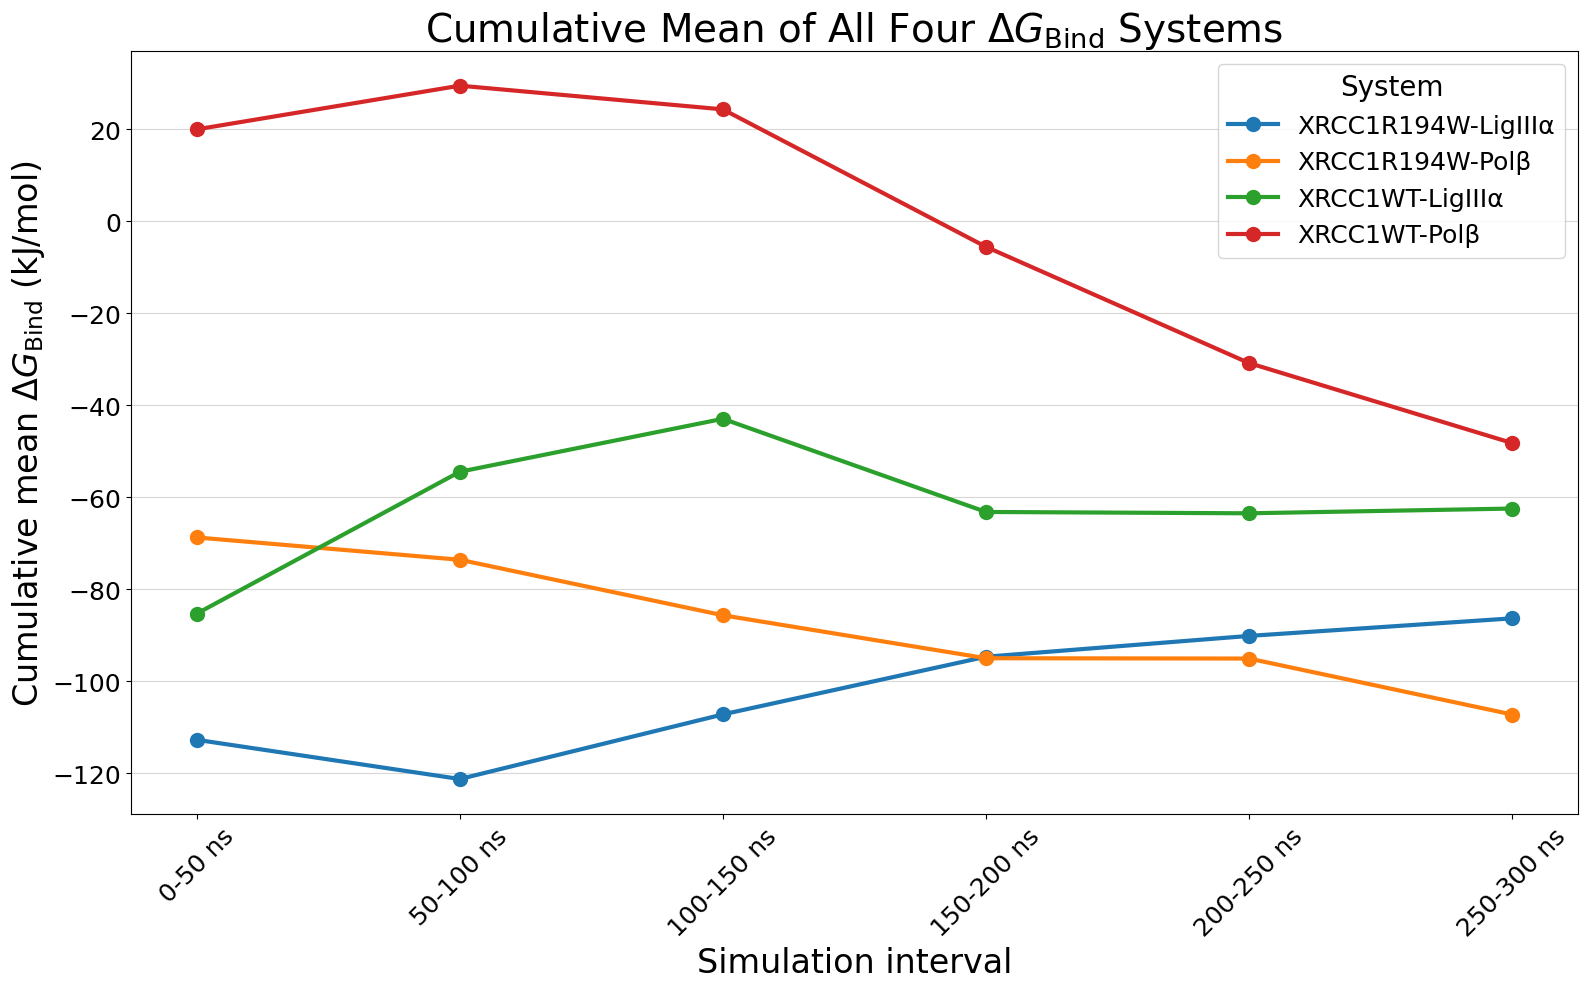

Saved: /home/naba/projects/results/all_systems_ΔGbind_cumulative_mean.png


In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_DIR = Path("/home/naba/projects")
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

block_order = [
    "0-50 ns",
    "50-100 ns",
    "100-150 ns",
    "150-200 ns",
    "200-250 ns",
    "250-300 ns",
]

parameters = {
    "MM": {
        "file": "MM-WT-replicate-and-R194W_block_statistics.xlsx",
        "ylabel": "Cumulative mean MM",
        "title": "Cumulative Mean of All Four MM Systems",
        "output": "all_systems_MM_cumulative_mean.png",
    },
    "PB": {
        "file": "PB-WT-replicate-and-R194W_block_statistics.xlsx",
        "ylabel": "Cumulative mean PB",
        "title": "Cumulative Mean of All Four PB Systems",
        "output": "all_systems_PB_cumulative_mean.png",
    },
    "SA": {
        "file": "SA-WT-replicate-and-R194W_block_statistics.xlsx",
        "ylabel": "Cumulative mean SA",
        "title": "Cumulative Mean of All Four SA Systems",
        "output": "all_systems_SA_cumulative_mean.png",
    },
    r"$\Delta G_{\mathrm{Bind}}$": {
        "file": "ΔGbind-WT-replicate-and-R194W_block_statistics.xlsx",
        "ylabel": r"Cumulative mean $\Delta G_{\mathrm{Bind}}$ (kJ/mol)",
        "title": r"Cumulative Mean of All Four $\Delta G_{\mathrm{Bind}}$ Systems",
        "output": "all_systems_ΔGbind_cumulative_mean.png",
    },
}

for parameter, settings in parameters.items():
    input_path = PROJECT_DIR / settings["file"]
    if not input_path.exists():
        raise FileNotFoundError(f"Input file not found: {input_path}")

    block_results = pd.read_excel(input_path)
    required_columns = {"System", "Block", "Mean"}
    missing_columns = required_columns - set(block_results.columns)
    if missing_columns:
        raise ValueError(
            f"{input_path.name} is missing required columns: {sorted(missing_columns)}"
        )

    block_results["Block"] = pd.Categorical(
        block_results["Block"],
        categories=block_order,
        ordered=True,
    )
    block_results = block_results.sort_values(["System", "Block"])
    mean_values = block_results.pivot(
        index="Block",
        columns="System",
        values="Mean",
    ).reindex(block_order)

    block_positions = range(len(block_order))
    plt.figure(figsize=(16, 10))

    for system in mean_values.columns:
        cumulative_mean = mean_values[system].expanding().mean()
        plt.plot(
            block_positions,
            cumulative_mean,
            marker="o",
            markersize=10,
            linewidth=3,
            label=str(system),
        )

    plt.xlabel("Simulation interval", fontsize=24)
    plt.ylabel(settings["ylabel"], fontsize=24)
    plt.title(settings["title"], fontsize=28)
    plt.xticks(list(block_positions), block_order, rotation=45, fontsize=18)
    plt.yticks(fontsize=18)
    plt.legend(title="System", title_fontsize=20, fontsize=18)
    plt.grid(axis="y", alpha=0.5)
    plt.tight_layout()

    output_path = RESULTS_DIR / settings["output"]
    plt.savefig(output_path, dpi=1200, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved: {output_path}")

In [10]:
!vmd MD-10may/1ic9.pdb

/usr/local/lib/vmd/vmd_LINUXAMD64: /lib/x86_64-linux-gnu/libGL.so.1: no version information available (required by /usr/local/lib/vmd/vmd_LINUXAMD64)
Info) VMD for LINUXAMD64, version 1.9.3 (November 30, 2016)
Info) http://www.ks.uiuc.edu/Research/vmd/                         
Info) Email questions and bug reports to vmd@ks.uiuc.edu           
Info) Please include this reference in published work using VMD:   
Info)    Humphrey, W., Dalke, A. and Schulten, K., `VMD - Visual   
Info)    Molecular Dynamics', J. Molec. Graphics 1996, 14.1, 33-38.
Info) -------------------------------------------------------------
Info) Multithreading available, 8 CPUs detected.
Info)   CPU features: SSE2 AVX AVX2 FMA KNL:AVX-512F+CD+ER+PF 
Info) Free system memory: 1818MB (23%)
Info) No CUDA accelerator devices available.
Warning) Detected X11 'Composite' extension: if incorrect display occurs
Warning) try disabling this X server option.  Most OpenGL drivers
Warning) disable stereoscopic display when 'Com